# Lisbon Airport Traffic Analysis
## Humberto Delgado Airport (LIS) — Comprehensive Study

This notebook provides an integrated analysis of air traffic at Lisbon's Humberto Delgado Airport (LIS) using Eurostat data on Portuguese airport routes (1993–2024).

The analysis is organised in three main parts:
1. **Data Loading & Cleaning:** preparing the raw Eurostat dataset for analysis
2. **Current Situation & Evolution:** understanding traffic trends, route evolution, and growth drivers
3. **Load Factor Analysis:** evaluating capacity utilisation across routes over time
4. **Seasonality Analysis:** understand seasonality in flight in/out of lisbon throught the years and how it has evolved

---
## Part 0 — Setup

Installation of required libraries and imports used throughout the notebook.

In [128]:
# Install kaleido (to save Plotly plots as a image)
!pip install plotly[kaleido]

In [129]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import plotly.graph_objects as go
from PIL import Image
import io
import seaborn as sns

# Load raw Eurostat dataset from GitHub
url = 'https://raw.githubusercontent.com/iddadobroc/PDS_Airport_Analysis/refs/heads/main/avia_par_pt_annual_linear_2_0.csv'
df = pd.read_csv(url)

# Load OurAirports reference database (used later for airport name enrichment)
df_airports = pd.read_csv("https://davidmegginson.github.io/ourairports-data/airports.csv")

print(f"Eurostat dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"OurAirports database: {df_airports.shape[0]} airports")

HTTPError: HTTP Error 404: Not Found

---
## Part 1 — Data Loading & Cleaning

The raw Eurostat dataset requires preprocessing before analysis. The steps below cover: initial inspection, column removal, airport code extraction, detection and correction of code inconsistencies, geographic enrichment via OurAirports, route label reconstruction, and aggregation of duplicate observations.

## Initial Dataset Inspection

The analysis begins with a preliminary inspection of the original Eurostat dataset.

At this stage, we evaluate:
- the overall dataset dimensions,
- column data types,
- missing values,
- and the general structure of the available variables.

This initial exploration is essential to identify potential data quality issues before starting the cleaning and transformation pipeline.

In [130]:
# Dataset dimensions, column types and missing values
print(f"Shape: {df.shape}")
df.info()

Shape: (57789, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57789 entries, 0 to 57788
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               57789 non-null  object 
 1   STRUCTURE_ID                            57789 non-null  object 
 2   STRUCTURE_NAME                          57789 non-null  object 
 3   freq                                    57789 non-null  object 
 4   Time frequency                          57789 non-null  object 
 5   unit                                    57789 non-null  object 
 6   Unit of measure                         57789 non-null  object 
 7   tra_meas                                57789 non-null  object 
 8   Traffic and transport measurement       57789 non-null  object 
 9   airp_pr                                 57789 non-null  object 
 10  Airport pairs (routes)                 

In [131]:
# Unique values per column and random sample
print(df.nunique())
df.sample(10)

STRUCTURE                                     1
STRUCTURE_ID                                  1
STRUCTURE_NAME                                1
freq                                          1
Time frequency                                1
unit                                          3
Unit of measure                               3
tra_meas                                     12
Traffic and transport measurement            12
airp_pr                                     513
Airport pairs (routes)                      505
TIME_PERIOD                                  32
Time                                          0
OBS_VALUE                                 36271
Observation value                             0
OBS_FLAG                                      1
Observation status (Flag) V2 structure        1
CONF_STATUS                                   0
Confidentiality status (flag)                 0
dtype: int64


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
54066,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPFR_UK_EGPH,FARO airport - EDINBURGH airport,1999,NaN,13862,NaN,NaN,NaN,NaN,NaN
31501,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPR_PT_LPFU,"PORTO airport - FUNCHAL, MADEIRA I. airport",1998,NaN,92753,NaN,NaN,NaN,NaN,NaN
36419,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPR_FR_LFRS,PORTO airport - NANTES ATLANTIQUE airport,2021,NaN,33800,NaN,NaN,NaN,NaN,NaN
17249,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_BRD,Passengers on board,PT_LPPR_UK_EGLL,PORTO airport - LONDON HEATHROW airport,2023,NaN,92796,NaN,NaN,NaN,NaN,NaN
38324,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPT_UK_EGKK,LISBOA airport - LONDON GATWICK airport,2008,NaN,84773,NaN,NaN,NaN,NaN,NaN
9161,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPT_SE_ESSA,LISBOA airport - STOCKHOLM/ARLANDA airport,2013,NaN,368,NaN,NaN,NaN,NaN,NaN
698,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPFR_UK_EGBB,FARO airport - BIRMINGHAM airport,1998,NaN,746,NaN,NaN,NaN,NaN,NaN
7446,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPR_FR_LFOT,PORTO airport - TOURS VAL DE LOIRE airport,2015,NaN,156,NaN,NaN,NaN,NaN,NaN
56916,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPPT_ES_LEBL,LISBOA airport - BARCELONA/EL PRAT airport,2015,NaN,359927,NaN,NaN,NaN,NaN,NaN
23678,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPFR_DE_EDDK,FARO airport - KOELN/BONN airport,1999,NaN,18334,NaN,NaN,NaN,NaN,NaN


## Removal of Empty and Non-Informative Columns

During the initial inspection of the dataset, several columns were identified as either completely empty or non-informative for the analysis.

First, columns containing only missing values (`NaN`) were removed, since they provided no usable information.

Additionally, some metadata-related columns contained only a single constant value across the entire dataset, meaning they introduced no variability and no analytical value. They include:

- `STRUCTURE`
- `STRUCTURE_ID`
- `STRUCTURE_NAME`
- `freq`
- `Time frequency`

Because these variables were constant for all observations, they were removed to simplify the dataset structure, reduce unnecessary dimensionality, and improve the readability of the analytical pipeline.

In [132]:
# Drop columns that are entirely NaN
df.dropna(axis=1, inplace=True)

# Drop constant metadata columns with no analytical value
df.drop(
    columns=["STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "freq", "Time frequency"],
    inplace=True
)

print(f"Remaining columns: {list(df.columns)}")

Remaining columns: ['unit', 'Unit of measure', 'tra_meas', 'Traffic and transport measurement', 'airp_pr', 'Airport pairs (routes)', 'TIME_PERIOD', 'OBS_VALUE']


## Extraction of Airport Codes

The original Eurostat route identifier (`airp_pr`) contains encoded airport pairs combining Portuguese and non-Portuguese airport codes.

Using regular expressions, the route identifiers were decomposed into:
- Portuguese airport codes (`airport1_code`)
- non-Portuguese airport codes (`airport2_code`)

This transformation allows route-level standardization and simplifies downstream analysis.

In [133]:
# Extract Portuguese and non-Portuguese airport codes from the route identifier
df[["airport1_code", "airport2_code"]] = (
    df["airp_pr"]
    .str.extract(r"(PT_[A-Z]{4})_([A-Z]{2}_[A-Z]{4})")
)

df[["airp_pr", "airport1_code", "airport2_code"]].sample(10)

,airp_pr,airport1_code,airport2_code
29098,PT_LPFR_UK_EGCC,PT_LPFR,UK_EGCC
24875,PT_LPLA_PT_LPGR,PT_LPLA,PT_LPGR
37326,PT_LPPT_DE_EDDB,PT_LPPT,DE_EDDB
47602,PT_LPPT_FR_LFOB,PT_LPPT,FR_LFOB
3046,PT_LPPR_PT_LPPD,PT_LPPR,PT_LPPD
21775,PT_LPPR_NL_EHAM,PT_LPPR,NL_EHAM
55591,PT_LPPR_DE_EDLV,PT_LPPR,DE_EDLV
26995,PT_LPPT_BR_SBRE,PT_LPPT,BR_SBRE
17328,PT_LPPS_PT_LPPT,PT_LPPS,PT_LPPT
4155,PT_LPPT_IT_LIRA,PT_LPPT,IT_LIRA


## Detection of Coding Inconsistencies

Before performing any aggregation, consistency checks were conducted between airport codes and airport names.

The objective of this validation step was to identify:
- multiple airport names associated with the same code,
- multiple codes associated with the same airport,
- typographical inconsistencies,
- and possible reporting anomalies in the original Eurostat data.

These checks are crucial because inconsistent airport identifiers would artificially fragment routes and bias subsequent aggregations.

In [134]:
# Check: same airport name appearing under different codes
# Each row = one airport name that has more than one code in the dataset

name_raw = df["Airport pairs (routes)"].str.split(" - ", n=1).str[1].str.upper().str.strip()

name_code_pairs = pd.DataFrame({
    "name": name_raw,
    "code": df["airport2_code"]
}).drop_duplicates()

flagged = (
    name_code_pairs
    .groupby("name")["code"]
    .nunique()
)
flagged = flagged[flagged > 1].index

(
    name_code_pairs[name_code_pairs["name"].isin(flagged)]
    .assign(code_n=lambda x: x.groupby("name").cumcount() + 1)
    .pivot(index="name", columns="code_n", values="code")
    .rename(columns={1: "code_1", 2: "code_2"})
    .reset_index()
)

code_n,name,code_1,code_2
0,BALE-MULHOUSE AIRPORT,FR_LFSB,CH_LFSB
1,EDINBURGH AIRPORT,UK_EGPH,UK_EGQT
2,HAMBURG AIRPORT,DE_EDDH,DE_EDHA
3,MEMMINGEN AIRPORT,DE_EDJA,DE_EDSM
4,PRESTWICK AIRPORT,UK_EGPK,UK_EGQG


In [135]:
# Detect airports appearing under multiple codes
# by extracting a city proxy from the Eurostat route text

city_proxy = (
    name_raw
    .str.split("/").str[0]
    .str.split(",").str[0]
    .str.split(" AIRPORT").str[0]
    .str.strip()
)

pairs = pd.DataFrame({
    "city": city_proxy,
    "code": df["airport2_code"]
})

# Count real records per city-code combination
record_counts = (
    pairs
    .groupby(["city", "code"])
    .size()
    .reset_index(name="n_records")
)

# Keep only cities with multiple codes
multi_code_cities = (
    record_counts
    .groupby("city")["code"]
    .nunique()
)
multi_code_cities = multi_code_cities[multi_code_cities > 1].index

# Pivot to wide format: one row per city
(
    record_counts[record_counts["city"].isin(multi_code_cities)]
    .sort_values(["city", "n_records"], ascending=[True, False])
    .assign(rank=lambda x: x.groupby("city").cumcount() + 1)
    .pivot(index="city", columns="rank", values=["code", "n_records"])
    .rename(columns={1: "dominant", 2: "variant", 3: "variant_2"})
    .reset_index()
)

city     code                    n_records                  
rank                 dominant  variant variant_2  dominant variant variant_2
0      BALE-MULHOUSE  FR_LFSB  CH_LFSB       NaN       324     108       NaN
1          BARCELONA  ES_LEBL  VE_SVBC       NaN       723       6       NaN
2            BELFAST  UK_EGAC  UK_EGAA       NaN       219     129       NaN
3         BIRMINGHAM  UK_EGBB  US_KBHM       NaN       632       6       NaN
4           BRASILIA  BR_SBWR  BR_SBBR       NaN       144      36       NaN
5          EDINBURGH  UK_EGPH  UK_EGQT       NaN       339      48       NaN
6          FORTALEZA  BR_SBWZ  BR_SBFZ       NaN       216      60       NaN
7          FRANKFURT  DE_EDDF  DE_EDSO   DE_EDDD       846     444       180
8            HAMBURG  DE_EDDH  DE_EDHA       NaN       576      24       NaN
9           HELSINKI  FI_EFHK  FI_EFHF       NaN       459       3       NaN
10          ISTANBUL  TR_LTBA  TR_LTFM   TR_LTBB       108      96        12
11           LEIPZIG  DE_ETLS  DE_EDDP       NaN        99      63       NaN
12         MEMMINGEN  DE_EDJA  DE_EDSM       NaN       132      24       NaN
13            MILANO  IT_LIMC  IT_LIML       NaN       642      99       NaN
14            MOSCOW  RU_UUDD  RU_UUEE       NaN        24      24       NaN
15      PORTO ALEGRE  BR_SBPA  BR_SBWP       NaN        36      36       NaN
16             PRAIA  CV_GVNP  CV_GVPR       NaN       162      87       NaN
17         PRESTWICK  UK_EGPK  UK_EGQG       NaN       120      60       NaN
18            RECIFE  BR_SBRE  BR_SBRF       NaN       192     126       NaN
19    RIO DE JANEIRO  BR_SBGL  BR_SBWJ       NaN       495      66       NaN
20              ROMA  IT_LIRF  IT_LIRA   IT_LIRU       473     144         3
21          SALVADOR  BR_SBXS  BR_SBSV       NaN       228      48       NaN
22         SAO PAULO  BR_SBGR  BR_SBXP       NaN       572      12       NaN

In [136]:
# Detect non-airport entries: FIR centres, area control centres,
# meteorological offices and other non-airport identifiers
# that Eurostat uses instead of the actual airport ICAO code

non_airport_keywords = ["FIR", "ARTCC", "TMA", "UIR", "MET INSTITUTE"]

(
    pd.DataFrame({
        "name": name_raw,
        "code": df["airport2_code"]
    })
    [lambda x: x["name"].str.contains("|".join(non_airport_keywords), na=False)]
    .groupby(["name", "code"])
    .size()
    .reset_index(name="n_records")
    .sort_values("n_records", ascending=False)
    .reset_index(drop=True)
)

,name,code,n_records
0,SAL OCEANIC FIR/UIR AIRPORT,CV_GVSC,275
1,SALVADOR/TMA AIRPORT,BR_SBXS,228
2,LUANDA FIR/UIR AIRPORT,AO_FNAN,219
3,FORTALEZA/TMA AIRPORT,BR_SBWZ,216
4,RECIFE/FIR AIRPORT,BR_SBRE,192
5,BRASILIA/TMA AIRPORT,BR_SBWR,144
6,NATAL/TMA AIRPORT,BR_SBXT,108
7,FIR PRAHA AIRPORT,CZ_LKAA,96
8,"MIAMI (ARTCC), FL. AIRPORT",US_KZMA,84
9,HELSINKI (MET INSTITUTE) AIRPORT,FI_EFKL,78


In [137]:
# Check Portuguese airports containing MADEIRA or FUNCHAL
# These may refer to the same physical airport under different names and codes

pt_name_raw = (
    df["Airport pairs (routes)"]
    .str.split(" - ", n=1).str[0]
    .str.upper().str.strip()
)

(
    pd.DataFrame({
        "name": pt_name_raw,
        "code": df["airport1_code"]
    })
    [lambda x: x["name"].str.contains("MADEIRA|FUNCHAL", na=False)]
    .groupby(["name", "code"])
    .size()
    .reset_index(name="n_records")
    .sort_values("n_records", ascending=False)
    .reset_index(drop=True)
)

,name,code,n_records
0,MADEIRA AIRPORT,PT_LPMA,6216
1,FUNCHAL/MADEIRA I. AIRPORT,PT_LPFU,1407


## Manual Correction of Airport Code Inconsistencies and Filtering

The three checks above reveal a total of 40 potentially inconsistent code assignments. After manual investigation, these were classified into four categories:

**1. Same airport, wrong or alternative code**  
Some airports appear under FIR codes, area control centre codes, TMA identifiers or meteorological office codes instead of their actual ICAO code. These are genuine errors that fragment route statistics and must be corrected: Basel-Mulhouse, Edinburgh, Hamburg, Memmingen, Prestwick, Frankfurt, Brasilia Fortaleza, Recife, Rio de Janeiro, Salvador, São Paulo, Luanda, Prague, Vienna Helsinki, Miami, Leipzig, Sal.

**2. Multiple distinct airports in the same city**  
Some cities operate more than one airport, each with its own ICAO code. These are not errors — each code refers to a different physical airport and must be preserved: Istanbul (Atatürk, Sabiha Gökçen, new airport), Milano (Linate, Malpensa), Roma (Fiumicino, Ciampino), Belfast (City Airport, Aldergrove).

**3. Homonymous airports in different countries**  
Some airport names are shared across countries. These codes are correct and refer to genuinely different airports: Barcelona (Spain vs Venezuela), Birmingham (UK vs USA).

**4. Insufficient evidence for consolidation**  
Some cases show minor code variants with very few records and no clear canonical counterpart. These were left unchanged to avoid introducing incorrect mappings: Natal, Hannover, Shannon, Firenze, Moscow, Porto Alegre, Praia.

Only category 1 requires correction. The remaining categories are retained as-is.

**Special case — Madeira Airport (Portuguese network)**  
Within the Portuguese airport network (`airport1`), Madeira airport appears under two codes: `PT_LPFU` (old Funchal code) and `PT_LPMA` (current ICAO code). Although this inconsistency is not captured by the automatic checks — since the two entries carry different names in the Eurostat text — it was identified through a targeted search and corrected to ensure consistent representation of this route.

Finally, we extract only routes where Lisbon (PT_LPPT) is `airport1`.

In [138]:
# Correct airport2 codes: FIR codes, control-area variants and historical duplicates
# identified during the inspection above
df["airport2_code"] = df["airport2_code"].replace({
    # Basel-Mulhouse: Swiss FIR → correct French ICAO
    "CH_LFSB": "FR_LFSB",
    # Edinburgh: military/ATC variant → civil ICAO
    "UK_EGQT": "UK_EGPH",
    # Hamburg: wrong code → correct ICAO
    "DE_EDHA": "DE_EDDH",
    # Memmingen: regional variant → correct ICAO
    "DE_EDSM": "DE_EDJA",
    # Prestwick: military variant → civil ICAO
    "UK_EGQG": "UK_EGPK",
})

# Consolidate airports reported under multiple equivalent codes
# (FIR centres, area-control codes, obsolete ICAO codes)
merge_mapping = {
    # Madeira (old Funchal code → current airport code)
    "PT_LPFU": "PT_LPMA",
    # Frankfurt (area codes → main airport)
    "DE_EDDD": "DE_EDDF",
    "DE_EDSO": "DE_EDDF",
    # Brasilia
    "BR_SBWR": "BR_SBBR",
    # Fortaleza
    "BR_SBWZ": "BR_SBFZ",
    # Recife
    "BR_SBRE": "BR_SBRF",
    # Rio de Janeiro
    "BR_SBWJ": "BR_SBGL",
    # Salvador
    "BR_SBXS": "BR_SBSV",
    # São Paulo
    "BR_SBXP": "BR_SBGR",
    # Luanda
    "AO_FNAN": "AO_FNLU",
    # Prague
    "CZ_LKAA": "CZ_LKPR",
    # Vienna
    "AT_LOVV": "AT_LOWW",
    # Helsinki (met office code → airport)
    "FI_EFKL": "FI_EFHK",
    # Miami (ARTCC → airport)
    "US_KZMA": "US_KMIA",
    # Leipzig
    "DE_ETLS": "DE_EDDP",
    # Sal, Cape Verde (FIR → airport)
    "CV_GVSC": "CV_GVAC",
}

df["airport2_code"] = df["airport2_code"].replace(merge_mapping)

print("Code corrections applied.")
print(f"Unique airport2 codes: {df['airport2_code'].nunique()}")

# Fix Madeira in airport1_code as well
df["airport1_code"] = df["airport1_code"].replace({"PT_LPFU": "PT_LPMA"})

Code corrections applied.
Unique airport2 codes: 207


In [139]:
# Build clean route code from corrected airport codes
df["route_codes"] = df["airport1_code"] + "_" + df["airport2_code"]

In [140]:
# Filter: keep only routes where Lisbon is airport1
df = df[df["airport1_code"] == "PT_LPPT"].copy()

print(f"Lisbon routes: {df.shape[0]} rows")
print(f"Unique destinations: {df['airport2_code'].nunique()}")

Lisbon routes: 18113 rows
Unique destinations: 131


## Lisbon Airport — Geographic Enrichment from OurAirports

Having filtered the dataset to only routes where Lisbon (PT_LPPT) is `airport1` we now enrich it with geographic metadata from OurAirports, replacing the raw Eurostat text names with standardized airport names, city names, and coordinates.

This approach:
- eliminates the need to manually clean and normalize airport names from the Eurostat text field,
- provides a single canonical name per ICAO code,
- and adds geographic metadata (`municipality`, `latitude_deg`, `longitude_deg`) for destination airports.

A small number of routes (16 codes, 630 rows) could not be matched against OurAirports. These correspond to FIR codes, area control centre codes, and other non-airport identifiers that were identified during the inconsistency checks but not corrected — either because they represent genuinely distinct airports (e.g. Istanbul, Milano) or because there was insufficient evidence for consolidation (e.g. Natal, Hannover, Shannon). Since these entries do not correspond to commercial airports, they are excluded from the Lisbon route analysis.

In [141]:
# Clean municipality name before merging
df_airports["municipality"] = df_airports["municipality"].str.split("(").str[0].str.strip()

# Strip country prefix to get bare ICAO code for OurAirports lookup
df["airport2_icao"] = df["airport2_code"].str.split("_", n=1).str[1]

# Merge with OurAirports
df = df.merge(
    df_airports[["ident", "name", "municipality", "latitude_deg", "longitude_deg"]],
    left_on="airport2_icao",
    right_on="ident",
    how="left"
).rename(columns={
    "name":          "airport2_name",
    "municipality":  "city",
    "latitude_deg":  "dest_lat",
    "longitude_deg": "dest_lon"
}).drop(columns=["ident", "airport2_icao"])

unmatched = df["airport2_name"].isna().sum()
print(f"Unmatched: {unmatched}")
df.sample(5)

Unmatched: 630


,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport1_code,airport2_code,route_codes,airport2_name,city,dest_lat,dest_lon
21,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_AO_FNAN,LISBOA airport - LUANDA FIR/UIR airport,2009,1798,PT_LPPT,AO_FNLU,PT_LPPT_AO_FNLU,Quatro de Fevereiro International Airport,Luanda,-8.858370,13.231200
1238,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_SE_ESSA,LISBOA airport - STOCKHOLM/ARLANDA airport,2023,876,PT_LPPT,SE_ESSA,PT_LPPT_SE_ESSA,Stockholm-Arlanda Airport,Stockholm,59.648490,17.928829
12359,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_BR_SBXT,LISBOA airport - NATAL/TMA airport,2007,55193,PT_LPPT,BR_SBXT,PT_LPPT_BR_SBXT,NaN,NaN,NaN,NaN
13045,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_IT_LIML,LISBOA airport - MILANO/LINATE airport,1996,59872,PT_LPPT,IT_LIML,PT_LPPT_IT_LIML,Milano Linate Airport,Segrate,45.445099,9.276740
15613,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPPT_DE_EDDH,LISBOA airport - HAMBURG airport,2014,101006,PT_LPPT,DE_EDDH,PT_LPPT_DE_EDDH,Hamburg Helmut Schmidt Airport,Hamburg,53.630402,9.988230


In [142]:
# Remove unmatched airports — codes not found in OurAirports
# These correspond to FIR/control-area codes that were not corrected
# and have no commercial airport equivalent
df = df[df["airport2_name"].notna()].copy()

print(f"Rows after removing unmatched: {df.shape[0]}")
print(f"Unique destinations: {df['airport2_code'].nunique()}")

Rows after removing unmatched: 17483
Unique destinations: 115


In [143]:
# Enrich df_lis with airport1 name from OurAirports
df["airport1_icao"] = df["airport1_code"].str.split("_", n=1).str[1]

df["airport1_name"] = df["airport1_icao"].map(
    df_airports.dropna(subset=["name"]).set_index("ident")["name"].to_dict()
)

df = df.drop(columns="airport1_icao")

print(f"Unmatched airport1: {df['airport1_name'].isna().sum()}")
df[["airport1_code", "airport1_name"]].drop_duplicates()

Unmatched airport1: 0


,airport1_code,airport1_name
0,PT_LPPT,Lisbon Humberto Delgado Airport


## Reconstruction of Route Labels and Classification

After standardizing airport names and codes, route labels were rebuilt using directional symbols to distinguish between:

- bidirectional traffic (`↔`)
- departures (`→`)
- arrivals (`←`)

This reconstruction improves interpretability and preserves the operational meaning of each traffic measurement.

We also classify each route as **Domestic**, **European**, or **Intercontinental** based on the destination country code — a classification used in both analyses.

In [144]:
# Build route label with directional symbols
df["route"] = df["airport1_name"] + " ↔ " + df["city"] + ": " + df["airport2_name"]

df.loc[df["tra_meas"].str.contains("_DEP", na=False), "route"] = (
    df["airport1_name"] + " → " + df["city"] + ": " + df["airport2_name"]
)
df.loc[df["tra_meas"].str.contains("_ARR", na=False), "route"] = (
    df["airport1_name"] + " ← " + df["city"] + ": " + df["airport2_name"]
)

df.sample(5)

,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport1_code,airport2_code,route_codes,airport2_name,city,dest_lat,dest_lon,airport1_name,route
6489,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPT_ES_LEMD,LISBOA airport - ADOLFO SUAREZ MADRID-BARAJAS ...,2016,656709,PT_LPPT,ES_LEMD,PT_LPPT_ES_LEMD,Adolfo Suárez Madrid–Barajas Airport,Madrid,40.493407,-3.572249,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport ← Madrid: Adol...
14364,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPPT_FI_EFHK,LISBOA airport - HELSINKI/VANTAA airport,2023,140512,PT_LPPT,FI_EFHK,PT_LPPT_FI_EFHK,Helsinki Vantaa Airport,Helsinki,60.318363,24.963341,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport ↔ Helsinki: He...
16960,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPPT_CH_LSGG,LISBOA airport - GENEVA airport,2020,191316,PT_LPPT,CH_LSGG,PT_LPPT_CH_LSGG,Geneva International Airport,Geneva,46.238098,6.108950,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport → Geneva: Gene...
2361,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPT_IT_LIPZ,LISBOA airport - VENEZIA/TESSERA airport,2010,361,PT_LPPT,IT_LIPZ,PT_LPPT_IT_LIPZ,Venice Marco Polo Airport,Venezia,45.505299,12.351900,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport ← Venezia: Ven...
9177,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPT_CH_LSZH,LISBOA airport - ZURICH airport,1997,159578,PT_LPPT,CH_LSZH,PT_LPPT_CH_LSZH,Zürich Airport,Zurich,47.458056,8.548056,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport ↔ Zurich: Züri...


In [145]:
# Classify each route as Domestic, European or Intercontinental
# based on the destination country code (first 2 characters of airport2_code)

european_countries = {
    'AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','EL','GR','HU','IS','IE','IT','LV','LI','LT','LU',
    'MT','NL','NO','PL','RO','SK','SI','ES','SE','CH',
    'GB','UK','AL','BA','ME','MK','RS','TR','UA','MD','BY'
}

def classify_route(country):
    if country == "PT":
        return "Domestic"
    elif country in european_countries:
        return "European"
    else:
        return "Intercontinental"

df["dest_country"] = df["airport2_code"].str[:2]
df["route_type"] = df["dest_country"].apply(classify_route)

print(df["route_type"].value_counts())
df.sample(5)

route_type
European            10493
Intercontinental     4981
Domestic             2009
Name: count, dtype: int64


,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport1_code,airport2_code,route_codes,airport2_name,city,dest_lat,dest_lon,airport1_name,route,dest_country,route_type
13286,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_PT_LPHR,LISBOA airport - HORTA airport,2016,37985,PT_LPPT,PT_LPHR,PT_LPPT_PT_LPHR,Horta Airport,Horta,38.519901,-28.715900,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport → Horta: Horta...,PT,Domestic
7073,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPT_PT_LPPR,LISBOA airport - PORTO airport,2014,226388,PT_LPPT,PT_LPPR,PT_LPPT_PT_LPPR,Francisco de Sá Carneiro Airport,Porto,41.248100,-8.681390,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport ← Porto: Franc...,PT,Domestic
12902,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_FR_LFPG,LISBOA airport - PARIS-CHARLES DE GAULLE airport,2005,184147,PT_LPPT,FR_LFPG,PT_LPPT_FR_LFPG,Charles de Gaulle International Airport,Paris,49.008960,2.554117,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport → Paris: Charl...,FR,European
11763,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPT_PT_LPPR,LISBOA airport - PORTO airport,2010,216373,PT_LPPT,PT_LPPR,PT_LPPT_PT_LPPR,Francisco de Sá Carneiro Airport,Porto,41.248100,-8.681390,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport ← Porto: Franc...,PT,Domestic
7404,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPT_BE_EBBR,LISBOA airport - BRUSSELS airport,2013,201520,PT_LPPT,BE_EBBR,PT_LPPT_BE_EBBR,Brussels Airport,Zaventem,50.901402,4.484440,Lisbon Humberto Delgado Airport,Lisbon Humberto Delgado Airport → Zaventem: Br...,BE,European


## Aggregation of Duplicate Observations

The original dataset contains multiple observations for the same route-year combination due to different reporting perspectives and duplicated records.

To obtain a single representative observation per route, year, and traffic measurement, the dataset was aggregated using the mean value of `obs_value`.

This step ensures:
- consistent route-level analysis,
- removal of duplicated operational records,
- and cleaner downstream calculations.

In [146]:
# Verify duplicates exist before aggregation
(
    df.groupby(["route_codes", "TIME_PERIOD", "tra_meas"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

route_codes      TIME_PERIOD  tra_meas   
PT_LPPT_BR_SBGR  2003         PAS_CRD        2
PT_LPPT_CV_GVAC  2003         CAF_PAS        2
PT_LPPT_DE_EDDF  2004         ST_PAS_ARR     2
                              ST_PAS         2
                              PAS_CRD_DEP    2
                              PAS_CRD_ARR    2
                              PAS_CRD        2
                              PAS_BRD_DEP    2
                              PAS_BRD_ARR    2
                              PAS_BRD        2
dtype: int64

In [147]:
df_agg = (
    df.groupby(
        [
            "TIME_PERIOD",
            "unit",
            "Unit of measure",
            "tra_meas",
            "Traffic and transport measurement",
            "airport1_code",
            "airport2_code",
            "route_codes",
            "airport1_name",
            "airport2_name",
            "city",
            "dest_lat",
            "dest_lon",
            "route",
            "dest_country",
            "route_type"
        ],
        as_index=False
    )["OBS_VALUE"]
    .mean()
)

# Round to integer
df_agg["OBS_VALUE"] = df_agg["OBS_VALUE"].round().astype(int)

# Verify: no more duplicates
print("Max records per route-year-measure after aggregation:")
print(
    df_agg.groupby(["route_codes", "TIME_PERIOD", "tra_meas"])
    .size().max()
)

print(f"\nFinal cleaned dataset: {df_agg.shape[0]} rows, {df_agg.shape[1]} columns")
print(f"Years covered: {df_agg['TIME_PERIOD'].min()} – {df_agg['TIME_PERIOD'].max()}")
print(f"Unique routes: {df_agg['route_codes'].nunique()}")
df_agg.sample(5)

Max records per route-year-measure after aggregation:
1

Final cleaned dataset: 17399 rows, 17 columns
Years covered: 1993 – 2024
Unique routes: 115


,TIME_PERIOD,unit,Unit of measure,tra_meas,Traffic and transport measurement,airport1_code,airport2_code,route_codes,airport1_name,airport2_name,city,dest_lat,dest_lon,route,dest_country,route_type,OBS_VALUE
1876,2001,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPPT,BR_SBSV,PT_LPPT_BR_SBSV,Lisbon Humberto Delgado Airport,Deputado Luiz Eduardo Magalhães International ...,Salvador,-12.908611,-38.322498,Lisbon Humberto Delgado Airport → Salvador: De...,BR,Intercontinental,6
10780,2018,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPT,IT_LIRF,PT_LPPT_IT_LIRF,Lisbon Humberto Delgado Airport,Rome–Fiumicino Leonardo da Vinci International...,Rome,41.804532,12.251998,Lisbon Humberto Delgado Airport ← Rome: Rome–F...,IT,European,1608
4013,2006,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPT,UK_EGKK,PT_LPPT_UK_EGKK,Lisbon Humberto Delgado Airport,London Gatwick Airport,London,51.148744,-0.185739,Lisbon Humberto Delgado Airport ← London: Lond...,UK,European,117705
2050,2001,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPT,FR_LFLL,PT_LPPT_FR_LFLL,Lisbon Humberto Delgado Airport,Lyon Saint-Exupéry Airport,"Colombier-Saugnieu, Rhône",45.725996,5.090139,Lisbon Humberto Delgado Airport ← Colombier-Sa...,FR,European,25379
2557,2002,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPPT,IT_LIMC,PT_LPPT_IT_LIMC,Lisbon Humberto Delgado Airport,Milan Malpensa International Airport,Ferno,45.630600,8.728110,Lisbon Humberto Delgado Airport ← Ferno: Milan...,IT,European,383776


## Column Renaming and Schema Simplification

The original Eurostat column names were verbose and not suitable for efficient analytical workflows.

Columns were therefore renamed using a cleaner and more standardized schema to:
- improve readability,
- simplify downstream coding,
- and facilitate reproducibility.

In [148]:
# Rename verbose Eurostat columns to clean schema
df_agg.rename(columns={
    "Unit of measure":                    "unit_measure",
    "Traffic and transport measurement":  "traffic_measurement",
    "TIME_PERIOD":                        "year",
    "OBS_VALUE":                          "obs_value",
}, inplace=True)

# Lowercase all column names
df_agg.columns = df_agg.columns.str.lower()

# Final column order
df_agg = df_agg[[
    "year", "unit", "unit_measure", "tra_meas", "traffic_measurement",
    "route_codes", "route",
    "airport1_code", "airport1_name",
    "airport2_code", "airport2_name", "city", "dest_lat", "dest_lon",
    "dest_country", "route_type",
    "obs_value"
]]

print(f"Schema: {list(df_agg.columns)}")
df_agg.sample(5)

Schema: ['year', 'unit', 'unit_measure', 'tra_meas', 'traffic_measurement', 'route_codes', 'route', 'airport1_code', 'airport1_name', 'airport2_code', 'airport2_name', 'city', 'dest_lat', 'dest_lon', 'dest_country', 'route_type', 'obs_value']


,year,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,city,dest_lat,dest_lon,dest_country,route_type,obs_value
14920,2022,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPPT_IT_LIMC,Lisbon Humberto Delgado Airport ↔ Ferno: Milan...,PT_LPPT,Lisbon Humberto Delgado Airport,IT_LIMC,Milan Malpensa International Airport,Ferno,45.630600,8.728110,IT,European,608532
8574,2015,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPT_IT_LIRF,Lisbon Humberto Delgado Airport ↔ Rome: Rome–F...,PT_LPPT,Lisbon Humberto Delgado Airport,IT_LIRF,Rome–Fiumicino Leonardo da Vinci International...,Rome,41.804532,12.251998,IT,European,362303
14829,2022,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_FR_LFSB,Lisbon Humberto Delgado Airport → Bâle / Mulho...,PT_LPPT,Lisbon Humberto Delgado Airport,FR_LFSB,EuroAirport Basel–Mulhouse–Freiburg,Bâle / Mulhouse,47.600680,7.521117,FR,European,55344
926,1998,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_BR_SBGR,Lisbon Humberto Delgado Airport ↔ São Paulo: S...,PT_LPPT,Lisbon Humberto Delgado Airport,BR_SBGR,São Paulo/Guarulhos–Governor André Franco Mont...,São Paulo,-23.431274,-46.469954,BR,Intercontinental,526
9040,2016,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPT_PT_LPHR,Lisbon Humberto Delgado Airport ← Horta: Horta...,PT_LPPT,Lisbon Humberto Delgado Airport,PT_LPHR,Horta Airport,Horta,38.519901,-28.715900,PT,Domestic,302


---
## Part 2 — Current Situation & Evolution of Air Traffic

This section examines how commercial flights, passengers, and route networks  
at Lisbon Airport evolved from 1993 to 2024, identifying key growth periods and structural shifts.

## 1. Evolution of Air Traffic at Lisbon Airport over Time

We begin by examining how **commercial flights, passengers carried, and unique destinations** at Lisbon Airport (LIS) evolved from 1996 to 2024 across three key dimensions.

### Overall trend

All three metrics show a clear **two-phase growth pattern**, with 2012 acting as an inflection point that separates a period of moderate expansion from an
accelerated growth phase:

- **Commercial Flights** grew +16.4% between 1999 and 2011, then accelerated sharply to +98.4% between 2011 and 2024 — representing a total increase of +130.9% over the full period.
- **Passengers On Board** followed an even steeper trajectory: +52.0% in the pre-inflection period, followed by +171.7% post-2011, totalling +312.9% growth from 1999 to 2024.
- **Unique Destinations** expanded modestly before 2012 (+18.2%), then more than doubled with a +138.5% increase through 2024, reaching over 90 distinct routes — reflecting Lisbon's consolidation as an international hub.

The contrast between the two phases is consistent across all metrics and suggests a structural shift in Lisbon's air traffic dynamics around 2012.

### Disruptions and data notes

The sharp drop visible in all three charts around **2020** reflects the global impact of the **COVID-19 pandemic**, which grounded most international flights between March and December of that year. The recovery by 2024 confirms that traffic has not only rebounded but surpassed pre-pandemic levels.

> **Data note:** The gaps visible in the flights chart around 1996–2001 are due to incomplete data coverage in the Eurostat dataset for those early years, and do not reflect actual traffic disruptions.

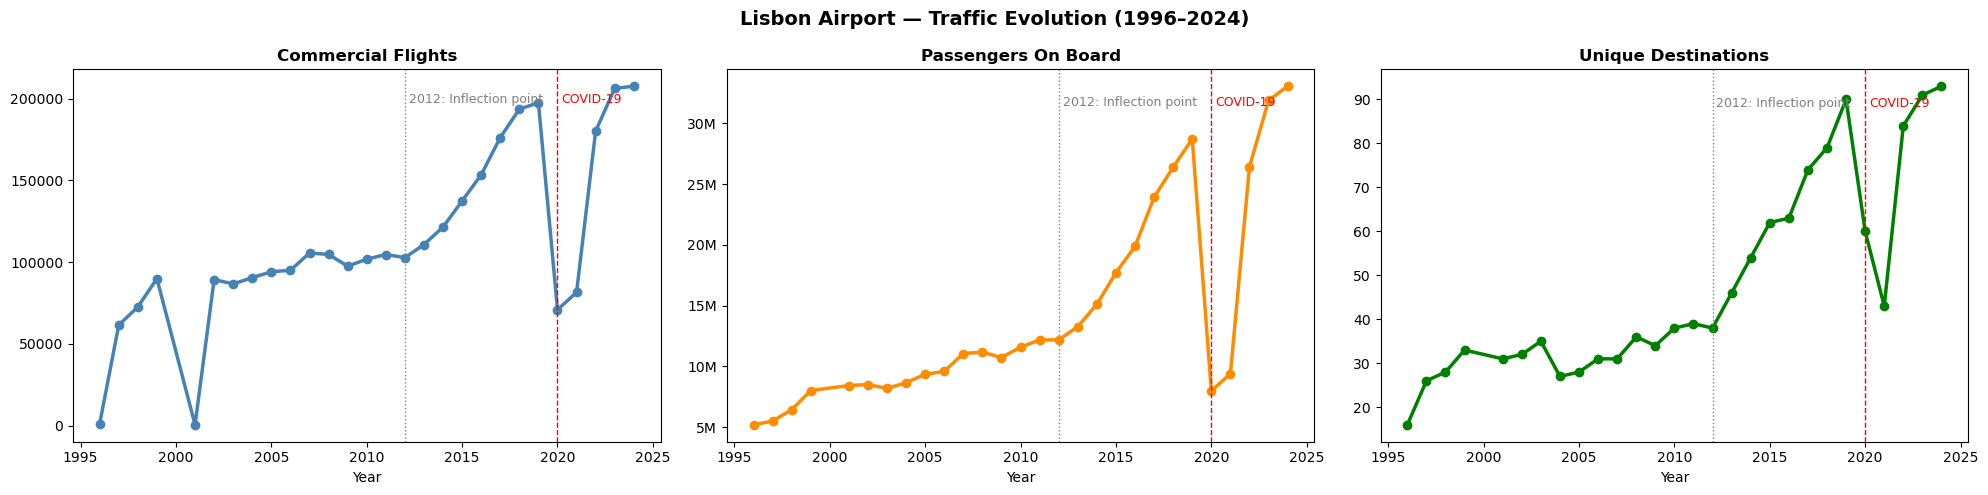

In [149]:
# --- Aggregate by year for each metric ---

# Total commercial flights
flights = (df_agg[df_agg["tra_meas"] == "CAF_PAS"]
           .groupby("year")["obs_value"].sum()
           .reset_index(name="flights"))

# Total passengers on board
passengers = (df_agg[df_agg["tra_meas"] == "PAS_BRD"]
              .groupby("year")["obs_value"].sum()
              .reset_index(name="passengers"))

# Unique routes per year (as a plottable DataFrame)
routes_per_year = (df_agg[df_agg["tra_meas"] == "CAF_PAS"]
                   .groupby("year")["city"].nunique()
                   .reset_index(name="unique_destination"))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Lisbon Airport — Traffic Evolution (1996–2024)",
             fontsize=14, fontweight="bold")

datasets = [
    (flights,         "year", "flights",       "Commercial Flights", "steelblue"),
    (passengers,      "year", "passengers",    "Passengers On Board", "darkorange"),
    (routes_per_year, "year", "unique_destination", "Unique Destinations",      "green"),
]

for ax, (data, x, y, title, color) in zip(axes, datasets):
    ax.plot(data[x], data[y], color=color, linewidth=2.5, marker="o")
    ax.axvline(x=2020, color="red", linestyle="--", linewidth=1)
    ax.text(2020.2, data[y].max() * 0.95,
            "COVID-19", color="red", fontsize=9)
    ax.axvline(x=2012, color="grey", linestyle="dotted", linewidth=1)
    ax.text(2012.2, data[y].max() * 0.95,
            "2012: Inflection point", color="grey", fontsize=9)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")

# Format y axis for passengers
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

plt.tight_layout()
plt.savefig("TrafficEvolution.png", dpi=150, bbox_inches="tight")
plt.show()

In [150]:
# --- Simple Growth Rate between key years ---
# Formula: ((Vf - Vi) / Vi) * 100

def simple_growth(df, value_col, start_year, end_year):
    """Calculate simple percentage growth rate between two years."""
    start = df.loc[df["year"] == start_year, value_col].values[0]
    end   = df.loc[df["year"] == end_year,   value_col].values[0]
    return ((end - start) / start) * 100

# Metrics to evaluate
metrics_growth = [
    (flights,         "flights",            "Commercial Flights"),
    (passengers,      "passengers",         "Passengers On Board"),
    (routes_per_year, "unique_destination", "Unique Destinations"),
]

# Key periods
periods = [
    (1999, 2011, "1999 → 2011 (pre-inflection)"),
    (2011, 2024, "2011 → 2024 (post-inflection)"),
    (1999, 2024, "1999 → 2024 (full period)   "),
]

print("=" * 55)
print("  Growth Rate Summary — Lisbon Airport Traffic")
print("=" * 55)

for df_m, col, label in metrics_growth:
    print(f"\n  {label}")
    print("-" * 45)
    for start, end, period_label in periods:
        rate = simple_growth(df_m, col, start, end)
        print(f"  {period_label}   {rate:+.1f}%")

print("\n" + "=" * 55)

  Growth Rate Summary — Lisbon Airport Traffic

  Commercial Flights
---------------------------------------------
  1999 → 2011 (pre-inflection)   +16.4%
  2011 → 2024 (post-inflection)   +98.4%
  1999 → 2024 (full period)      +130.9%

  Passengers On Board
---------------------------------------------
  1999 → 2011 (pre-inflection)   +52.0%
  2011 → 2024 (post-inflection)   +171.7%
  1999 → 2024 (full period)      +312.9%

  Unique Destinations
---------------------------------------------
  1999 → 2011 (pre-inflection)   +18.2%
  2011 → 2024 (post-inflection)   +138.5%
  1999 → 2024 (full period)      +181.8%



## 2. Lisbon Airport — Evolution of Top 10 Routes (1999, 2011, 2024)

To understand how Lisbon's route network has evolved, we compare the top 10 routes by number of commercial flights and passengers carried across three moments: 1999 (early baseline), 2011 (before inflection point), and 2024 (current situation). The bump chart below compares the ranking of the **top 10 routes** operating through Lisbon Airport.

#### Key observations

**Stability at the top:**  
The Madrid and Paris routes have consistently dominated Lisbon's connectivity over 25 years, holding the top 2 positions both by flights and passengers in 2024. This reflects the strategic importance of these corridors as European hubs.

**Domestic routes losing ground:**  
Porto ranked #1 by flights in 1999 but has dropped to #6 by 2024. This decline likely reflects the consolidation of high-speed rail as a competitive alternative for the Lisbon–Porto corridor, reducing the relative share of air travel on this route.

**Emerging international destinations:**  
Routes such as Amsterdam and Barcelona have climbed the ranking over time, consistent with Lisbon's growing role as an international gateway and the expansion of low-cost carriers serving these markets.

In [151]:
# --- Top 10 routes table per year (ordered by flights) ---

for year in [1999, 2011, 2024]:

    # Flights — ranked
    df_flights = (df_agg[
                    (df_agg["year"] == year) &
                    (df_agg["tra_meas"] == "CAF_PAS")]
                  .groupby("city")["obs_value"].sum()
                  .reset_index(name="Flights")
                  .nlargest(10, "Flights")
                  .reset_index(drop=True))
    df_flights["Rank"] = df_flights.index + 1

    # Passengers — same cities
    df_pax = (df_agg[
                (df_agg["year"] == year) &
                (df_agg["tra_meas"] == "PAS_BRD") &
                (df_agg["city"].isin(df_flights["city"]))]
              .groupby("city")["obs_value"].sum()
              .reset_index(name="Passengers"))

    # Merge and format
    df_year_table = (df_flights
                     .merge(df_pax, on="city", how="left")
                     .rename(columns={"city": "City"})
                     [["Rank", "City", "Flights", "Passengers"]]
                     .set_index("Rank"))

    print(f"\n{'='*45}")
    print(f"  Top 10 Routes — {year} (ordered by Flights)")
    print(f"{'='*45}")
    display(df_year_table)


  Top 10 Routes — 1999 (ordered by Flights)


,City,Flights,Passengers
Rank,,,
1,Porto,15580,968283
2,Madrid,10215,595406
3,Funchal,8086,754216
4,Paris,7278,834698
5,Barcelona,5680,300754
6,London,5479,726601
7,Zaventem,4298,313444
8,Faro,4129,273141
9,Frankfurt am Main,3049,353917



  Top 10 Routes — 2011 (ordered by Flights)


,City,Flights,Passengers
Rank,,,
1,Madrid,11794,1175718
2,Paris,9733,1195812
3,London,8373,932937
4,Funchal,7255,798620
5,Porto,6556,384147
6,Barcelona,6282,628070
7,Frankfurt am Main,4257,550449
8,Zaventem,3834,413445
9,Amsterdam,3729,479941



  Top 10 Routes — 2024 (ordered by Flights)


,City,Flights,Passengers
Rank,,,
1,Madrid,13674,1906810
2,Paris,13473,2190819
3,London,10731,1602124
4,Barcelona,8676,1305162
5,Funchal,8556,1397270
6,Porto,6904,758949
7,Amsterdam,6653,1044640
8,Ponta Delgada,5596,933623
9,Geneva,4874,723888


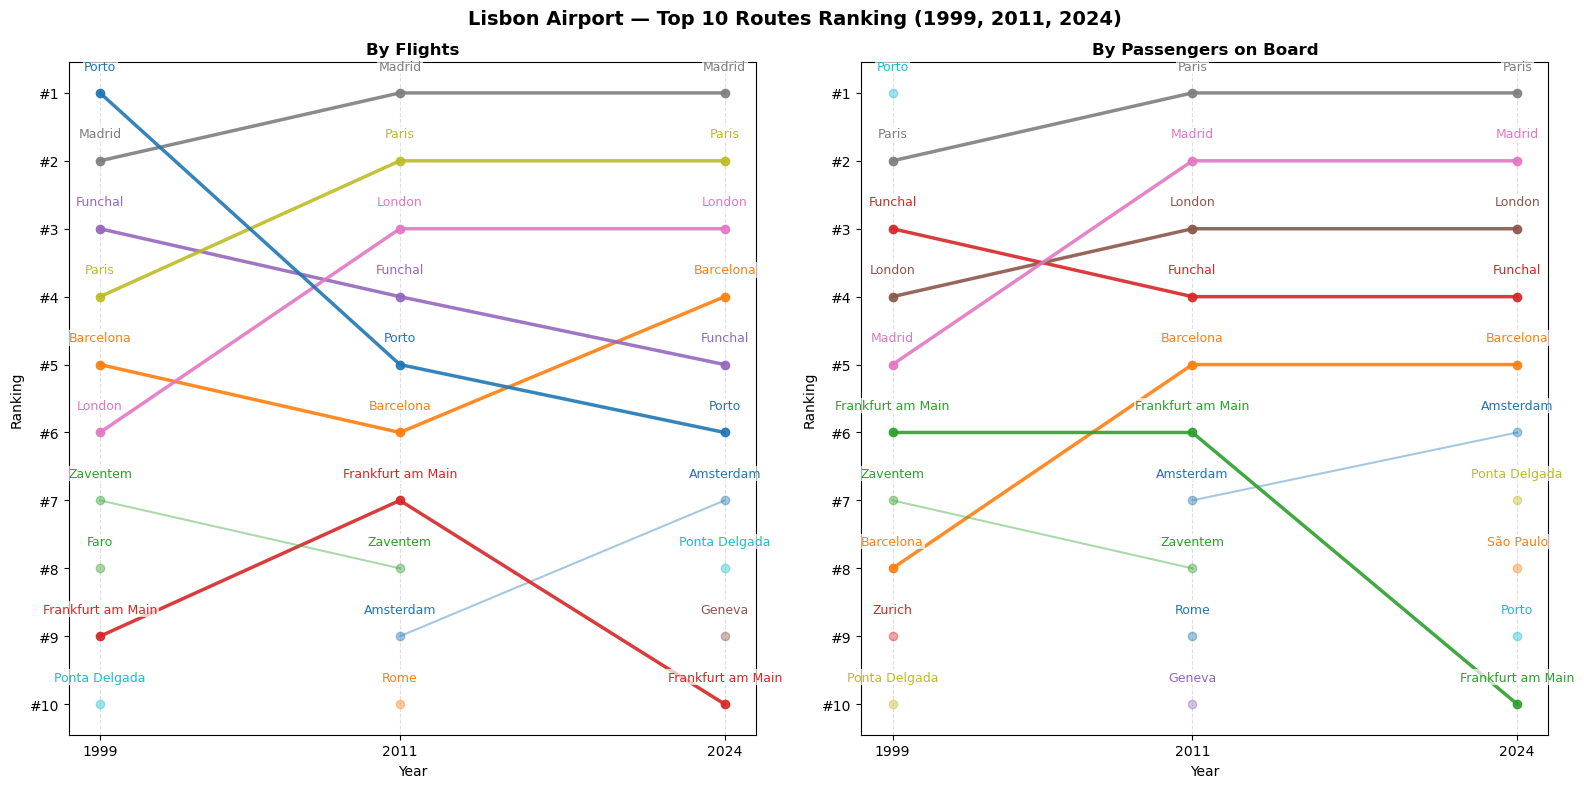

In [152]:
# --- Bump chart (rankings derived from table data) ---

years = [1999, 2011, 2024]
metrics_ranking = [
    ("CAF_PAS", "flights",    "Flights"),
    ("PAS_BRD", "passengers", "Passengers on Board"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Lisbon Airport — Top 10 Routes Ranking (1999, 2011, 2024)",
             fontsize=14, fontweight="bold")

for ax, (tra_meas, col, metric_label) in zip(axes, metrics_ranking):
    rankings = {}
    for year in years:
        df_year = (df_agg[
                    (df_agg["year"] == year) &
                    (df_agg["tra_meas"] == tra_meas)]
                   .groupby("city")["obs_value"].sum()
                   .reset_index(name=col)
                   .nlargest(10, col)
                   .reset_index(drop=True))
        df_year["rank"] = df_year.index + 1
        rankings[year] = df_year.set_index("city")["rank"]

    all_cities = set()
    for r in rankings.values():
        all_cities.update(r.index)

    for city in sorted(all_cities):
        ranks = [rankings[y].get(city, None) for y in years]
        ranks_plot = [r if r is not None else float("nan") for r in ranks]
        appeared = sum(r is not None for r in ranks)
        lw = 2.5 if appeared == 3 else 1.5
        alpha = 0.9 if appeared == 3 else 0.4

        line, = ax.plot(years, ranks_plot, marker="o", linewidth=lw,
                        alpha=alpha, markersize=6)

        # Label at middle point (2014) only if city appears that year
        for idx, year in enumerate(years):
            current_rank = ranks_plot[idx]

            if current_rank == current_rank:
                ax.text(year, current_rank - 0.3, city,
                        fontsize=9, ha="center", va="bottom", color=line.get_color(),
                        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

    ax.set_title(f"By {metric_label}", fontweight="bold")
    ax.set_xticks(years)
    ax.set_yticks(range(1, 11))
    ax.set_yticklabels([f"#{i}" for i in range(1, 11)])
    ax.invert_yaxis()
    ax.set_xlabel("Year")
    ax.set_ylabel("Ranking")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("TopRoutes.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. What drove the turning point in air traffic growth?

From the previous charts, a clear inflection point is visible around 2013–2015 where both flights and passengers started growing at a much faster pace.

**Key events annotated:**
- 2012: [EasyJet opens base at Lisbon Airport](https://sicnoticias.pt/economia/2012-03-21-easyjet-abre-base-em-lisboa-a-19-de-abril-e-emprega-cerca-de-60-portugueses)
- 2013: [Vinci Airports takes 50-year concession of ANA Aeroportos](https://vinci-airports.com/en/our-airports/portugal/lisbon-airport/)
- 2014: [Ryanair opens base at Lisbon Airport](https://www.ana.pt/en/corporate/press/2016/08/25/ryanair-opens-new-base-in-lisbon)
- 2015: [TAP partially privatized — new management, 53 new aircraft ordered](https://expresso.pt/economia/2015-11-13-TAP-compra-53-novos-avioes-1)

We identify that 26 new routes appeared during the key inflection years (2012–2015) related to european and intercontinental flights.

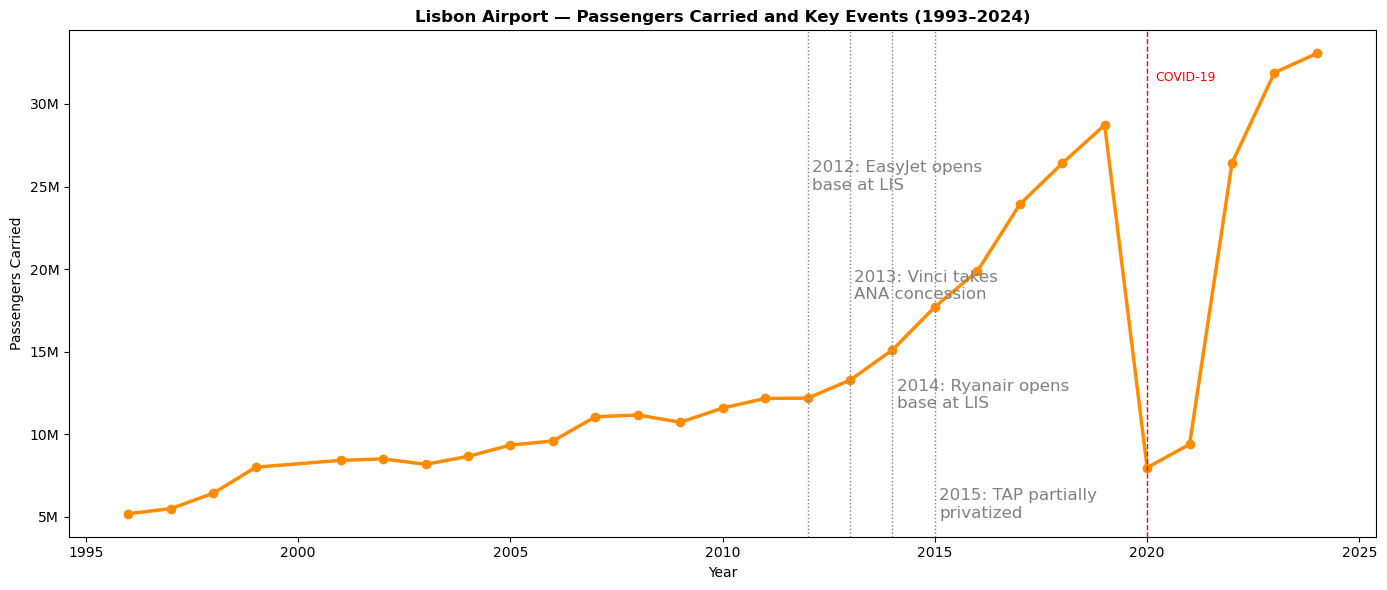

In [153]:
fig, ax = plt.subplots(figsize=(14, 6))

# --- Passengers ---
ax.plot(passengers["year"], passengers["passengers"],
        color="darkorange", linewidth=2.5, marker="o", label="Passengers")

# --- COVID line ---
ax.axvline(x=2020, color="red", linestyle="--", linewidth=1)
ax.text(2020.2, passengers["passengers"].max() * 0.95,
        "COVID-19", color="red", fontsize=9)

# --- Key events — staggered heights ---
events = {
    2012: ("2012: EasyJet opens\nbase at LIS", 0.75),
    2013: ("2013: Vinci takes\nANA concession", 0.55),
    2014: ("2014: Ryanair opens\nbase at LIS", 0.35),
    2015: ("2015: TAP partially\nprivatized",  0.15),
}

for year, (label, height) in events.items():
    ax.axvline(x=year, color="gray", linestyle=":", linewidth=1)
    ax.text(year + 0.1, passengers["passengers"].max() * height,
            label, fontsize=12, color="gray")

ax.set_xlabel("Year")
ax.set_ylabel("Passengers Carried")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_title("Lisbon Airport — Passengers Carried and Key Events (1993–2024)",
             fontweight="bold")

plt.tight_layout()
plt.savefig("KeyEvents.png", dpi=150, bbox_inches="tight")
plt.show()

In [154]:
df_lis_caf = df_agg[df_agg["tra_meas"] == "CAF_PAS"].copy()

key_years = [2012, 2013, 2014, 2015]

routes_by_year = {
    year: set(df_lis_caf[df_lis_caf["year"] == year]["city"].unique())
    for year in df_lis_caf["year"].unique()
}

# Tag each route as "new" if it didn't exist in the previous year
df_lis_caf["is_new"] = df_lis_caf.apply(
    lambda row: row["city"] not in routes_by_year.get(row["year"] - 1, set()),
    axis=1
)

# Filter key years and new routes, aggregate and display
df_new_routes = (df_lis_caf[
                    df_lis_caf["year"].isin(key_years) &
                    df_lis_caf["is_new"]]
                 .groupby(["city", "year", "route_type"])["obs_value"].sum()
                 .reset_index()
                 .rename(columns={"city": "New city", "year": "Year", "route_type": "Route type", "obs_value": "Number of flights"})
                 .sort_values(["Year", "Number of flights"], ascending=[True, False])
                 .reset_index(drop=True))

df_new_routes.style.set_caption("New Routes at Lisbon Airport — Key Event Years")

,New city,Year,Route type,Number of flights
0,Istanbul,2012,European,684
1,Casablanca,2013,Intercontinental,1803
2,Bilbao,2013,European,1538
3,Bordeaux,2013,European,1122
4,"Manchester, Greater Manchester",2013,European,823
5,Dubai,2013,Intercontinental,736
6,Stockholm,2013,European,732
7,Vienna,2013,European,686
8,Maputo,2013,Intercontinental,393
9,Miami,2013,Intercontinental,364


## 4. Domestic vs. European vs. Intercontinental Traffic Evolution

To understand how the composition of Lisbon's air traffic has changed over time, we classify each route by type and track passenger volumes from 1993 to 2024:
- **Domestic**: routes within Portugal
- **European**: routes to other European countries
- **Intercontinental**: routes outside Europe

European routes have consistently dominated passenger traffic at Lisbon Airport. Intercontinental traffic grew steadily as well, reaching around 7.5 million by 2019, reflecting Lisbon's growing role as a hub connecting Europe with Portuguese-speaking markets in Brazil and Africa. Domestic routes remained flat throughout the entire period, consistent with the earlier observation about Porto losing ground to rail competition.

To close this analysis, we visualize the full route network operated from Lisbon Airport in 1999 and 2024. Line thickness reflects the number of commercial flights on each route type.

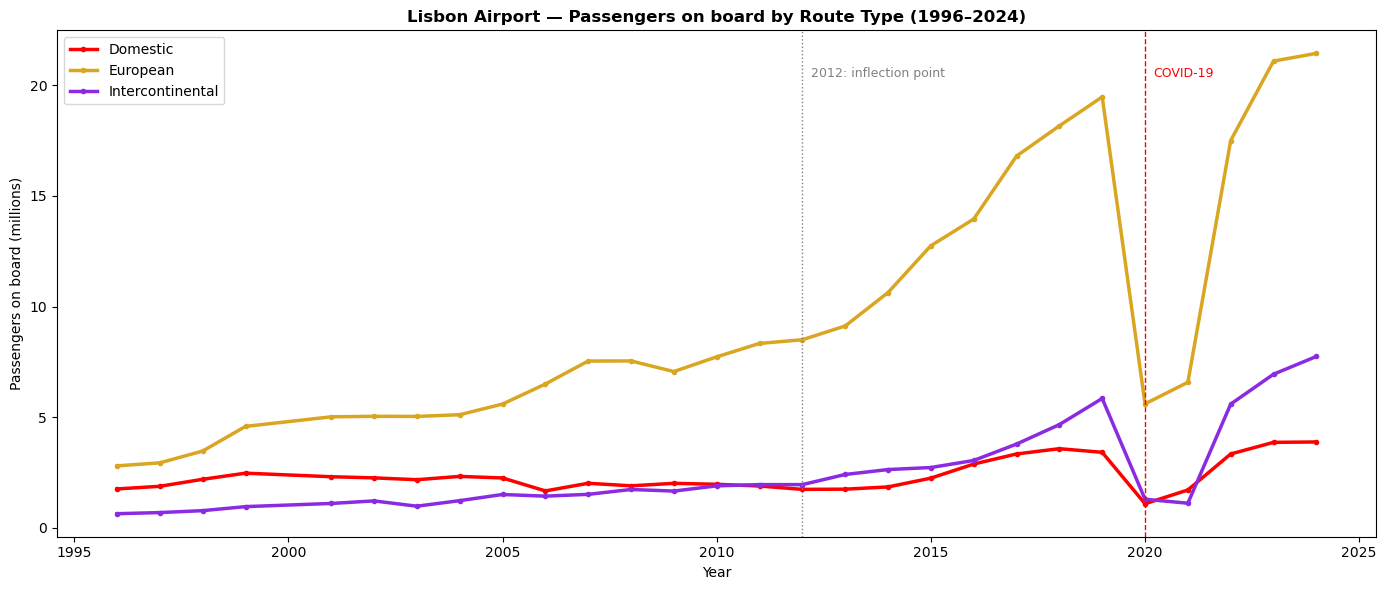

In [155]:
# Filter passengers and aggregate by year and route type
df_stacked = (df_agg[df_agg["tra_meas"] == "PAS_BRD"]
              .groupby(["year", "route_type"])["obs_value"].sum()
              .unstack(fill_value=0))

# Ensure all three columns exist
for col in ["Domestic", "European", "Intercontinental"]:
    if col not in df_stacked.columns:
        df_stacked[col] = 0

df_stacked = df_stacked[["Domestic", "European", "Intercontinental"]]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
colors = {"Domestic": "red", "European": "goldenrod", "Intercontinental": "blueviolet"}

for route_type, color in colors.items():
    ax.plot(df_stacked.index, df_stacked[route_type] / 1e6,
            label=route_type, color=color, linewidth=2.5, marker="o", markersize=3)

ax.axvline(x=2020, color="red", linestyle="--", linewidth=1)
ax.text(2020.2, df_stacked.max().max() / 1e6 * 0.95, "COVID-19", color="red", fontsize=9)
ax.axvline(x=2012, color="grey", linestyle="dotted", linewidth=1)
ax.text(2012.2, df_stacked.max().max() / 1e6 * 0.95, "2012: inflection point", color="grey", fontsize=9)
ax.set_title("Lisbon Airport — Passengers on board by Route Type (1996–2024)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Passengers on board (millions)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("RouteTypeEvolution.png", dpi=150, bbox_inches="tight")
plt.show()

### Domestic Route Network — 1999 vs. 2024

Domestic routes connect Lisbon to other Portuguese airports, including mainland destinations (Porto, Faro) and island groups (Madeira, Azores). Line thickness reflects the number of commercial flights on each route.

In [156]:
# Domestic
LISBON_LAT, LISBON_LON = 38.7756, -9.1354

images = {}

global_max = df_agg[
    (df_agg["tra_meas"] == "CAF_PAS") &
    (df_agg["route_type"] == "Domestic")
]["obs_value"].max()

for year in [1999, 2024]:
    df_year = (df_agg[
                (df_agg["year"] == year) &
                (df_agg["tra_meas"] == "CAF_PAS") &
                (df_agg["route_type"] == "Domestic")]
               .groupby(["city", "dest_lat", "dest_lon"])["obs_value"]
               .sum()
               .reset_index(name="flights")
               .dropna(subset=["dest_lat", "dest_lon"]))

    fig = go.Figure()
    for _, row in df_year.iterrows():
        lons = np.linspace(LISBON_LON, row["dest_lon"], 50)
        lats = np.linspace(LISBON_LAT, row["dest_lat"], 50)
        dist = np.sqrt((row["dest_lat"] - LISBON_LAT)**2 + (row["dest_lon"] - LISBON_LON)**2)
        arc_lats = lats + (np.sin(np.linspace(0, np.pi, 50)) * (dist * 0.15))
        fig.add_trace(go.Scattergeo(
            lon=lons, lat=arc_lats, mode="lines",
            line=dict(width=max(0.5, (row["flights"] / global_max) * 12), color="red"),
            opacity=0.5, hoverinfo="text",
            text=f"Route: Lisboa ↔ {row['city']}<br>Flights: {row['flights']:,}"
        ))
    fig.update_layout(
        title=dict(text=f"Lisbon Airport — Domestic Routes {year}", x=0.5),
        showlegend=False,
        geo=dict(
            scope="europe",
            projection_type="natural earth",
            center=dict(lat=39.5, lon=-8),
            projection_scale=2,
            showland=True, landcolor="lightgray",
            showocean=True, oceancolor="lightblue",
            showcountries=True, countrycolor="white"
        ),
        margin={"r": 0, "t": 60, "l": 0, "b": 0}
    )

    # Save to memory buffer
    buf = io.BytesIO()
    fig.write_image(buf, format="png", scale=2)
    buf.seek(0)
    images[year] = Image.open(buf).copy()
    buf.close()

    fig.show()

# --- Combine both years side by side ---
total_width  = images[1999].width + images[2024].width
total_height = max(images[1999].height, images[2024].height)

combined = Image.new("RGB", (total_width, total_height), "white")
combined.paste(images[1999], (0, 0))
combined.paste(images[2024], (images[1999].width, 0))

combined.save("DomesticRoutes.png")

### European Route Network — 1999 vs. 2024

European routes show the clearest expansion in Lisbon's network. The growth in route density between 1999 and 2024 reflects the entry of low-cost carriers and the diversification of destinations beyond traditional hubs.

In [157]:
# Europe
images = {}

global_max = df_agg[
    (df_agg["tra_meas"] == "CAF_PAS") &
    (df_agg["route_type"] == "European")
]["obs_value"].max()

for year in [1999, 2024]:
    df_year = (df_agg[
                (df_agg["year"] == year) &
                (df_agg["tra_meas"] == "CAF_PAS") &
                (df_agg["route_type"] == "European")]
               .groupby(["city", "dest_lat", "dest_lon"])["obs_value"]
               .sum()
               .reset_index(name="flights")
               .dropna(subset=["dest_lat", "dest_lon"]))

    fig = go.Figure()
    for _, row in df_year.iterrows():
        lons = np.linspace(LISBON_LON, row["dest_lon"], 50)
        lats = np.linspace(LISBON_LAT, row["dest_lat"], 50)
        dist = np.sqrt((row["dest_lat"] - LISBON_LAT)**2 + (row["dest_lon"] - LISBON_LON)**2)
        arc_lats = lats + (np.sin(np.linspace(0, np.pi, 50)) * (dist * 0.15))
        fig.add_trace(go.Scattergeo(
            lon=lons, lat=arc_lats, mode="lines",
            line=dict(width=max(0.5, (row["flights"] / global_max) * 12), color="goldenrod"),
            opacity=0.5, hoverinfo="text",
            text=f"Route: Lisboa ↔ {row['city']}<br>Flights: {row['flights']:,}"
        ))
    fig.update_layout(
        title=dict(text=f"Lisbon Airport — European Routes {year}", x=0.5),
        showlegend=False,
        geo=dict(
            scope="europe",
            projection_type="natural earth",
            showland=True, landcolor="lightgray",
            showocean=True, oceancolor="lightblue",
            showcountries=True, countrycolor="white"
        ),
        margin={"r": 0, "t": 60, "l": 0, "b": 0}
    )

    # Save to memory buffer
    buf = io.BytesIO()
    fig.write_image(buf, format="png", scale=2)
    buf.seek(0)
    images[year] = Image.open(buf).copy()
    buf.close()

    fig.show()

# --- Combine both years side by side ---
total_width  = images[1999].width + images[2024].width
total_height = max(images[1999].height, images[2024].height)

combined = Image.new("RGB", (total_width, total_height), "white")
combined.paste(images[1999], (0, 0))
combined.paste(images[2024], (images[1999].width, 0))

combined.save("EuropeanRoutes.png")

### Intercontinental Route Network — 1999 vs. 2024

Intercontinental routes highlight Lisbon's role as a gateway between Europe and Portuguese-speaking markets in Brazil and Africa, as well as connections to North America and the Middle East. The increased line thickness in 2024 reflects higher flight frequency on consolidated long-haul routes.

In [158]:
# Intercontinental
images = {}

global_max = df_agg[
    (df_agg["tra_meas"] == "CAF_PAS") &
    (df_agg["route_type"] == "Intercontinental")
]["obs_value"].max()

for year in [1999, 2024]:
    df_year = (df_agg[
                (df_agg["year"] == year) &
                (df_agg["tra_meas"] == "CAF_PAS") &
                (df_agg["route_type"] == "Intercontinental")]
               .groupby(["city", "dest_lat", "dest_lon"])["obs_value"]
               .sum()
               .reset_index(name="flights")
               .dropna(subset=["dest_lat", "dest_lon"]))

    fig = go.Figure()
    for _, row in df_year.iterrows():
        lons = np.linspace(LISBON_LON, row["dest_lon"], 50)
        lats = np.linspace(LISBON_LAT, row["dest_lat"], 50)
        dist = np.sqrt((row["dest_lat"] - LISBON_LAT)**2 + (row["dest_lon"] - LISBON_LON)**2)
        arc_lats = lats + (np.sin(np.linspace(0, np.pi, 50)) * (dist * 0.15))
        fig.add_trace(go.Scattergeo(
            lon=lons, lat=arc_lats, mode="lines",
            line=dict(width=max(0.5, (row["flights"] / global_max) * 12), color="blueviolet"),
            opacity=0.5, hoverinfo="text",
            text=f"Route: Lisboa ↔ {row['city']}<br>Flights: {row['flights']:,}"
        ))
    fig.update_layout(
        title=dict(text=f"Lisbon Airport — Intercontinental Routes {year}", x=0.5),
        showlegend=False,
        geo=dict(
            scope="world",
            projection_type="natural earth",
            showland=True, landcolor="lightgray",
            showocean=True, oceancolor="lightblue",
            showcountries=True, countrycolor="white"
        ),
        margin={"r": 0, "t": 60, "l": 0, "b": 0}
    )

    # Save to memory buffer
    buf = io.BytesIO()
    fig.write_image(buf, format="png", scale=2)
    buf.seek(0)
    images[year] = Image.open(buf).copy()
    buf.close()

    fig.show()

# --- Combine both years side by side ---
total_width  = images[1999].width + images[2024].width
total_height = max(images[1999].height, images[2024].height)

combined = Image.new("RGB", (total_width, total_height), "white")
combined.paste(images[1999], (0, 0))
combined.paste(images[2024], (images[1999].width, 0))

combined.save("IntercontinentalRoutes.png")

---
## Part 3 — Load Factor Analysis

This section constructs and analyses the load factor — a measure of how full flights are —  
across Lisbon Airport routes from 1996 to 2024.

## Load Factor Calculation

To evaluate whether flights are operating close to full capacity, a new feature called `load_factor` was created.

The load factor measures the percentage of occupied seats and was calculated as:

Load Factor = Passengers on Board / Available Seats × 100

The calculation was performed separately for:
- total bidirectional traffic (`PAS_BRD` / `ST_PAS`)
- arrivals (`PAS_BRD_ARR` / `ST_PAS_ARR`)
- departures (`PAS_BRD_DEP` / `ST_PAS_DEP`)

This approach ensures methodological consistency by matching passenger counts and seat availability for the same traffic direction and route type.



In [159]:
# =========================================================
# 1. Separate passenger and seat datasets
# =========================================================

pas_brd_df = df_agg[
    df_agg["tra_meas"].isin([
        "PAS_BRD",
        "PAS_BRD_DEP",
        "PAS_BRD_ARR"
    ])
].copy()

st_pas_df = df_agg[
    df_agg["tra_meas"].isin([
        "ST_PAS",
        "ST_PAS_DEP",
        "ST_PAS_ARR"
    ])
].copy()

# =========================================================
# 2. Create aligned measurement types
# =========================================================

measurement_mapping = {
    "PAS_BRD": "GENERAL",
    "PAS_BRD_DEP": "DEP",
    "PAS_BRD_ARR": "ARR",
    "ST_PAS": "GENERAL",
    "ST_PAS_DEP": "DEP",
    "ST_PAS_ARR": "ARR"
}

pas_brd_df["measure_type"] = (
    pas_brd_df["tra_meas"]
    .map(measurement_mapping)
)

st_pas_df["measure_type"] = (
    st_pas_df["tra_meas"]
    .map(measurement_mapping)
)

# =========================================================
# 3. Merge datasets
# =========================================================

load_factor_df = pas_brd_df.merge(
    st_pas_df,
    on=[
        "route_codes",
        "year",
        "measure_type"
    ],
    suffixes=("_pax", "_seat")
)

# =========================================================
# 4. Create final clean dataframe
# =========================================================

load_factor_df = load_factor_df[
    [
        "year",
        "route_codes",
        "route_pax",
        "airport1_code_pax",
        "airport1_name_pax",
        "airport2_code_pax",
        "airport2_name_pax",
        "measure_type",
        "obs_value_pax",
        "obs_value_seat"
    ]
]

# =========================================================
# 5. Rename columns
# =========================================================

load_factor_df = load_factor_df.rename(columns={
    "route_pax": "route",
    "airport1_code_pax": "airport1_code",
    "airport1_name_pax": "airport1_name",
    "airport2_code_pax": "airport2_code",
    "airport2_name_pax": "airport2_name",
    "obs_value_pax": "pas_brd",
    "obs_value_seat": "st_pas"
})

# =========================================================
# 6. Calculate load factor
# =========================================================

load_factor_df["load_factor"] = (
    load_factor_df["pas_brd"]
    / load_factor_df["st_pas"]
) * 100

# =========================================================
# 7. Cap values above 100
# =========================================================

load_factor_df["load_factor"] = (
    load_factor_df["load_factor"]
    .clip(upper=100)
)

# =========================================================
# 8. Round values
# =========================================================

load_factor_df["load_factor"] = (
    load_factor_df["load_factor"]
    .round(2)
)

# =========================================================
# 9. Remove years with anomalous or missing data
# =========================================================

load_factor_df = load_factor_df[
    ~load_factor_df["year"].isin([2000, 2001])
].copy()

# =========================================================
# 10. Preview
# =========================================================

load_factor_df.head()

,year,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,measure_type,pas_brd,st_pas,load_factor
0,1996,PT_LPPT_AO_FNLU,Lisbon Humberto Delgado Airport ↔ Luanda: Quat...,PT_LPPT,Lisbon Humberto Delgado Airport,AO_FNLU,Quatro de Fevereiro International Airport,GENERAL,109941,146467,75.06
1,1996,PT_LPPT_BE_EBBR,Lisbon Humberto Delgado Airport ↔ Zaventem: Br...,PT_LPPT,Lisbon Humberto Delgado Airport,BE_EBBR,Brussels Airport,GENERAL,237859,444720,53.49
2,1996,PT_LPPT_BR_SBGL,Lisbon Humberto Delgado Airport ↔ Rio De Janei...,PT_LPPT,Lisbon Humberto Delgado Airport,BR_SBGL,Rio Galeão – Tom Jobim International Airport,GENERAL,52316,75365,69.42
3,1996,PT_LPPT_BR_SBGR,Lisbon Humberto Delgado Airport ↔ São Paulo: S...,PT_LPPT,Lisbon Humberto Delgado Airport,BR_SBGR,São Paulo/Guarulhos–Governor André Franco Mont...,GENERAL,80444,124410,64.66
4,1996,PT_LPPT_CA_CYYZ,Lisbon Humberto Delgado Airport ↔ Toronto: Tor...,PT_LPPT,Lisbon Humberto Delgado Airport,CA_CYYZ,Toronto Pearson International Airport,GENERAL,41723,53679,77.73


## Data Quality Note — Years 2000 and 2001

During the exploratory phase, years 2000 and 2001 were identified as anomalous:
year 2000 was entirely absent from the dataset, and year 2001 showed load factors
close to 100% across all routes — highly unrealistic at an aggregate level.

To confirm the issue was not related to the passenger metric used, the load factor
was recalculated using `PAS_CRD` instead of `PAS_BRD`. The anomaly persisted,
confirming the problem originates in the Eurostat source data. Both years were
therefore excluded from the analysis.

In [160]:
# =========================================================
# 1. Extract PAS_CRD and ST_PAS data
# =========================================================

pas_crd_df = df_agg[
    df_agg["tra_meas"].isin([
        "PAS_CRD",
        "PAS_CRD_DEP",
        "PAS_CRD_ARR"
    ])
].copy()

st_pas_df = df_agg[
    df_agg["tra_meas"].isin([
        "ST_PAS",
        "ST_PAS_DEP",
        "ST_PAS_ARR"
    ])
].copy()

# =========================================================
# 2. Create aligned measurement types
# =========================================================

measurement_mapping = {
    "PAS_CRD": "GENERAL",
    "PAS_CRD_DEP": "DEP",
    "PAS_CRD_ARR": "ARR",
    "ST_PAS": "GENERAL",
    "ST_PAS_DEP": "DEP",
    "ST_PAS_ARR": "ARR"
}

pas_crd_df["measure_type"] = (
    pas_crd_df["tra_meas"]
    .map(measurement_mapping)
)

st_pas_df["measure_type"] = (
    st_pas_df["tra_meas"]
    .map(measurement_mapping)
)

# =========================================================
# 3. Merge datasets
# =========================================================

pas_crd_load_factor = pas_crd_df.merge(
    st_pas_df,
    on=[
        "route_codes",
        "year",
        "measure_type"
    ],
    suffixes=("_pax", "_seat")
)

# =========================================================
# 4. Calculate load factor
# =========================================================

pas_crd_load_factor["load_factor"] = (
    pas_crd_load_factor["obs_value_pax"]
    / pas_crd_load_factor["obs_value_seat"]
) * 100

# =========================================================
# 5. Cap and round values
# =========================================================

pas_crd_load_factor["load_factor"] = (
    pas_crd_load_factor["load_factor"]
    .clip(upper=100)
    .round(2)
)

# =========================================================
# 6. Mean yearly load factor
# =========================================================

pas_crd_yearly_lf = (
    pas_crd_load_factor
    .groupby("year")["load_factor"]
    .mean()
)

pas_crd_yearly_lf

year
1996    65.268272
1997    67.961410
1998    67.695952
1999    63.130937
2001    98.547292
2002    53.265196
2003    58.268559
2004    56.598452
2005    59.362414
2006    62.979293
2007    62.700000
2008    69.335175
2009    71.839722
2010    74.213417
2011    76.463171
2012    77.159250
2013    79.208333
2014    80.639821
2015    81.298103
2016    80.970808
2017    83.427879
2018    80.697341
2019    81.343723
2020    64.378730
2021    66.921377
2022    81.639770
2023    83.488723
2024    84.780737
Name: load_factor, dtype: float64

The same issue persists when using `PAS_CRD` instead of `PAS_BRD` to calculate the load factor.

First, the year 2000 is still completely missing from the dataset, confirming that the absence of data is not related to the passenger measurement selected. Additionally, the year 2001 continues to show abnormally high load factor values, reaching levels close to 100%, which is highly unrealistic at an aggregate route level.

Compared to the surrounding years, the 2001 values appear clearly inconsistent and strongly suggest the presence of reporting or measurement errors in the Eurostat data. Since the anomaly remains even after changing the passenger metric, the issue is likely rooted in the original source data rather than in the calculation methodology itself.

For this reason, both 2000 and 2001 were excluded from the analysis — as implemented in the load factor pipeline above. Although techniques such as  interpolation, forecasting, or imputation could be applied, introducing synthetic estimates for these years could generate artificial patterns and bias the interpretation of long-term trends.

## Filtering to Lisbon Routes

To focus the analysis specifically on Lisboa-related routes, we only consider observations where Lisboa appears as `airport1`.

This filtering step is necessary to avoid double-counting the same bidirectional route.  
In the original dataset, many routes are reported twice:

- once as `LISBOA AIRPORT ↔ PORTO AIRPORT`
- and once as `PORTO AIRPORT ↔ LISBOA AIRPORT`

By restricting the dataset to cases where Lisboa is `airport1`, we ensure that each Lisboa route is counted only once while preserving consistency across all route-level analyses.

In [161]:
# Create dataframe only for routes where Lisboa is airport1

lisbon_df = load_factor_df[
    load_factor_df["airport1_name"]
    .str.contains("Lisbon", case=False, na=False)
].copy()


In [162]:
lisbon_df["route"].unique()

array(['Lisbon Humberto Delgado Airport ↔ Luanda: Quatro de Fevereiro International Airport',
       'Lisbon Humberto Delgado Airport ↔ Zaventem: Brussels Airport',
       'Lisbon Humberto Delgado Airport ↔ Rio De Janeiro: Rio Galeão – Tom Jobim International Airport',
       'Lisbon Humberto Delgado Airport ↔ São Paulo: São Paulo/Guarulhos–Governor André Franco Montoro International Airport',
       'Lisbon Humberto Delgado Airport ↔ Toronto: Toronto Pearson International Airport',
       'Lisbon Humberto Delgado Airport ↔ Geneva: Geneva International Airport',
       'Lisbon Humberto Delgado Airport ↔ Zurich: Zürich Airport',
       'Lisbon Humberto Delgado Airport ↔ Espargos: Amílcar Cabral International Airport',
       'Lisbon Humberto Delgado Airport ↔ Frankfurt am Main: Frankfurt Main Airport',
       'Lisbon Humberto Delgado Airport ↔ Düsseldorf: Düsseldorf Airport',
       'Lisbon Humberto Delgado Airport ↔ Munich: Munich Airport',
       'Lisbon Humberto Delgado Airport ↔ Cop

## Preparing a Clean Route Label (`route_clean`)

Before moving to the visualization phase, we create a helper column called
`route_clean` to make the plots readable. The original `route` column stores
the full official names, e.g.
`Lisbon Humberto Delgado Airport ↔ Paris: Charles de Gaulle International Airport`.
These strings are far too long for chart axes and legends: a single label can
take up half the plot, squeezing the actual data into a narrow strip.

To fix this, `route_clean` rewrites each route following a few simple rules:

- **Airport1** — since every route departs from Lisbon, the verbose
  `Lisbon Humberto Delgado Airport` is collapsed to just `Lisbon`.
- **Direction** — the arrow (`↔`, `←`, `→`) is kept, because it encodes the
  measurement type (general traffic, arrivals, departures).
- **Airport2** — only the city name is kept (`Madrid`, `Amsterdam`, …),
  dropping the long airport name.
- **Cities with more than one airport** — to avoid losing information, the
  airport name is appended in parentheses. This is detected automatically from
  the data, and in our case it applies to seven cities: **Paris, London, Rome,
  Moscow, Doha, Istanbul, Montréal**.

The result is a compact, unambiguous label such as `Lisbon ↔ Madrid`,
`Lisbon ↔ Paris (Orly)`, or `Lisbon ↔ London (Heathrow)`.

Two properties make this column convenient for the plots that follow:

1. **Uniqueness is preserved.** Because multi-airport cities keep their airport
   name, grouping by `route_clean` produces exactly the same groups as grouping
   by the original `route`. The aggregations are identical; only the labels are
   shorter.
2. **No per-chart cleaning is needed.** Since the labels are already clean,
   every chart can simply use `route_clean` directly in `groupby`, on the axes,
   or in the legend — no extra formatting step is required.

> **Note on the source data.** A few destinations store the municipality where
> the airport sits rather than the metropolitan city (e.g. *Segrate* = Milan
> Linate, *Ferno* = Milan Malpensa, *Zaventem* = Brussels, *Orio al Serio* = Bergamo), and some include a
> region suffix (e.g. *Nice, Alpes-Maritimes*). These are kept as-is, since
> normalizing them would require a manual lookup table and is not needed for the
> analysis.

In [163]:
import unicodedata
from collections import defaultdict

ARROWS = ["↔", "←", "→"]
GENERIC = {"International", "Intl", "Airport", "airport"}

def _norm(s):
    """Accent-insensitive lowercase, so 'Montréal' matches 'Montreal'."""
    return "".join(c for c in unicodedata.normalize("NFKD", s)
                   if not unicodedata.combining(c)).lower()

def _parse_route(route):
    arrow = next(a for a in ARROWS if a in route)   # ↔ / ← / →
    dest = route.split(arrow)[-1].strip()           # "City: Airport Full Name"
    city, _, airport = dest.partition(":")
    return arrow, city.strip(), airport.strip()

def _clean_airport(airport, city):
    """Short airport name: drop generic words and a repeated city prefix."""
    city_tokens = {_norm(t) for t in city.split()}
    cleaned = " ".join(w for w in airport.split() if w not in GENERIC).strip(" -–/")
    if _norm(cleaned).startswith(_norm(city)):
        cleaned = cleaned[len(city):].strip(" -–/")
    if not cleaned:  # airport named like the city -> keep distinguishing words
        rest = [w for w in airport.split()
                if w.lower() != "airport" and _norm(w) not in city_tokens]
        cleaned = " ".join(rest).strip(" -–/")
    if not cleaned:
        cleaned = " ".join(w for w in airport.split() if w.lower() != "airport").strip(" -–/")
    return cleaned or airport

# Detect cities that have more than one airport in the dataset
_city_airports = defaultdict(set)
for r in lisbon_df["route"].unique():
    _, c, a = _parse_route(r)
    _city_airports[c].add(a)
MULTI = {c for c, aps in _city_airports.items() if len(aps) > 1}

def clean_route(route):
    arrow, city, airport = _parse_route(route)
    label = f"{city} ({_clean_airport(airport, city)})" if city in MULTI else city
    return f"Lisbon {arrow} {label}"

# Create the new column
lisbon_df["route_clean"] = lisbon_df["route"].apply(clean_route)

## Separation of Traffic Measurements into Independent DataFrames

To preserve the original structure of the Eurostat aviation dataset and avoid introducing artificial aggregation assumptions, the analysis was divided into three separate dataframes based on the traffic measurement type:

- `GENERAL`
- `ARR` (arrivals)
- `DEP` (departures)

This distinction is important because Eurostat records aviation traffic from different operational perspectives.

For example:
- departure flows are reported from the origin airport perspective,
- arrival flows are reported from the destination airport perspective,
- while `GENERAL` measurements represent aggregated bidirectional traffic reported by each airport authority.

During the exploratory analysis, it became evident that combining these measurements into a single dataset could lead to:
- duplicated route observations,
- inflated passenger totals,
- and ambiguous traffic interpretation.

To avoid these methodological issues, the dataset was separated into three analytical layers:

### `general_df`
Used for:
- airport congestion analysis,
- route network evolution,
- long-term demand growth,
- load factor evolution,
- infrastructure capacity assessment.

### `arr_df`
Used for:
- inbound traffic analysis,
- arrival-side operational pressure.

### `dep_df`
Used for:
- outbound traffic analysis,
- departure-side dynamics

This approach preserves the integrity of the original Eurostat reporting structure while ensuring clearer and more reliable interpretations of the aviation traffic dynamics.

In [164]:
general_df = lisbon_df[
    lisbon_df["measure_type"] == "GENERAL"
].copy()

arr_df = lisbon_df[
    lisbon_df["measure_type"] == "ARR"
].copy()

dep_df = lisbon_df[
    lisbon_df["measure_type"] == "DEP"
].copy()

# Plots Section - Building visualizations

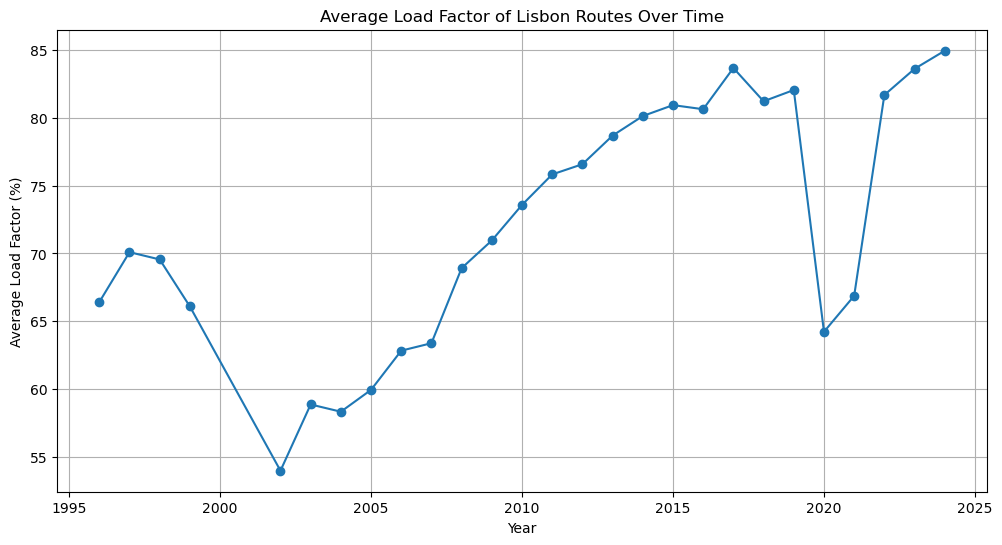

In [165]:
# =========================================================
# Average yearly load factor for Lisbon routes
# =========================================================

lisbon_load_factor = (
    general_df
    .groupby("year")["load_factor"]
    .mean()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    lisbon_load_factor.index,
    lisbon_load_factor.values,
    marker="o"
)

# =========================================================
# Labels and title
# =========================================================

plt.title("Average Load Factor of Lisbon Routes Over Time")

plt.xlabel("Year")

plt.ylabel("Average Load Factor (%)")

# =========================================================
# Grid
# =========================================================

plt.grid(True)

# =========================================================
# Show plot
# =========================================================

plt.show()

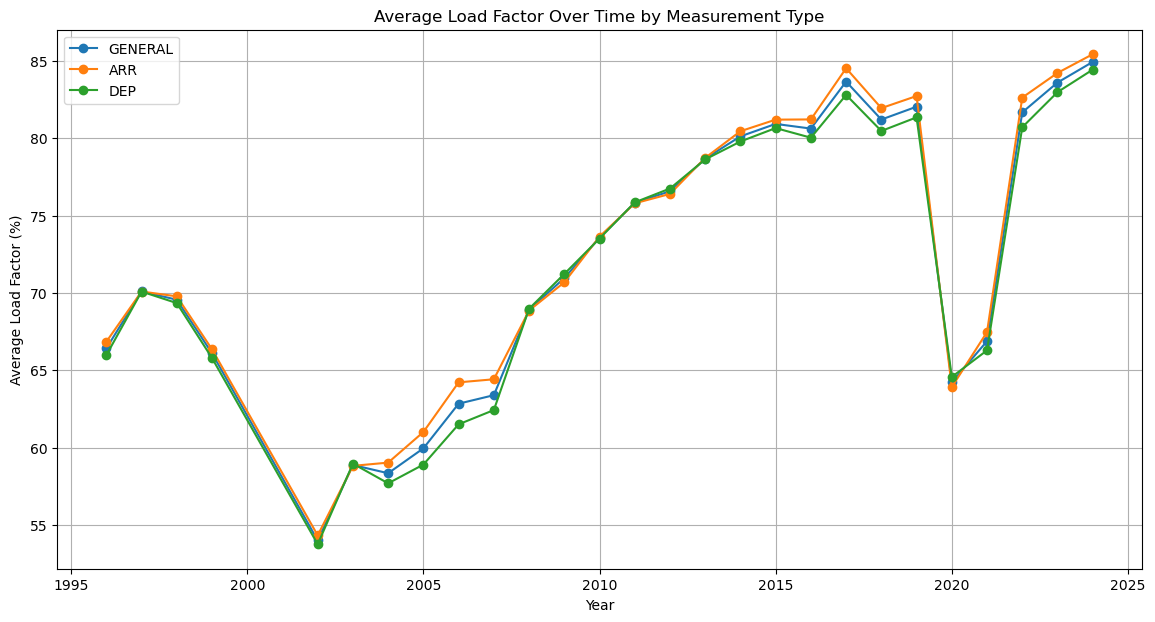

In [166]:
# =========================================================
# Compute yearly average load factor
# =========================================================

general_lf = (
    general_df
    .groupby("year")["load_factor"]
    .mean()
)

arr_lf = (
    arr_df
    .groupby("year")["load_factor"]
    .mean()
)

dep_lf = (
    dep_df
    .groupby("year")["load_factor"]
    .mean()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(14, 7))

plt.plot(
    general_lf.index,
    general_lf.values,
    marker="o",
    label="GENERAL"
)

plt.plot(
    arr_lf.index,
    arr_lf.values,
    marker="o",
    label="ARR"
)

plt.plot(
    dep_lf.index,
    dep_lf.values,
    marker="o",
    label="DEP"
)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Average Load Factor Over Time by Measurement Type"
)

plt.xlabel("Year")

plt.ylabel("Average Load Factor (%)")

# =========================================================
# Legend and grid
# =========================================================

plt.legend()

plt.grid(True)

# =========================================================
# Show plot
# =========================================================

plt.show()

### Evolution of Load Factor Over Time

The graph shows a clear long-term increase in the average load factor of flights connected to Lisbon airport, considering general traffic as well as arrivals (`ARR`) and departures (`DEP`).

Although data for 2000 and 2001 is missing, the series reveals a significant decrease beginning in 2002, when average load factors dropped to nearly 54%. A plausible explanation is the global impact of the September 11th attacks in 2001, which generated a strong decline in air travel demand and a widespread “panic effect” among passengers worldwide. This shock affected the aviation industry for several years and is visible in Lisbon’s traffic patterns as well.

After this downturn, the airport experienced a long and almost uninterrupted recovery phase. From the mid-2000s onward, load factors increased steadily year after year, indicating progressively fuller aircraft and stronger demand for flights connected to Lisbon. This growth became particularly evident after 2010, coinciding with the expansion of low-cost airlines, the rapid growth of tourism in Portugal, and Lisbon’s increasing popularity as an international destination.

**During the pandemic, the load factor for arrivals fell slightly below that for departures** — the reverse of the usual pattern. It is worth being careful about what this can and cannot tell us. Most ordinary air travel is round-trip: a tourist who arrives in Lisbon also leaves, so over any reasonable period the number of arriving and departing passengers tends to balance out. For this reason, tourism cannot really explain a directional imbalance between arrivals and departures, since incoming flows are mirrored by outgoing ones.
A more convincing explanation for the 2020 inversion is a temporary, one-directional movement of people. Lisbon hosts a large community of foreign students and workers, and during the lockdowns many of them likely returned to their home countries — without a matching return leg in that same period. Unlike round-trip tourism, this kind of net outflow genuinely breaks the arrivals–departures balance, producing fuller outbound flights and emptier inbound ones precisely when it occurred. As mobility normalized, the flow reversed and the usual relationship was restored.
This remains a hypothesis: load factor data alone cannot confirm the cause, and the small differences observed in normal years are more plausibly explained by structural factors — such as differences in the seat capacity scheduled on inbound versus outbound flights — than by the direction of demand. Confirming the migration explanation would require additional data, such as passenger residency, enrollment or visa records, or migration statistics for the period.

Overall, aside from major global disruptions such as 9/11 and COVID-19, the trend remains remarkably stable and consistently upward. **By 2024, the average load factor exceeds 85%**, meaning that flights operating to and from Lisbon are now running close to full capacity on average. This is a strong indicator of sustained pressure on the airport infrastructure and reinforces the broader discussion about whether Lisbon’s current airport capacity is sufficient for future demand.

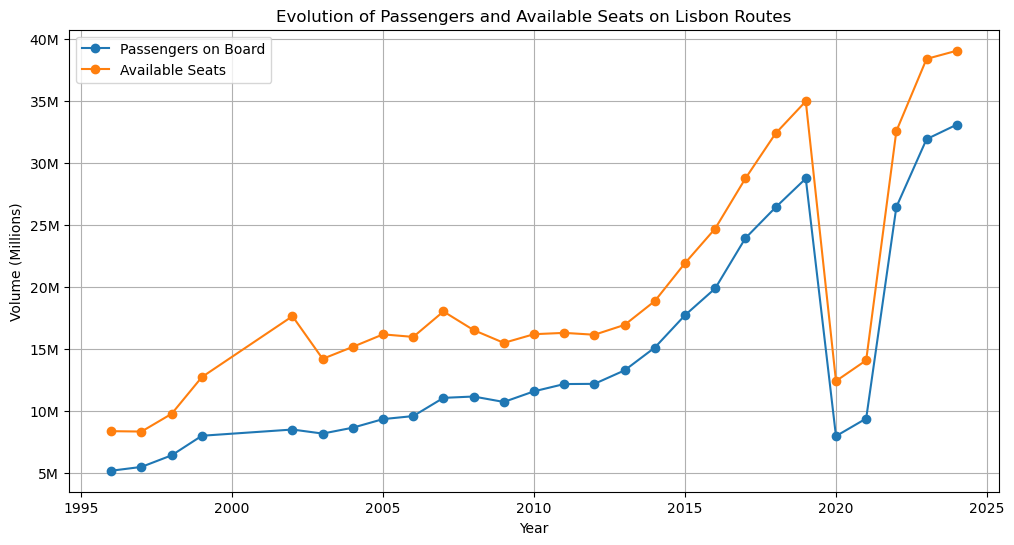

In [167]:
# =========================================================
# Aggregate yearly passengers and seats
# =========================================================

traffic_evolution = (
    general_df
    .groupby("year")[["pas_brd", "st_pas"]]
    .sum()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    traffic_evolution.index,
    traffic_evolution["pas_brd"],
    marker="o",
    label="Passengers on Board"
)

plt.plot(
    traffic_evolution.index,
    traffic_evolution["st_pas"],
    marker="o",
    label="Available Seats"
)

# =========================================================
# Format Y axis in millions
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f'{x/1_000_000:.0f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Labels and title
# =========================================================

plt.title("Evolution of Passengers and Available Seats on Lisbon Routes")

plt.xlabel("Year")

plt.ylabel("Volume (Millions)")

# =========================================================
# Legend and grid
# =========================================================

plt.legend()

plt.grid(True)

# =========================================================
# Show plot
# =========================================================

plt.show()

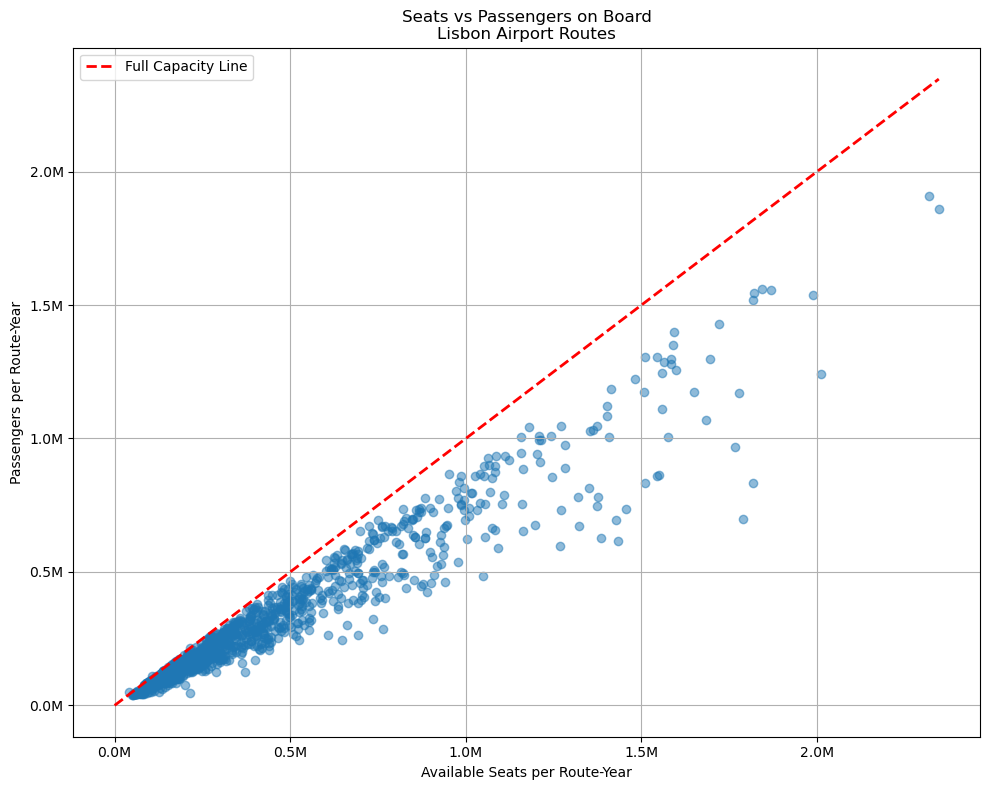

In [168]:
# Scatter plot: Seats vs Passengers
# =========================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    general_df["st_pas"],
    general_df["pas_brd"],
    alpha=0.5
)

# =========================================================
# Add diagonal reference line
# =========================================================

max_value = max(
    general_df["st_pas"].max(),
    general_df["pas_brd"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Full Capacity Line"
)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Seats vs Passengers on Board\nLisbon Airport Routes"
)

plt.xlabel("Available Seats per Route-Year")

plt.ylabel("Passengers per Route-Year")

# =========================================================
# Grid and legend
# =========================================================

plt.grid(True)

plt.legend()

# =========================================================
# Format axes in millions
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f"{x/1_000_000:.1f}M"
)

plt.gca().xaxis.set_major_formatter(formatter)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Layout
# =========================================================


plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Relationship Between Passenger Demand and Available Capacity

These two graphs provide complementary perspectives on the relationship between passenger demand and seat availability on Lisbon airport routes. Together, they reveal a clear pattern: although airlines have continuously expanded capacity over time, demand has grown at a very similar pace, leading to increasingly **high aircraft occupancy levels.**

The first graph illustrates the long-term evolution of total passengers on board and available seats between 1996 and 2024. Both curves follow an almost parallel trajectory, especially after 2010, indicating that airlines consistently adjusted capacity in response to rising demand rather than generating excessive oversupply. As Lisbon became a stronger tourism and international mobility hub, airlines progressively increased frequencies, routes, and aircraft capacity to accommodate growing traffic.

The sharp expansion after 2014 is particularly significant. **Passenger numbers rose from around 18 million to more than 33 million in less than a decade**, while **available seats increased from approximately 22 million to almost 39 million**. This demonstrates not only rapid aviation growth, but also the airport’s increasing operational intensity.

The second graph reinforces this interpretation at the route-year level. Each point represents a specific route in a given year, comparing available seats with passengers transported. The red dashed line represents theoretical full capacity, where every available seat would be occupied.

Most observations are concentrated relatively close to this full-capacity line, showing a strong positive relationship between seat supply and actual passenger demand. In practice, routes with more available seats also tend to transport proportionally more passengers, suggesting that airlines are generally operating with efficient capacity allocation rather than maintaining large numbers of empty seats.

Another important observation is that very few points approach complete saturation. This indicates that airlines still maintain a safety margin between maximum capacity and effective occupancy, which is operationally necessary for flexibility and market stability. However, the density of points near the upper section of the graph suggests that many major routes are operating with relatively high occupancy levels, especially in recent years.

The COVID-19 pandemic appears clearly in the temporal evolution graph as an abrupt collapse in both passengers and available seats during 2020. Nevertheless, the recovery afterward is exceptionally rapid, with both variables surpassing pre-pandemic levels within only a few years. This reinforces the idea that Lisbon’s aviation demand is not temporary or purely cyclical, but structurally strong and increasingly sustained over time.

Taken together, these graphs suggest that the airport’s growth has not been driven simply by airlines artificially increasing supply. Instead, Lisbon appears to be experiencing **genuine demand expansion**, where increases in available capacity are consistently absorbed by passenger traffic. This dynamic contributes directly to the **growing pressure on airport infrastructure** and helps explain why discussions surrounding airport saturation and future expansion have intensified in recent years.

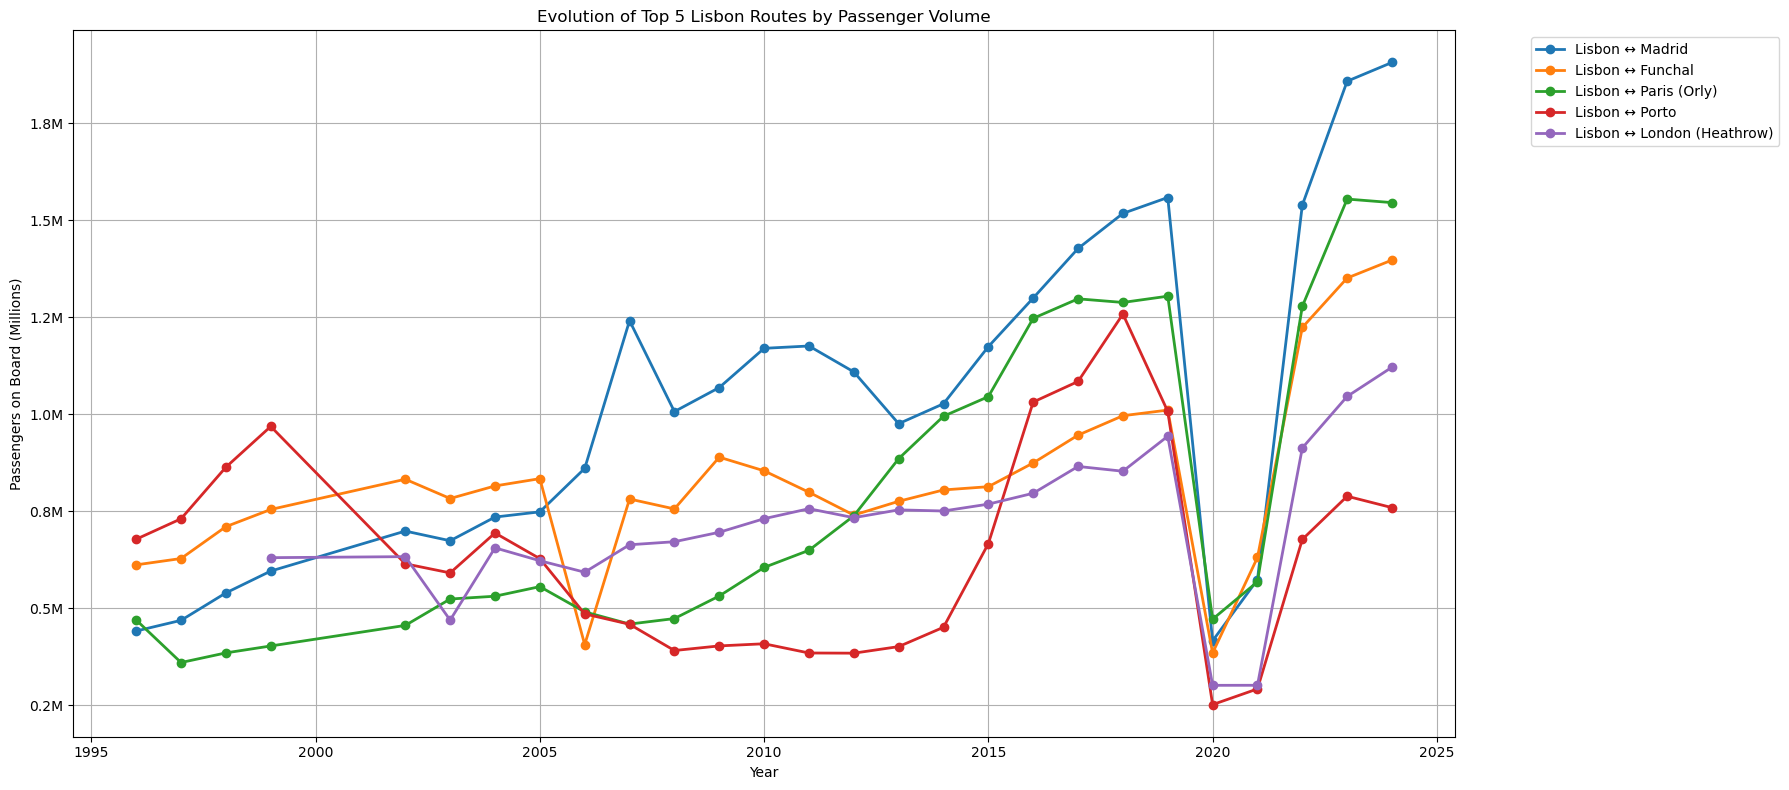

In [169]:
# =========================================================
# Identify top 5 routes by total passengers
# =========================================================

top_routes = (
    general_df
    .groupby("route_clean")["pas_brd"]
    .sum()
    .nlargest(5)
    .index
)

# =========================================================
# Filter dataframe
# =========================================================

top_routes_df = general_df[
    general_df["route_clean"].isin(top_routes)
]

# =========================================================
# Aggregate yearly passengers
# =========================================================

top_routes_yearly = (
    top_routes_df
    .groupby(
        ["year", "route_clean"]
    )["pas_brd"]
    .sum()
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(18, 8))

for route in top_routes:

    route_data = top_routes_yearly[
        top_routes_yearly["route_clean"] == route
    ]

    plt.plot(
        route_data["year"],
        route_data["pas_brd"],
        marker="o",
        linewidth=2,
        label=route
    )

# =========================================================
# Format Y axis
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f'{x/1_000_000:.1f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Evolution of Top 5 Lisbon Routes by Passenger Volume"
)

plt.xlabel("Year")

plt.ylabel("Passengers on Board (Millions)")

# =========================================================
# Legend and grid
# =========================================================

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Evolution of the Top 5 Lisbon Routes by Passenger Volume

This graph highlights the evolution of the five busiest routes connected to Lisbon airport in terms of passenger volume between 1996 and 2024. The selected routes reveal how Lisbon’s connectivity has progressively shifted toward a more international and tourism-oriented network.

The **Lisbon–Madrid route consistently appears as the dominant connection throughout most of the timeline**. Its strong and continuous growth reflects Madrid’s importance both as a business hub and as a major international connection point for Iberian and intercontinental flights. By 2024, this route exceeds 2 million passengers, making it the busiest route in the dataset.

The Paris-Orly route also shows remarkable long-term growth, especially after 2012. This increase is likely linked to the strong historical, economic, and migratory ties between Portugal and France, combined with the expansion of tourism flows between the two countries. By the end of the period, Paris-Orly becomes the second-largest route, reaching approximately 1.6 million passengers annually.

Routes connected to islands, particularly Madeira, maintain consistently high passenger volumes throughout the entire series. Unlike many continental routes that fluctuate more significantly according to economic conditions or tourism trends, island connections represent an essential mobility corridor for residents, tourism, and economic activity. The Madeira route therefore combines both tourism demand and structural transportation necessity.

The **Lisbon–Porto route** presents one of the most interesting patterns in the graph. During the late 1990s it was among the busiest routes, but passenger volumes **declined substantially throughout the 2000s**. A plausible explanation is the expansion and modernization of alternative transportation systems between the two cities, particularly the improvement of rail services and highway infrastructure, which reduced the competitiveness of domestic air travel on short distances. However, after 2015 the route partially recovered, possibly due to tourism growth and increased connecting traffic through Lisbon airport.

London Heathrow demonstrates a more stable and progressive trajectory. As one of Europe’s most important global hubs, Heathrow plays a key role in connecting Lisbon to long-haul international destinations. The route experiences strong growth after the pandemic recovery, surpassing 1 million passengers by 2024.

All routes display a **dramatic collapse in 2020 due to the COVID-19 pandemic, followed by an exceptionally rapid rebound**. In most cases, passenger volumes recovered to — and often surpassed — pre-pandemic levels within only a few years. This reinforces the idea that Lisbon’s air traffic demand remains structurally strong across different types of routes: business-oriented, tourism-oriented, domestic, and international.

Another important observation is the increasing dominance of international routes over domestic ones in recent years. Madrid, Paris, and London all show significantly stronger long-term growth compared to Porto, suggesting that Lisbon airport is becoming progressively more integrated into international tourism and global mobility networks rather than relying primarily on domestic traffic.

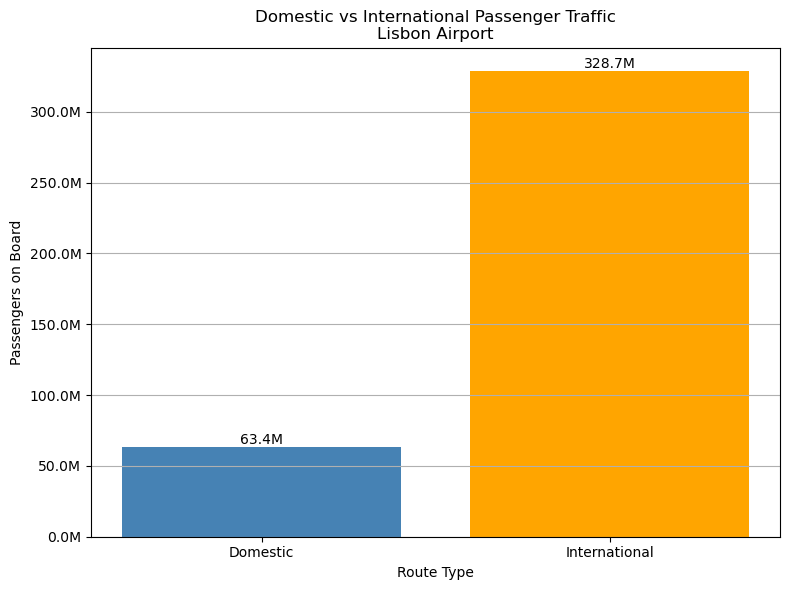

In [170]:
# =========================================================
# Create route type category
# =========================================================

general_df["route_type"] = np.where(
    general_df["airport2_code"].str.startswith("PT_"),
    "Domestic",
    "International"
)

# =========================================================
# Aggregate total passengers
# =========================================================

route_type_df = (
    general_df
    .groupby("route_type")["pas_brd"]
    .sum()
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(8, 6))

plt.bar(
    route_type_df["route_type"],
    route_type_df["pas_brd"],
    color=["steelblue", "orange"]
)

# =========================================================
# Format Y axis
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f'{x/1_000_000:.1f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Domestic vs International Passenger Traffic\nLisbon Airport"
)

plt.xlabel("Route Type")

plt.ylabel("Passengers on Board")

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(route_type_df["pas_brd"]):

    plt.text(
        index,
        value,
        f'{value/1_000_000:.1f}M',
        ha="center",
        va="bottom"
    )

# =========================================================
# Grid
# =========================================================

plt.grid(axis="y")

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

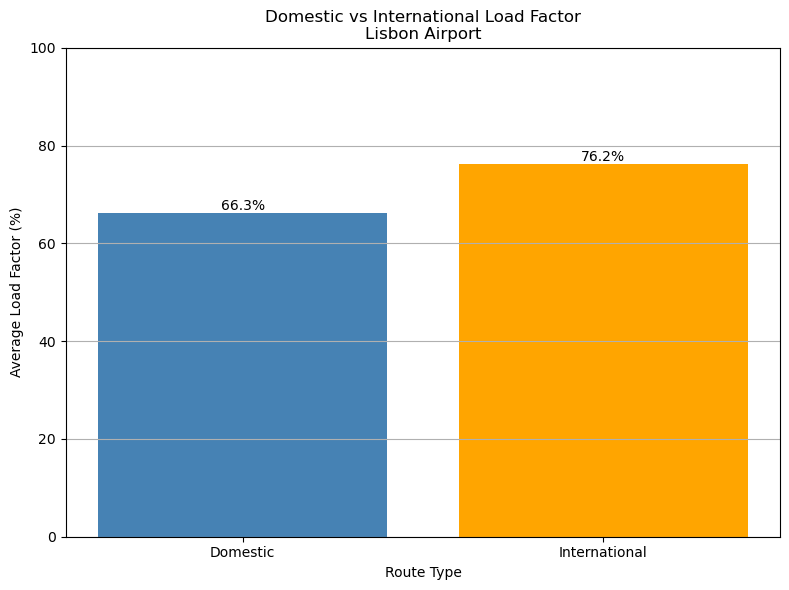

In [171]:
# =========================================================
# Aggregate average load factor
# =========================================================

route_type_lf_df = (
    general_df
    .groupby("route_type")["load_factor"]
    .mean()
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(8, 6))

plt.bar(
    route_type_lf_df["route_type"],
    route_type_lf_df["load_factor"],
    color=["steelblue", "orange"]
)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Domestic vs International Load Factor\nLisbon Airport"
)

plt.xlabel("Route Type")

plt.ylabel("Average Load Factor (%)")

# =========================================================
# Y-axis limits
# =========================================================

plt.ylim(0, 100)

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(route_type_lf_df["load_factor"]):

    plt.text(
        index,
        value,
        f'{value:.1f}%',
        ha="center",
        va="bottom"
    )

# =========================================================
# Grid
# =========================================================

plt.grid(axis="y")

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Domestic vs International Traffic at Lisbon Airport

These graphs clearly reinforce one of the central findings of the analysis: Lisbon airport depends overwhelmingly on international air traffic, both in terms of passenger volume and infrastructure utilization.

The first chart shows a massive imbalance between domestic and international passenger traffic. International routes account for approximately **328.7 million passengers**, while domestic routes represent only **63.4 million passengers** across the analyzed period. In practice, this means that the airport’s activity is driven primarily by international mobility rather than internal Portuguese connectivity.

This result is consistent with the previous route-level analysis. International connections such as Madrid, Paris-Orly, and London Heathrow have experienced much stronger and more sustained growth over time compared to domestic routes like Porto. While domestic aviation remains important, especially for island connections such as Madeira and the Azores, the long-term expansion of Lisbon airport is fundamentally linked to tourism, international business travel, and Lisbon’s growing role as a European destination and transit hub.

The second graph adds another important dimension to this interpretation. International routes not only transport far more passengers, but they also operate with significantly higher load factors. International flights reach an average load factor of approximately **76.2%**, compared to only **66.3%** for domestic flights.

This indicates that international routes are considerably more saturated, meaning airlines are filling a much larger proportion of the available seats on these flights. In operational terms, this suggests stronger and more concentrated demand pressure on the airport’s international network.

Several factors may explain this difference:

- International tourism demand toward Lisbon has increased dramatically over the last decade.
- Lisbon functions as a gateway city connecting Europe, the Americas, and parts of Africa.
- Domestic routes face stronger competition from alternative transportation systems, particularly rail and highway infrastructure between Lisbon and Porto.
- Many domestic flights operate partly for territorial cohesion and connectivity purposes, especially island routes, which may reduce the pressure to maximize seat occupancy compared to highly competitive international routes.

Taken together, these results suggest that the debate surrounding airport overcapacity is primarily an international traffic issue rather than a domestic one. The strongest pressure on Lisbon airport infrastructure appears to originate from international demand, which is both substantially larger and consistently more capacity-intensive.

This also helps explain why the busiest and fastest-growing routes in the dataset are predominantly international. Lisbon airport is progressively evolving from a mainly national airport into an international mobility hub heavily dependent on tourism and global connectivity.

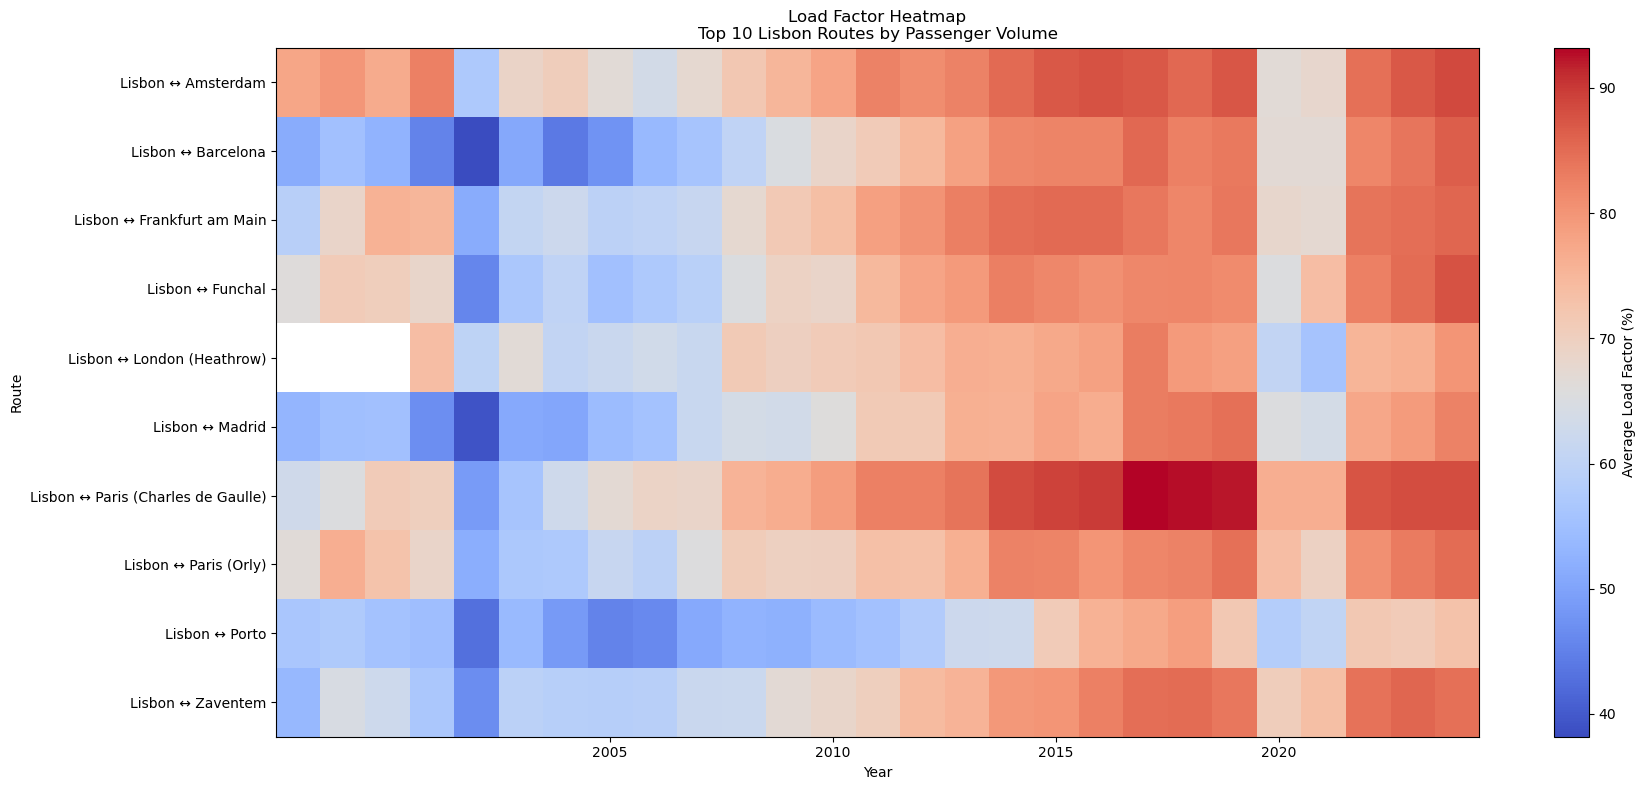

In [172]:
# =========================================================
# Identify top 10 routes by total passengers
# =========================================================

top_routes = (
    general_df
    .groupby("route_clean")["pas_brd"]
    .sum()
    .nlargest(10)
    .index
)

# =========================================================
# Create pivot table for heatmap
# =========================================================

heatmap_df = (
    general_df[
        general_df["route_clean"].isin(top_routes)
    ]
    .pivot_table(
        index="route_clean",
        columns="year",
        values="load_factor",
        aggfunc="mean"
    )
)

# =========================================================
# Plot heatmap
# =========================================================

plt.figure(figsize=(18, 8))

im = plt.imshow(
    heatmap_df,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm"
)

# =========================================================
# Colorbar
# =========================================================

cbar = plt.colorbar(im)

cbar.set_label("Average Load Factor (%)")

# =========================================================
# Axis labels and ticks
# =========================================================

plt.title(
    "Load Factor Heatmap\nTop 10 Lisbon Routes by Passenger Volume"
)

plt.xlabel("Year")

plt.ylabel("Route")

# Y-axis labels
plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

# X-axis labels every 5 years
years = heatmap_df.columns

x_positions = [
    i for i, year in enumerate(years)
    if year % 5 == 0
]

x_labels = [
    year for year in years
    if year % 5 == 0
]

plt.xticks(
    x_positions,
    x_labels
)

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Load Factor Heatmap of the Top Lisbon Routes

This heatmap provides a detailed view of how the average load factor evolved over time for the ten busiest routes connected to Lisbon airport. Each row represents a route, while each column corresponds to a year. Warmer colors (orange/red) indicate higher load factors and therefore greater seat occupancy, whereas cooler colors (blue) indicate lower occupancy levels.

Several important patterns emerge from the visualization.

First, there is a clear long-term transition from cooler to warmer colors across almost all routes. This indicates that **flights connected to Lisbon have become progressively more crowded over time**, reinforcing the broader conclusion that demand growth has consistently outpaced or closely matched increases in available capacity.

The early 2000s show noticeably lower load factors across many routes, particularly around 2002–2003. This aligns with the broader slowdown in global aviation following the September 11th attacks and the temporary decline in international air travel demand.

From approximately 2010 onward, most international routes begin to display consistently **high load factors**, often exceeding 80%. This trend is especially visible on routes such as:

- Paris Charles de Gaulle
- Amsterdam Schiphol
- Frankfurt/Main
- Madrid-Barajas
- Barcelona El Prat

These routes increasingly operate near high occupancy levels, suggesting strong structural demand linked to tourism, business mobility, and Lisbon’s growing integration into major European aviation networks.

Paris Charles de Gaulle stands out as one of the most saturated routes in the dataset, reaching load factors above 90% in some years. This suggests extremely efficient seat utilization and sustained passenger demand over time.

In contrast, domestic routes — especially Porto — maintain significantly lower load factors throughout much of the timeline. Even though the Lisbon–Porto route remains important, it rarely reaches the occupancy levels observed on major international connections. This supports previous findings suggesting that domestic aviation faces stronger competition from alternative transportation systems such as railways and highways, reducing pressure on air travel demand between the two cities.

Island routes such as Madeira occupy an intermediate position. Their load factors increase steadily over time and eventually reach levels comparable to international routes. This likely reflects the dual role of these routes as both tourism corridors and essential territorial connectivity links.

The COVID-19 pandemic is clearly visible in 2020 and 2021, where nearly all routes experience abrupt decreases in load factor. However, the recovery afterward is extremely rapid. By 2023 and 2024, many routes not only recover but return to historically high occupancy levels.

Overall, the heatmap strongly reinforces the idea that the **increasing pressure on Lisbon airport is driven primarily by highly saturated international routes**. The persistence of high load factors across multiple major European destinations suggests that Lisbon’s aviation growth is not concentrated in a single market, but distributed across a broad international network with consistently strong demand.

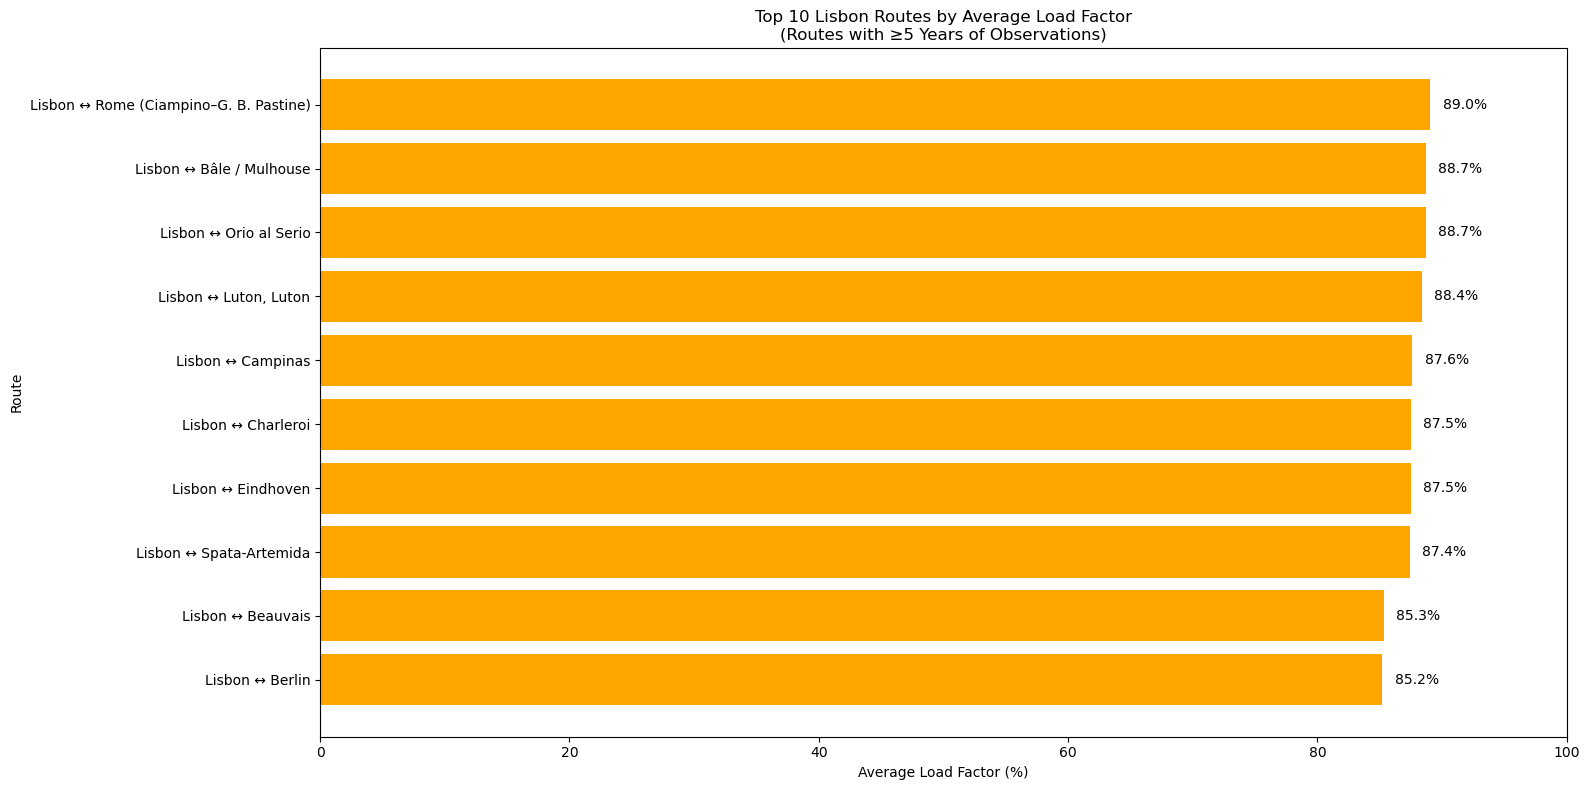

In [173]:
# =========================================================
# Find routes with at least 5 years of observations
# =========================================================

valid_routes = (
    general_df
    .groupby("route_clean")["year"]
    .nunique()
)

valid_routes = valid_routes[
    valid_routes >= 5
].index

# =========================================================
# Filter dataframe
# =========================================================

filtered_df = general_df[
    general_df["route_clean"].isin(valid_routes)
]

# =========================================================
# Calculate average load factor per route
# =========================================================

top_routes_lf = (
    filtered_df
    .groupby("route_clean")["load_factor"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(16, 8))

plt.barh(
    top_routes_lf["route_clean"],
    top_routes_lf["load_factor"],
    color="orange"

)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Top 10 Lisbon Routes by Average Load Factor\n(Routes with ≥5 Years of Observations)"
)

plt.xlabel("Average Load Factor (%)")

plt.ylabel("Route")

# =========================================================
# X-axis limits
# =========================================================

plt.xlim(0, 100)

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(top_routes_lf["load_factor"]):

    plt.text(
        value + 1,
        index,
        f"{value:.1f}%",
        va="center"
    )

# =========================================================
# Improve readability
# =========================================================

plt.gca().invert_yaxis()

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

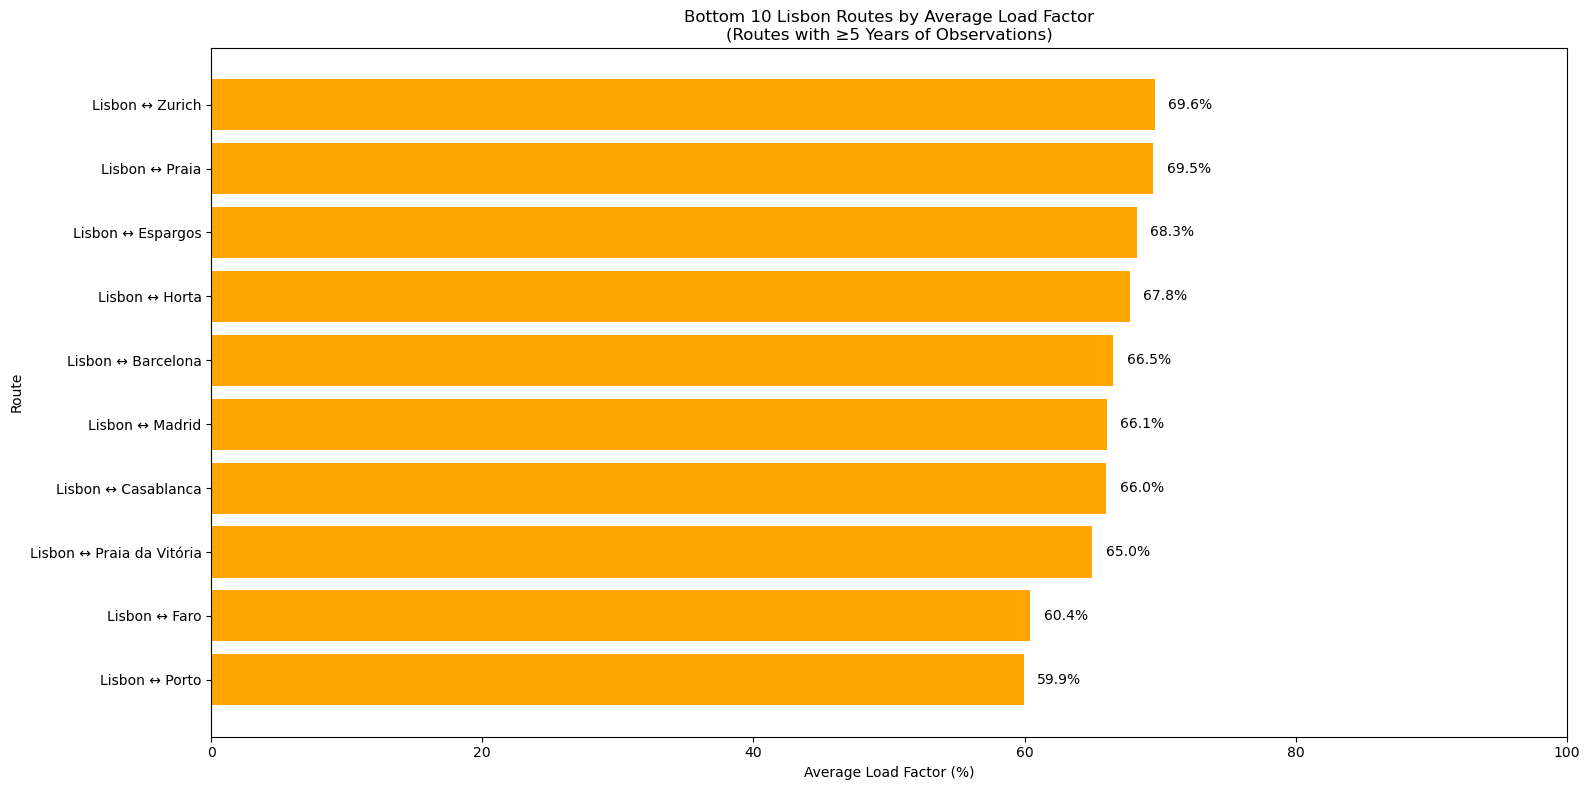

In [174]:
# =========================================================
# Calculate average load factor per route
# =========================================================

top_routes_lf = (
    filtered_df
    .groupby("route_clean")["load_factor"]
    .mean()
    .sort_values(ascending=False)
    .tail(10)
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(16, 8))

plt.barh(
    top_routes_lf["route_clean"],
    top_routes_lf["load_factor"],
    color="orange"

)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Bottom 10 Lisbon Routes by Average Load Factor\n(Routes with ≥5 Years of Observations)"
)

plt.xlabel("Average Load Factor (%)")

plt.ylabel("Route")

# =========================================================
# X-axis limits
# =========================================================

plt.xlim(0, 100)

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(top_routes_lf["load_factor"]):

    plt.text(
        value + 1,
        index,
        f"{value:.1f}%",
        va="center"
    )

# =========================================================
# Improve readability
# =========================================================

plt.gca().invert_yaxis()

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Comparison Between the Highest and Lowest Load Factor Routes

These two graphs highlight a strong contrast between the most saturated and the least saturated routes connected to Lisbon airport. The comparison reveals important differences in the nature of demand across Lisbon’s aviation network.

The routes with the highest average load factors are entirely international and strongly associated with tourism flows, low-cost travel demand, or major European mobility corridors. Connections such as Rome Ciampino, London Luton, Bergamo, Charleroi, Eindhoven, and Beauvais are all airports heavily used by low-cost carriers and leisure-oriented travelers.

Most of these routes maintain average load factors close to or above 85%, indicating extremely efficient seat utilization and consistently strong passenger demand. Airlines operating on these routes appear capable of filling a very large proportion of available seats over long periods of time.

This pattern strongly reinforces the idea that Lisbon’s airport pressure is driven primarily by international demand, especially tourism-related and low-cost international traffic.

In contrast, the routes with the lowest average load factors are dominated by domestic connections and peripheral territorial routes, particularly:

- Porto
- Faro
- Horta
- Lajes
- Other Atlantic/island routes

The **Lisbon–Porto route**, despite being one of the country’s most important mobility corridors, records the **lowest average load factor** in the ranking at approximately 60%. Faro also shows relatively low occupancy levels.

A likely explanation is the strong competition from alternative transportation systems on domestic mainland routes. The relatively short distances between Lisbon, Porto, and Faro make air travel less competitive compared to cheaper and more flexible alternatives such as:

- Intercity trains
- Private cars
- Long-distance buses
- Low-cost coach operators such as FlixBus

In recent years, companies like FlixBus have rapidly expanded in Portugal, offering extremely low prices and high-frequency connections between major Portuguese cities. This likely reduced pressure on domestic aviation demand, particularly for routes where travel times by land remain relatively manageable.

At the same time, several low-load-factor routes correspond to island or peripheral territories where flights are maintained partly for territorial cohesion and accessibility rather than purely for profitability or maximum occupancy optimization. In these cases, maintaining connectivity may be strategically more important than maximizing seat utilization.

Another interesting observation is that some extremely high-volume routes — such as Madrid-Barajas and Barcelona El Prat — still appear among the lower load-factor rankings. This suggests that high passenger volume alone does not necessarily imply high occupancy rates. These routes may operate with very large flight frequencies and substantial seat availability, creating more capacity relative to demand compared to ultra-efficient low-cost routes.

Overall, these graphs reveal a clear structural divide within Lisbon’s route network:

- International leisure and low-cost routes tend to operate with very high occupancy and saturation levels.
- Domestic mainland routes generally operate with lower load factors due to shorter distances and competition from alternative transportation modes.
- Peripheral and island routes fulfill broader territorial and connectivity functions beyond pure demand efficiency.

This distinction is essential for understanding where the real pressure on Lisbon airport infrastructure originates: not from domestic connectivity, but primarily from **highly saturated international demand.**

---
## Part 4 — Seasonality Analysis

This section constructs and analyses the monthly seasonality by number of passengers flying in or out of the Lisbon Airport between January 2004 and December 2024.

## Data Importation & Cleaning

The Seasonality Analysis will be conducted in a new monthly dataset from Eurostat, which will also require preprocessing before 
analysis. 

In this section, we will begin by combining the 4 datasets, inspect the datasets, remove any unnacessary information, change 
collumn names to become more user friendly, separate the date column into 2 distinct columns (Month + Year) and, finally, remove 
the data that is out of scope (Lisbon Airport)



In [175]:
# Importat the 4 monthly datasets
url_monthly = "https://raw.githubusercontent.com/iddadobroc/PDS_Airport_Analysis/main/"

monthly0406 = pd.read_csv(url_monthly + "eurostat_passenger_PT_monthly_2004_2006.csv")
monthly0712 = pd.read_csv(url_monthly + "eurostat_passenger_PT_monthly_2007_2012.csv")
monthly1318 = pd.read_csv(url_monthly + "eurostat_passenger_PT_monthly_2013_2018.csv")
monthly1924 = pd.read_csv(url_monthly + "eurostat_passenger_PT_monthly_2019_2024.csv")

print(f"monthly0406: {monthly0406.shape[0]} rows, {monthly0406.shape[1]} columns")
print(f"monthly0712: {monthly0712.shape[0]} rows, {monthly0712.shape[1]} columns")
print(f"monthly1318: {monthly1318.shape[0]} rows, {monthly1318.shape[1]} columns")
print(f"monthly1924: {monthly1924.shape[0]} rows, {monthly1924.shape[1]} columns")

HTTPError: HTTP Error 404: Not Found

In [ ]:
# Concatenate the 4 data sets into a single one
monthly = pd.concat([monthly0406, monthly0712, monthly1318, monthly1924])

print(f"monthly: {monthly.shape[0]} rows, {monthly.shape[1]} columns")

In [ ]:
# Check for missing information (null values) in the dataset
monthly.isna().sum()

In [ ]:
# Check for unique values in each column
print(monthly.nunique())

In [ ]:
# Quick look at the information in the dataset
print(monthly.head(), "\n")

## Removal of Empty and Non-Informative Columns

During the initial inspection of the dataset, several columns were identified as either completely empty or non-informative for the analysis.
Additionally, our seasonality analysis will be solely based on the Lisbon Airport, so all other Airports will be removed from the analysis.

1. Columns "OBS_FLAG" and "CONF_STATUS" will be removed as they are either all or almost all with empty values.

2. Columns 1 to 3 provide unnecessary information such as the date of the download and the frequency of the dataset (monthly), therefore these columns
will also be removed

3. Eliminate the data for airports that are not Lisbon (out of scope)

In [ ]:
# Copy of the original data frame, which will be the basis for the modifications needed
monthly1 = monthly.copy()

In [ ]:
# Drops the first 3 columns (unnecessary information)
monthly1 = monthly1.iloc[:, 3:]

# Drops the last 2 columns (none or almost none values)
monthly1 = monthly1.dropna(axis=1)

print(monthly1.head())

In [ ]:
# Eliminates the data for airports that are not Lisbon (out of scope)
monthly_lis = monthly1[
    monthly1["airp_pr"].str.startswith("LISBOA airport -")
]

print(monthly_lis.head())

## Formatting and Organization

The information in the dataset includes several abreviations, information in uppercases, and other formatting errors that can be fixed in order to
have a more readable dataset, and therefore more userfriendly.

Also, the date information is presented as "yyyy-mm", which will be separated into two columns (Year + Month) to help on the seasonality analysis.

In [ ]:
# Changes the column names
monthly_lis = monthly_lis.rename(columns={
    "unit": "Unit",
    "tra_meas": "Traffic_Type",
    "airp_pr": "Route",
    "TIME_PERIOD": "Date",
    "OBS_VALUE": "Value"
})

# Separates Date into two columns (Year + Month) to support the seasonality analysis
monthly_lis["Date"] = pd.to_datetime(monthly_lis["Date"])

monthly_lis["Year"] = monthly_lis["Date"].dt.year

# Transforms the month numbers from numbers (1, 2, ...) into their abbreviations (Jan, Feb, ...) - helpfull for graphs
monthly_lis["Month"] = monthly_lis["Date"].dt.strftime("%b")

# Guarantees that the months will be correctly ordered (instead of alphabetical)
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_lis["Month"] = pd.Categorical(
    monthly_lis["Month"],
    categories=month_order,
    ordered=True
)

# Removes original Date column
monthly_lis = monthly_lis.drop("Date", axis=1)

print(monthly_lis.head())

In [ ]:
# Make the data more readable and easy to understand

# Summarize the info of traffic type
monthly_lis["Traffic_Type"] = monthly_lis["Traffic_Type"].replace({
    "Commercial passenger air flights (arrivals)": "Flights - Arrivals",
    "Commercial passenger air flights (departures)": "Flights - Departures",
    "Passengers on board (arrivals)": "Passengers - Arrivals",
    "Passengers on board (departures)": "Passengers - Departures",
    "Passengers seats available (arrivals)": "Seats Available - Arrivals",
    "Passengers seats available (departures)": "Seats Available - Departures"
})

# Remove "airport" and caps lock from column route
monthly_lis["Route"] = (
    monthly_lis["Route"]
    .str.replace(" airport", "", regex=False)
    .str.title()
)

# Check if the changes were correctly done
print(monthly_lis["Unit"].unique(), "\n")
print(monthly_lis["Traffic_Type"].unique(), "\n")
print(monthly_lis["Route"].head())

In [ ]:
# Visualisation of the dataset
monthly_lis

In [ ]:
# Total Passenger Arrivals and Departures per Year in Lisbon

passenger_totals = (
    monthly_lis[
        monthly_lis["Traffic_Type"].isin([
            "Passengers - Arrivals",
            "Passengers - Departures"
        ])
    ]
    .groupby(
        ["Year", "Traffic_Type"],
        observed=False
    )["Value"]
    .sum()
    .reset_index()
)

# Converts into wide format
passenger_totals = passenger_totals.pivot_table(
    index="Year",
    columns="Traffic_Type",
    values="Value",
    aggfunc="sum",
    observed=False
).reset_index()

# Renames columns
passenger_totals.columns = [
    "Year",
    "Passenger_Arrivals",
    "Passenger_Departures"
]

# Converts to millions (easier to read in graphs)
passenger_totals["Passenger_Arrivals"] = (
    passenger_totals["Passenger_Arrivals"] / 1_000_000
)

passenger_totals["Passenger_Departures"] = (
    passenger_totals["Passenger_Departures"] / 1_000_000
)

print(
    passenger_totals.round(3).to_string(index=False)
)

## 4.1 Seasonality Analysis

While the previous sections focused mainly on yearly trends, it is also important to understand how passenger demand changes throughout the year.

This section analyses the seasonal behaviour of passenger arrivals and departures at Lisbon Airport between 2004 and 2024. By examining monthly traffic patterns and comparing different years, we aim to identify recurring trends, peak travel periods, and months with lower levels of activity.

Understanding these seasonal variations can provide additional insight into how airport capacity is used over time and whether operational pressure is concentrated during specific periods of the year or reflects a broader long-term growth trend.

To analyse seasonality, we conduct two separate analyses: (i) passenger arrivals and (ii) passenger departures. For each analysis, we examine three variables: flights, passengers, and seats and berths. 
We start by checking whether these variables are correlated and follow similar patterns over time. We then use a set of visualizations to explore how they change throughout the year, helping us identify seasonal trends, peak periods, and months with lower activity.

## 4.1.1 Arrivals Seasonality

In [ ]:
# Test if the three variables (Flights, Passengers and Avaialbles Seats) display high correlation between them

# Filter only for arrivals
arrivals = monthly_lis[
    monthly_lis["Traffic_Type"].isin([
        "Flights - Arrivals",
        "Passengers - Arrivals",
        "Seats Available - Arrivals"
    ])
]

# Aggregate Arrivals by Year, Month and Traffic
monthly_arrivals = (
    arrivals
    .groupby(["Year", "Month", "Traffic_Type"], observed=False)["Value"]
    .sum()
    .reset_index()
)

arrivals_pivot = monthly_arrivals.pivot_table(
    observed=False,
    index=["Year", "Month"],
    columns="Traffic_Type",
    values="Value",
    aggfunc="sum"
).reset_index()

spearman_corr = arrivals_pivot.drop(columns=["Year", "Month"]).corr(method="spearman")

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Heatmap - Arrivals")
plt.xlabel(None)
plt.ylabel(None)
plt.show()

---
The heatmap confirms a very strong positive correlation (>0.97) between the number of Flights, Passengers and Available Seats.
This was to be expected, as an increase in the number of flights usually results in more seats being available, which in turn leads to higher number of passengers.
Given the strong correlation, it is justified to base our analysis solely on one of the variables, as the others would be redundant (similar results).
In this case, we have selected the number of Passengers as it is the one who best represents travel demand, while the other variables are more related to airline supply.

---

In [ ]:
# Average and Median Passengers per month
overall_stats = (
    passengers_monthly
    .groupby("Month", observed=False)["Value"]
    .agg(["mean", "median"])
    .reset_index()
)

overall_stats.columns = [
    "Month",
    "Average_Passengers (k)",
    "Median_Passengers (k)"
]

overall_stats["Month"] = overall_stats["Month"]

print(
    overall_stats.round(0).to_string(index=False)
)

In [ ]:
# Ranking the months by the number of passengers
month_ranking = (
    passengers_monthly
    .groupby("Month", observed=False)["Value"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

month_ranking.columns = [
    "Month",
    "Average_Passengers (k)"
]

month_ranking["Month"] = month_ranking["Month"]

print(
    month_ranking.round(0).to_string(index=False)
)

---
Passenger arrivals are highest during the summer months, with July recording the largest average number of passengers. Traffic starts increasing in spring, peaks during summer, and then gradually falls towards winter. This pattern suggests that arrivals are strongly influenced by tourism and holiday travel demand.

---

In [ ]:
# Average and Median Passengers per month for each year
yearly_stats = (
    passengers_monthly
    .groupby(["Year", "Month"], observed=False)["Value"]
    .agg(["mean", "median"])
    .reset_index()
)

yearly_stats.columns = [
    "Year",
    "Month",
    "Average_Passengers (k)",
    "Median_Passengers (k)"
]

print(yearly_stats.round(0))

In [ ]:
# Ranking the months by the number of passengers each year
monthly_rankings = (
    passengers_monthly
    .groupby(["Year", "Month"], observed=False)["Value"]
    .mean()
    .reset_index()
)

monthly_rankings["Rank"] = (
    monthly_rankings
    .groupby("Year")["Value"]
    .rank(ascending=False, method="dense")
)

monthly_rankings = monthly_rankings.sort_values(
    ["Year", "Rank"]
)


# Frequency of each ranking per month
ranking_frequency = (
    monthly_rankings
    .pivot_table(
        observed=False,
        index="Month",
        columns="Rank",
        values="Year",
        aggfunc="count",
        fill_value=0
    )
)

# Excluding 2020 (Covid)
monthly_rankings_no2020 = monthly_rankings[
    monthly_rankings["Year"] != 2020
]

# Frequency table of rankings per month
ranking_frequency_no2020 = (
    monthly_rankings_no2020
    .pivot_table(
        observed=False,
        index="Month",
        columns="Rank",
        values="Year",
        aggfunc="count",
        fill_value=0
    )
)


print(monthly_rankings.round(0))
print(ranking_frequency.round(0))
print(ranking_frequency_no2020.round(0))

---
The ranking results confirm a strong seasonal pattern in passenger arrivals. July and August most frequently appear among the highest-ranked months, while January and February are consistently among the lowest.

The year 2020 was not considered, as it would distort the ranking with outliers, such as January/February recording a Top 3 rank due to travell limitations during that year.

---

In [176]:
# Total Passengers per year
yearly_totals = (
    passengers_monthly
    .groupby("Year")["Value"]
    .sum()
    .reset_index()
)

yearly_totals.columns = [
    "Year",
    "Total_Passengers (k)"
]

yearly_totals["Absolute_Growth"] = (
    yearly_totals["Total_Passengers (k)"]
    .diff()
)

yearly_totals["Percent_Growth"] = (
    yearly_totals["Total_Passengers (k)"]
    .pct_change() * 100
).round(2)

print(
    yearly_totals.round(0).to_string(index=False)
)

 Year  Total_Passengers (k)  Absolute_Growth  Percent_Growth
 2004                   5.0              NaN             NaN
 2005                   5.0              0.0             8.0
 2006                   5.0              0.0             7.0
 2007                   6.0              1.0            10.0
 2008                   6.0              0.0             0.0
 2009                   5.0             -0.0            -5.0
 2010                   6.0              0.0             8.0
 2011                   6.0              0.0             5.0
 2012                   6.0              0.0             1.0
 2013                   7.0              1.0             9.0
 2014                   8.0              1.0            16.0
 2015                   9.0              1.0            12.0
 2016                  10.0              1.0            12.0
 2017                  12.0              2.0            21.0
 2018                  13.0              1.0            10.0
 2019                  1

In [177]:
# CAGR 2004-2024
def CAGR(start_value, end_value, periods):
    return ((end_value / start_value) ** (1 / periods) - 1) * 100

start_2004 = yearly_totals.loc[
    yearly_totals["Year"] == 2004,
    "Total_Passengers (k)"
].values[0]

end_2024 = yearly_totals.loc[
    yearly_totals["Year"] == 2024,
    "Total_Passengers (k)"
].values[0]

cagr_2004_2024 = CAGR(start_2004, end_2024, 20)

print(f"CAGR 2004-2024: {cagr_2004_2024:.2f}%")

CAGR 2004-2024: 6.71%


---
The yearly passenger totals show a strong long-term growth trend at Lisbon Airport between 2004 and 2024. Total passenger arrivals increased from approximately 4.5 million passengers in 2004 to more than 16.6 million in 2024, representing an increase of almost four times.

Following a period of steady expansion, passenger traffic experienced a sharp decline in 2020 as a result of the COVID-19 pandemic and associated travel restrictions, with passenger arrivals decreasing by approximately 73% compared to 2019.

However, passenger volumes rebounded rapidly between 2021 and 2023, and by 2024 passenger arrivals had surpassed all previous records.

The **Compound Annual Growth Rate (CAGR) of 6.71%** over the 2004–2024 period indicates sustained long-term growth, reflecting a broader structural expansion of air travel demand and the growing importance of Lisbon as an international destination and aviation hub.

---

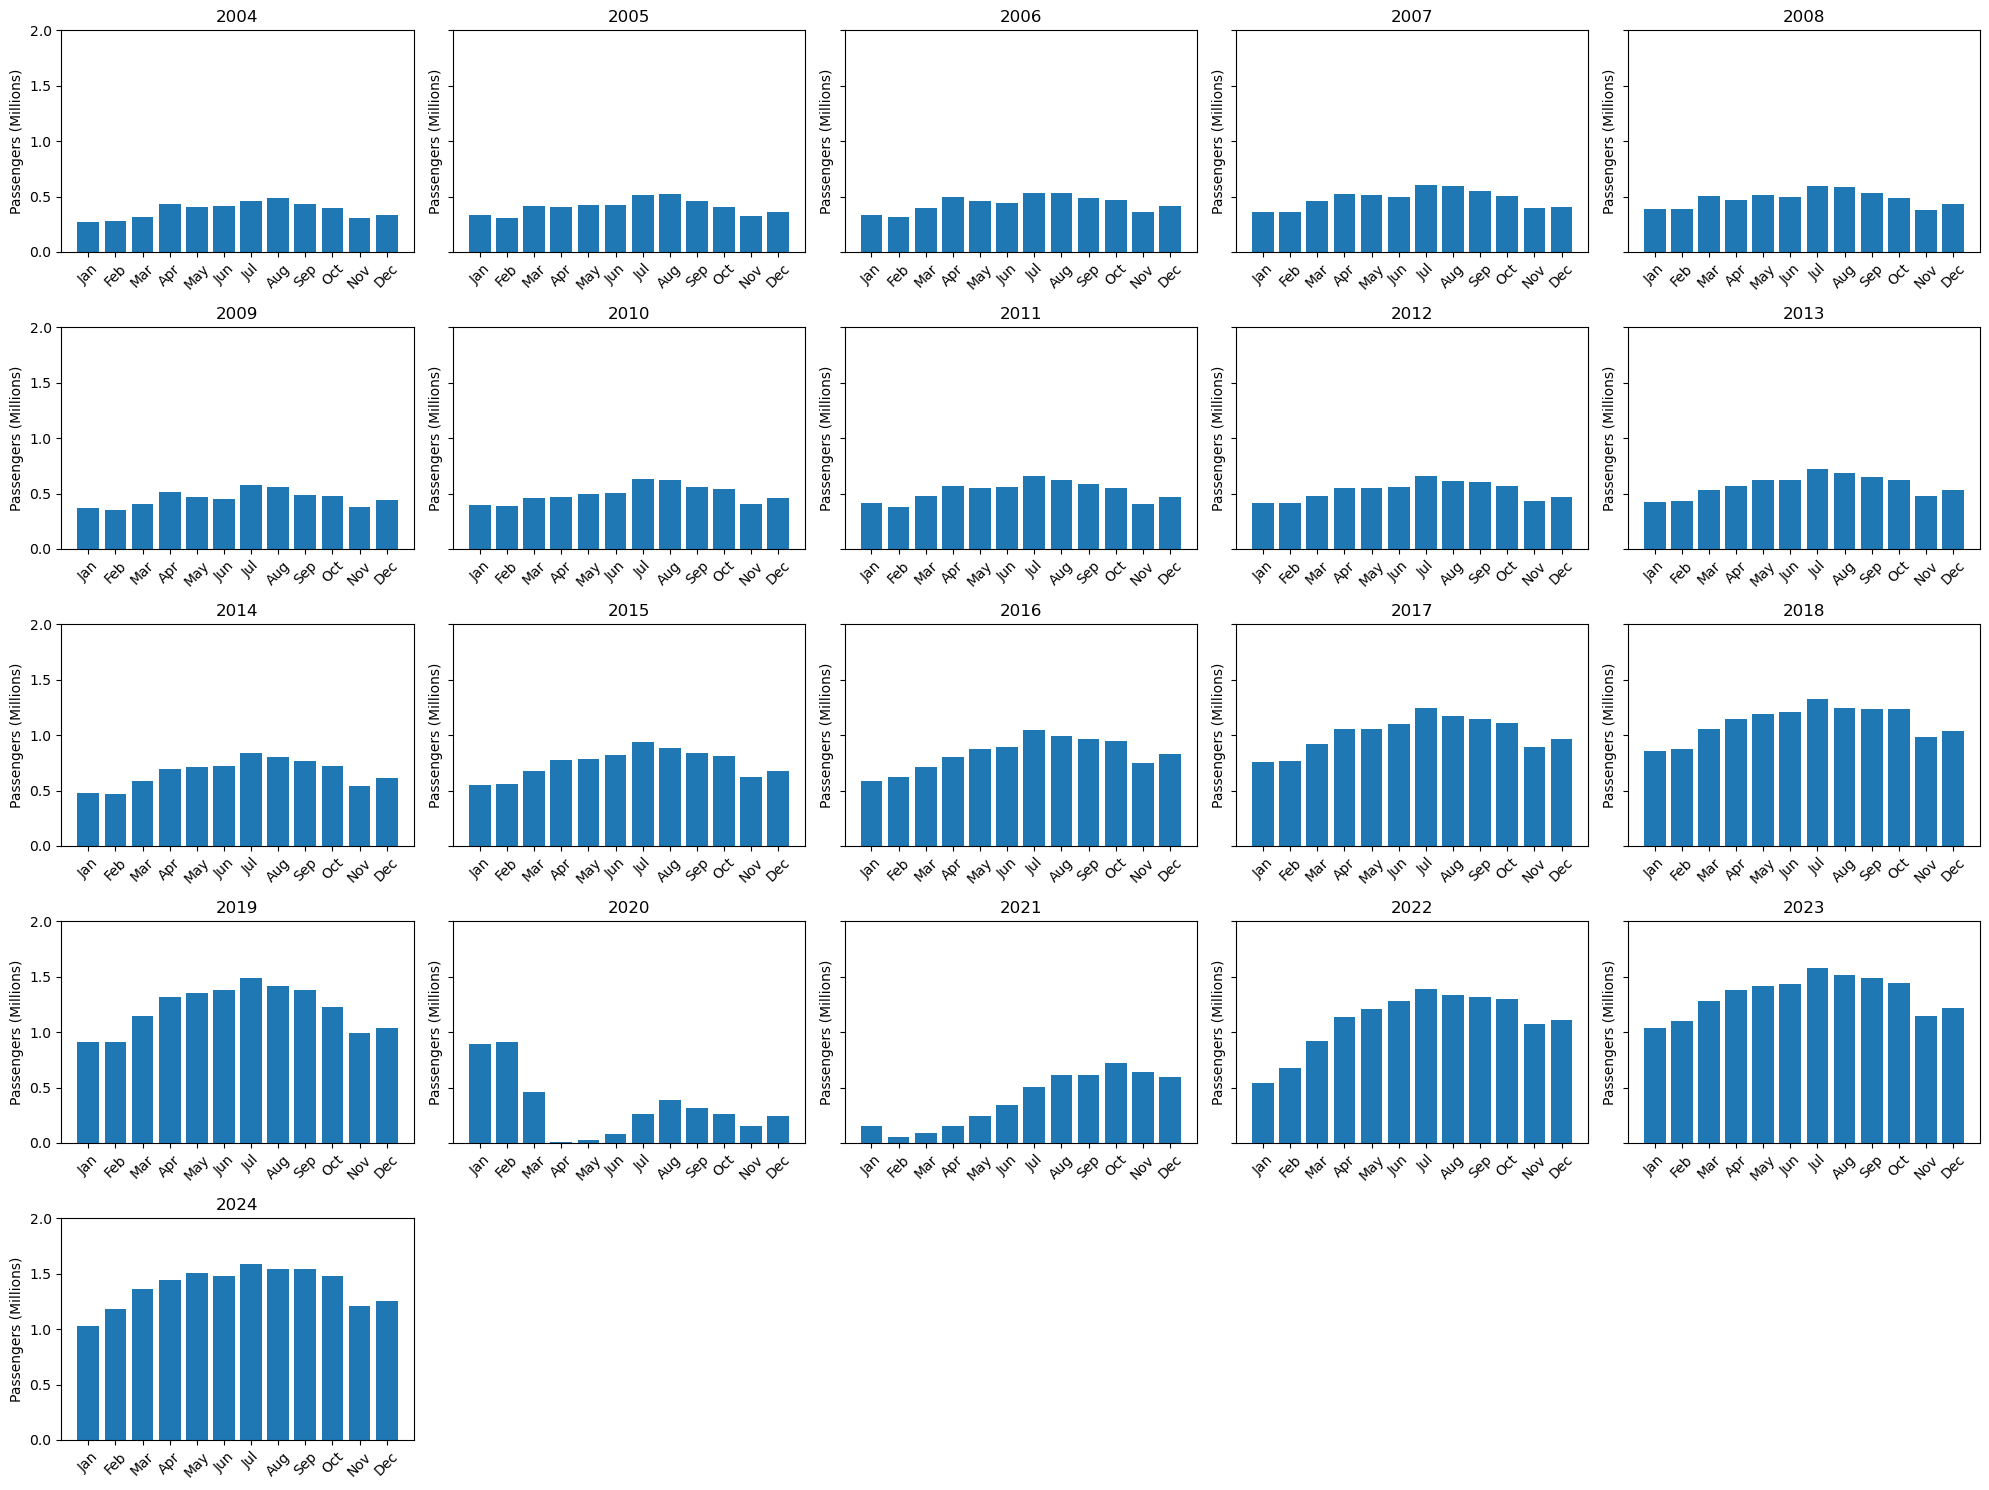

In [178]:
# Visualisation of Passengers through a Bar Subplot Grid - detailed yearly comparison

# Filters solely for passengers' data
passengers = arrivals[
    arrivals["Unit"].str.contains("Passengers")
]

# Aggregates Flights per Month
passengers_monthly = monthly_arrivals[
    monthly_arrivals["Traffic_Type"] == "Passengers - Arrivals"
].copy()

# Convert the number of passengers into millions to be more clean
passengers_monthly["Value"] = (
    passengers_monthly["Value"] / 1_000_000
)


# Gets all years
years = sorted(passengers_monthly["Year"].unique())

# Fixed global max, rounded slightly above max value
y_max = passengers_monthly["Value"].max()
y_limit = np.ceil(y_max)

fig, axes = plt.subplots(
    nrows=5,
    ncols=5,
    figsize=(20, 15),
    sharey=True
)

axes = axes.flatten()


for i, year in enumerate(years):
    data = passengers_monthly[passengers_monthly["Year"] == year]

    axes[i].bar(data["Month"], data["Value"])
    axes[i].set_title(str(year))
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Passengers (Millions)")

# Force same y-axis scale on every subplot
for ax in axes:
    ax.set_ylim(0, y_limit)

# Remove empty subplots
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
There is a clear and sustained increase in passenger volumes between 2004 and 2024. While the early years show relatively moderate monthly traffic levels, later years display substantially higher passenger numbers across almost every month, reflecting the airport's long-term growth.

Seasonal pattern remains remarkably consistent throughout the period. In most years, passenger arrivals increase during spring, peak between July and September, and then gradually decline towards the end of the year. This recurring pattern suggests that passenger demand is strongly influenced by seasonal factors, particularly tourism and holiday travel.

Overall, the results indicate that Lisbon Airport has experienced both sustained long-term growth and stable seasonal demand patterns, with summer consistently representing the period of highest pressure.

---

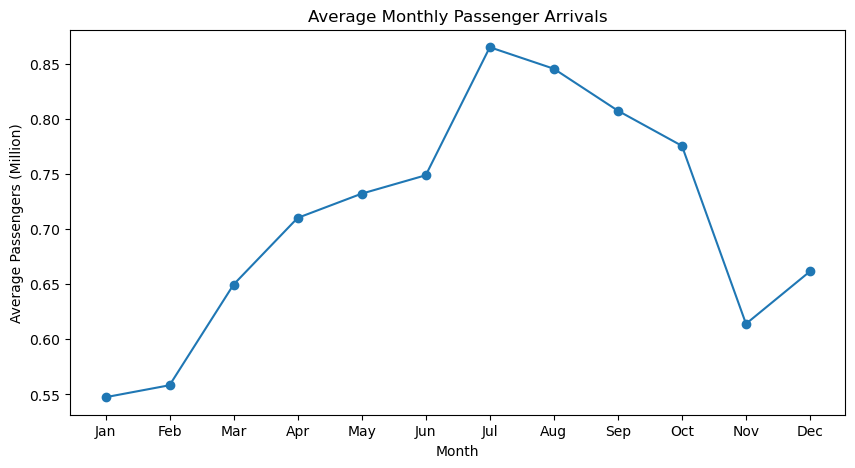

In [179]:
# Visualisation of Passengers average monthly line graph - seasonality analysis/interpretation
avg_month = (
    passengers_monthly
    .groupby("Month", observed=False)["Value"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    avg_month["Month"],
    avg_month["Value"],
    marker="o"
)

plt.xticks(range(0, 12))
plt.title("Average Monthly Passenger Arrivals")
plt.xlabel("Month")
plt.ylabel("Average Passengers (Million)")

plt.show()

---
The average monthly passenger arrivals clearly reveal a strong seasonal pattern in Lisbon Airport traffic. Passenger volumes gradually increase from the beginning of the year, reaching their highest levels during the summer months, particularly between June and September. After the summer peak, arrivals decline steadily throughout autumn and winter. This behaviour confirms the importance of tourism in driving passenger demand, with summer representing the busiest period of the year.

---

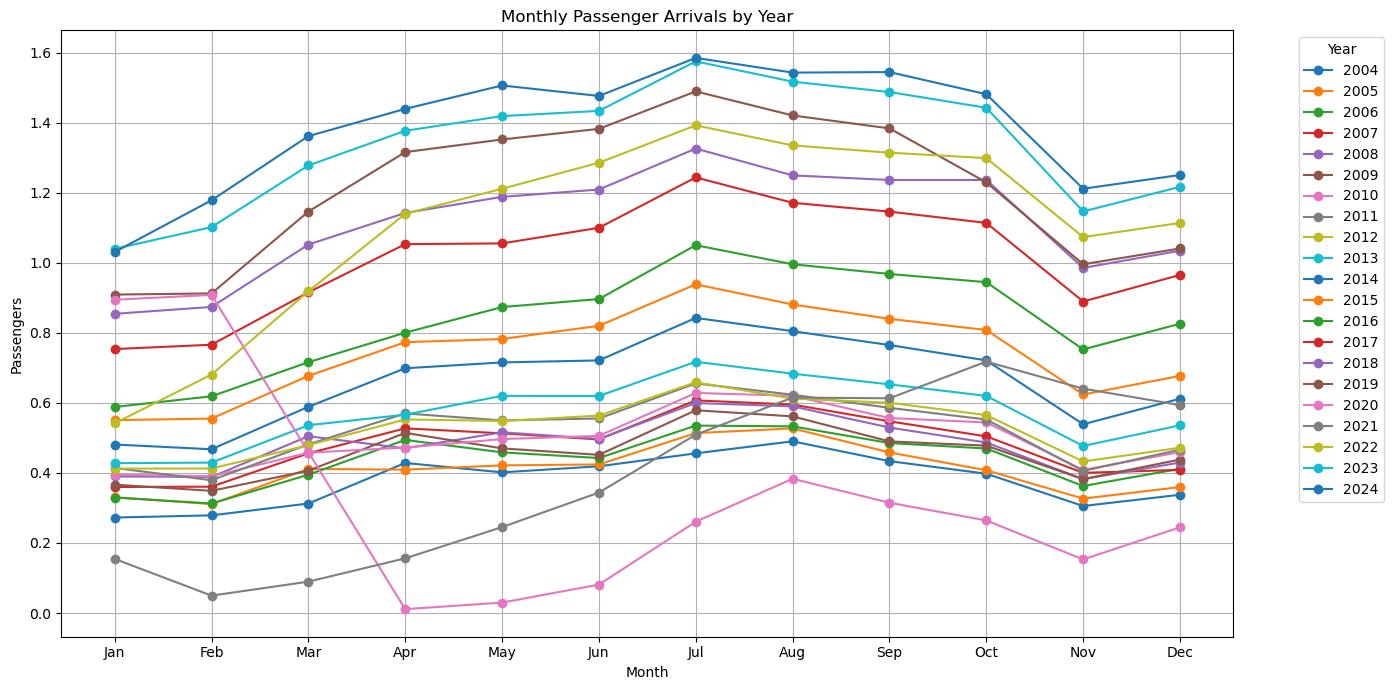

In [180]:
# Visualisation of Passengers through a Mulit-year line chart - comparison of season evolution throughout the years
pivot_years = passengers_monthly.pivot_table(
    observed=False,
    index="Month",
    columns="Year",
    values="Value",
    aggfunc="sum"
)

plt.figure(figsize=(14, 7))

for year in pivot_years.columns:
    plt.plot(
        pivot_years.index,
        pivot_years[year],
        marker="o",
        label=year
    )

plt.xticks(range(0, 12))
plt.title("Monthly Passenger Arrivals by Year")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(True)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

---
As in the Bar Subplot Grid, the graph suggests that while passenger volumes have grown substantially over time, the underlying seasonal pattern has remained largely unchanged, with summer continuing to be the busiest period of the year.

---

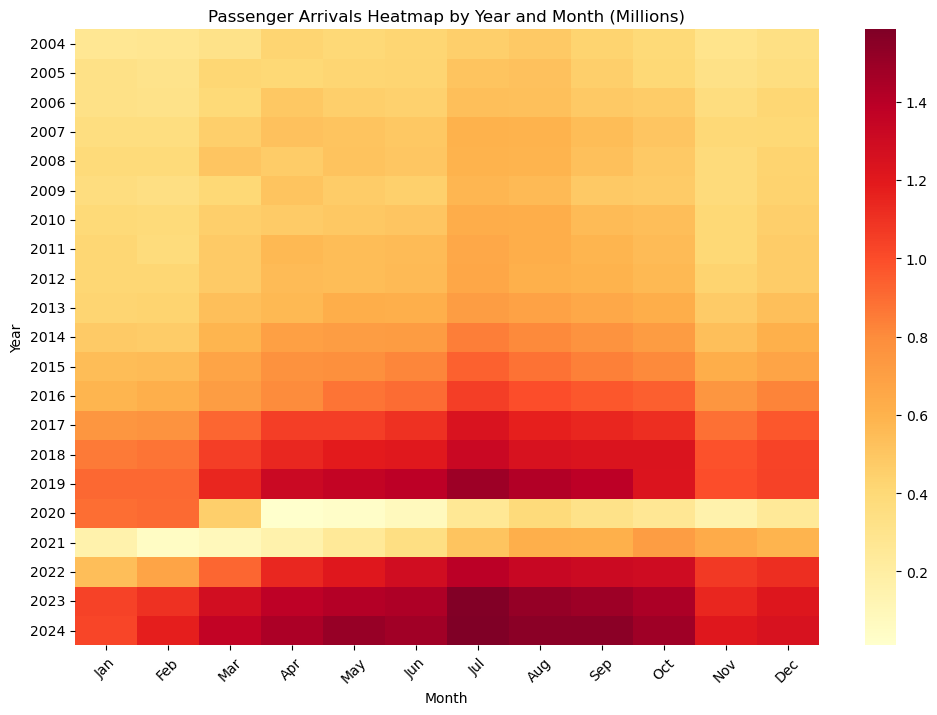

In [181]:
# Summary through a heatmap
heatmap_data = passengers_monthly.pivot_table(
    observed=False,
    index="Year",
    columns="Month",
    values="Value",
    aggfunc="sum"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Passenger Arrivals Heatmap by Year and Month (Millions)")
plt.xlabel("Month")
plt.ylabel("Year")

plt.xticks(
    ticks=[i + 0.5 for i in range(12)],
    rotation=45
)

plt.show()

---
The heatmap reinforces the seasonal patterns identified in the previous analyses. Passenger arrivals are consistently higher during the summer months, particularly between July and September, while lower levels of traffic are observed during the winter period. This recurring pattern suggests that demand at Lisbon Airport is strongly influenced by seasonal factors, namely tourism and holiday travel.

In addition to seasonality, the heatmap highlights a clear upward trend in passenger arrivals over the study period. Traffic levels increased steadily from 2004 until 2019, indicating sustained growth in airport activity. This trend was temporarily interrupted in 2020 due to the COVID-19 pandemic.

The recovery observed in the following years was rapid, with passenger arrivals returning to pre-pandemic levels by 2022 and reaching record highs in 2023 and 2024. Overall, the heatmap suggests that the underlying growth trend and seasonal demand at Lisbon Airport have remained consistent.

---

In [197]:
# Monthly average passengers in arrivals
pass_arr = (
    monthly_arrivals[
        monthly_arrivals["Traffic_Type"] == "Passengers - Arrivals"
    ]
    .groupby("Month", observed=False)["Value"]
    .mean()
)

# Monthly average seats in arrivals
seats_arr = (
    monthly_arrivals[
        monthly_arrivals["Traffic_Type"] == "Seats Available - Arrivals"
    ]
    .groupby("Month", observed=False)["Value"]
    .mean()
)

load_factor_arr = (
    pass_arr / seats_arr * 100
).reset_index()

load_factor_arr.columns = [
    "Month",
    "Load_Factor (%)"
]

print(
    load_factor_arr.round(2).to_string(index=False)
)

Month  Load_Factor (%)
  Jan            64.40
  Feb            71.94
  Mar            75.17
  Apr            79.56
  May            78.59
  Jun            78.67
  Jul            82.91
  Aug            79.27
  Sep            80.61
  Oct            78.28
  Nov            70.34
  Dec            72.28


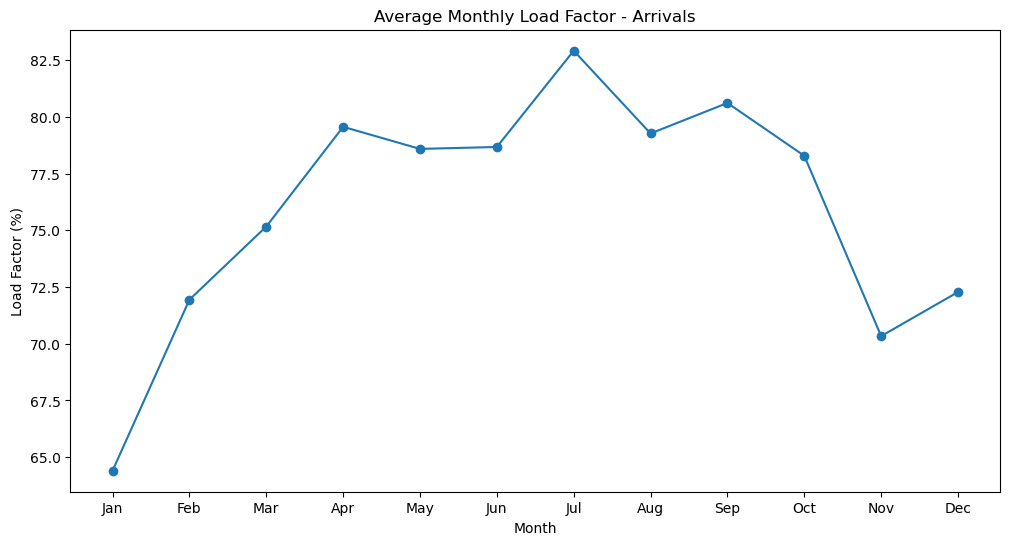

In [205]:
plt.figure(figsize=(12,6))

plt.plot(
    load_factor_arr["Month"],
    load_factor_arr["Load_Factor (%)"],
    marker="o",
    label="Arrivals"
)


plt.title("Average Monthly Load Factor - Arrivals")
plt.xlabel("Month")
plt.ylabel("Load Factor (%)")

plt.show()

---
The load factor results are consistent with the seasonal patterns identified throughout the analysis. Aircraft occupancy remains relatively high during the entire year, generally exceeding 70%, and reaches its maximum during the summer months, peaking in July.

This suggests that the increase in passenger traffic observed during the peak season is accompanied by a more intensive use of the available seat capacity. Although airlines appear to respond to higher demand by increasing capacity, passenger growth remains strong enough to maintain high load factors.

All in all, these findings indicate that the summer months are characterised not only by higher passenger volumes but also by higher capacity utilisation. This reinforces the conclusion that seasonal peaks represent periods of greater operational pressure at Lisbon Airport.

---

## 4.1.2 Departures Seasonality

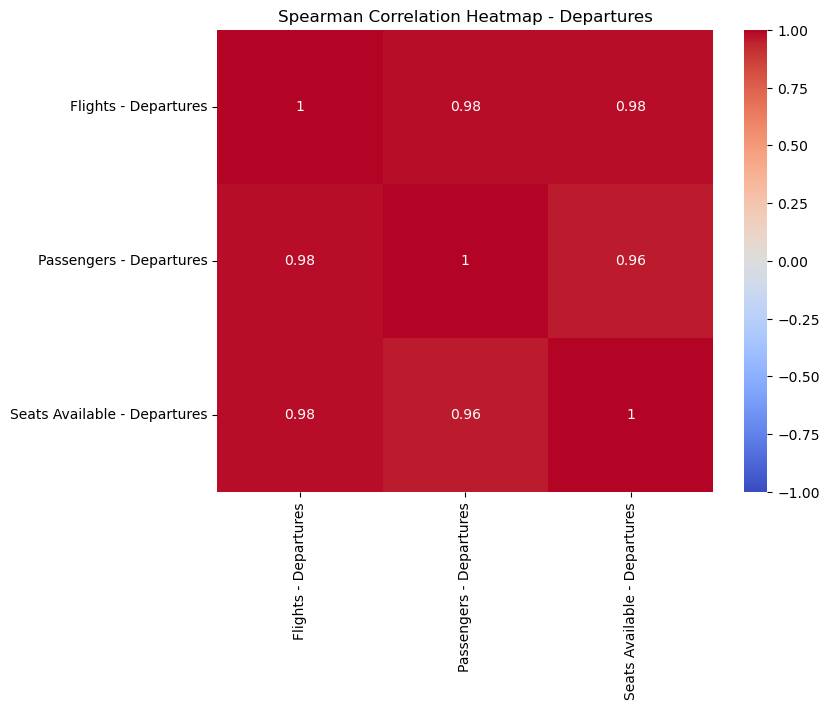

In [182]:
# Test if the three variables (Flights, Passengers and Avaialbles Seats) display high correlation between them

# Filter only for departures
departures = monthly_lis[
    monthly_lis["Traffic_Type"].isin([
        "Flights - Departures",
        "Passengers - Departures",
        "Seats Available - Departures"
    ])
]

# Aggregate Departures by Year, Month and Traffic
monthly_departures = (
    departures
    .groupby(["Year", "Month", "Traffic_Type"], observed=False)["Value"]
    .sum()
    .reset_index()
)

departures_pivot = monthly_departures.pivot_table(
    observed=False,
    index=["Year", "Month"],
    columns="Traffic_Type",
    values="Value",
    aggfunc="sum"
).reset_index()

spearman_corr = departures_pivot.drop(columns=["Year", "Month"]).corr(method="spearman")

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Heatmap - Departures")
plt.xlabel(None)
plt.ylabel(None)
plt.show()

---
Same as in Arrivals, the heatmap confirms a very strong positive correlation (>0.96) between the number of Flights, Passengers and Available Seats.  
Therefore, and similarly to the Arrivals, we will base our analysis solely on the Passenger variable.

---

In [183]:
# Copy of the departures, as we will start analysing solely Passengers Departures
passdep_monthly = monthly_departures[
    monthly_departures["Traffic_Type"] == "Passengers - Departures"
].copy()

# Convert values to thousands
passdep_monthly["Value"] = (
    passdep_monthly["Value"] / 1_000
).round(3)

In [184]:
# Average and Median Passengers per month
overalldep_stats = (
    passdep_monthly
    .groupby("Month", observed=False)["Value"]
    .agg(["mean", "median"])
    .reset_index()
)

overalldep_stats.columns = [
    "Month",
    "Average_Passengers (k)",
    "Median_Passengers (k)"
]

overalldep_stats["Month"] = overalldep_stats["Month"]

print(
    overalldep_stats.round(0).to_string(index=False)
)

Month  Average_Passengers (k)  Median_Passengers (k)
  Jan                   582.0                  474.0
  Feb                   540.0                  425.0
  Mar                   632.0                  492.0
  Apr                   684.0                  548.0
  May                   713.0                  547.0
  Jun                   728.0                  554.0
  Jul                   798.0                  604.0
  Aug                   886.0                  661.0
  Sep                   814.0                  631.0
  Oct                   787.0                  637.0
  Nov                   652.0                  507.0
  Dec                   616.0                  494.0


In [185]:
# Ranking the months by the number of passengers
monthdep_ranking = (
    passdep_monthly
    .groupby("Month", observed=False)["Value"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

monthdep_ranking.columns = [
    "Month",
    "Average_Passengers (k)"
]

monthdep_ranking["Month"] = monthdep_ranking["Month"]

print(
    monthdep_ranking.round(0).to_string(index=False)
)

Month  Average_Passengers (k)
  Aug                   886.0
  Sep                   814.0
  Jul                   798.0
  Oct                   787.0
  Jun                   728.0
  May                   713.0
  Apr                   684.0
  Nov                   652.0
  Mar                   632.0
  Dec                   616.0
  Jan                   582.0
  Feb                   540.0


In [186]:
# Average and Median Passengers per month for each year
yearlydep_stats = (
    passdep_monthly
    .groupby(["Year", "Month"], observed=False)["Value"]
    .agg(["mean", "median"])
    .reset_index()
)

yearlydep_stats.columns = [
    "Year",
    "Month",
    "Average_Passengers (k)",
    "Median_Passengers (k)"
]

print(yearlydep_stats.round(0))

     Year Month  Average_Passengers (k)  Median_Passengers (k)
0    2004   Jan                   272.0                  272.0
1    2004   Feb                   267.0                  267.0
2    2004   Mar                   308.0                  308.0
3    2004   Apr                   403.0                  403.0
4    2004   May                   377.0                  377.0
..    ...   ...                     ...                    ...
247  2024   Aug                  1597.0                 1597.0
248  2024   Sep                  1525.0                 1525.0
249  2024   Oct                  1517.0                 1517.0
250  2024   Nov                  1274.0                 1274.0
251  2024   Dec                  1204.0                 1204.0

[252 rows x 4 columns]


In [187]:
# Ranking the months by the number of passengers each year
monthlydep_rankings = (
    passdep_monthly
    .groupby(["Year", "Month"], observed=False)["Value"]
    .mean()
    .reset_index()
)

monthlydep_rankings["Rank"] = (
    monthlydep_rankings
    .groupby("Year")["Value"]
    .rank(ascending=False, method="dense")
)

monthlydep_rankings = monthlydep_rankings.sort_values(
    ["Year", "Rank"]
)


# Frequency of each ranking per month
rankingdep_frequency = (
    monthly_rankings
    .pivot_table(
        observed=False,
        index="Month",
        columns="Rank",
        values="Year",
        aggfunc="count",
        fill_value=0
    )
)

# Excluding 2020 (Covid)
monthlydep_rankings_no2020 = monthlydep_rankings[
    monthlydep_rankings["Year"] != 2020
]

# Frequency table of rankings per month
rankingdep_frequency_no2020 = (
    monthlydep_rankings_no2020
    .pivot_table(
        observed=False,
        index="Month",
        columns="Rank",
        values="Year",
        aggfunc="count",
        fill_value=0
    )
)


print(monthlydep_rankings.round(0))
print(rankingdep_frequency.round(0), "\n")
print(rankingdep_frequency_no2020.round(0))

     Year Month   Value  Rank
7    2004   Aug   490.0   1.0
6    2004   Jul   430.0   2.0
8    2004   Sep   428.0   3.0
3    2004   Apr   403.0   4.0
5    2004   Jun   386.0   5.0
..    ...   ...     ...   ...
242  2024   Mar  1317.0   8.0
250  2024   Nov  1274.0   9.0
251  2024   Dec  1204.0  10.0
241  2024   Feb  1112.0  11.0
240  2024   Jan  1091.0  12.0

[252 rows x 4 columns]
Rank   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0  12.0
Month                                                                        
Jan       0     1     0     0     0     0     0     0     0     4     4    12
Feb       1     0     0     0     0     0     0     0     0     0    13     7
Mar       0     0     1     0     1     1     0     8     7     2     1     0
Apr       0     0     2     3     0     2    10     2     1     0     0     1
May       0     0     0     3     3    11     2     1     0     0     1     0
Jun       0     0     0     3    10     3     4     0     0     1     

In [188]:
# Total Passengers per year
yearlydep_totals = (
    passdep_monthly
    .groupby("Year")["Value"]
    .sum()
    .reset_index()
)

yearlydep_totals.columns = [
    "Year",
    "Total_Passengers (k)"
]

yearlydep_totals["Absolute_Growth"] = (
    yearlydep_totals["Total_Passengers (k)"]
    .diff()
)

yearlydep_totals["Percent_Growth"] = (
    yearlydep_totals["Total_Passengers (k)"]
    .pct_change() * 100
).round(2)

print(
    yearlydep_totals.round(0).to_string(index=False)
)

 Year  Total_Passengers (k)  Absolute_Growth  Percent_Growth
 2004                4368.0              NaN             NaN
 2005                4690.0            322.0             7.0
 2006                5037.0            347.0             7.0
 2007                5629.0            592.0            12.0
 2008                5755.0            127.0             2.0
 2009                5523.0           -233.0            -4.0
 2010                5943.0            420.0             8.0
 2011                6228.0            285.0             5.0
 2012                6331.0            103.0             2.0
 2013                6888.0            557.0             9.0
 2014                7911.0           1023.0            15.0
 2015                8888.0            977.0            12.0
 2016                9970.0           1083.0            12.0
 2017               12057.0           2086.0            21.0
 2018               13266.0           1209.0            10.0
 2019               1443

In [189]:
# CAGR 2004-2024
def CAGRdep(startdep_value, enddep_value, periods):
    return ((enddep_value / startdep_value) ** (1 / periods) - 1) * 100

startdep_2004 = yearlydep_totals.loc[
    yearlydep_totals["Year"] == 2004,
    "Total_Passengers (k)"
].values[0]

enddep_2024 = yearlydep_totals.loc[
    yearlydep_totals["Year"] == 2024,
    "Total_Passengers (k)"
].values[0]

cagrdep_2004_2024 = CAGR(startdep_2004, enddep_2024, 20)

print(f"CAGR 2004-2024: {cagrdep_2004_2024:.2f}%")

CAGR 2004-2024: 6.86%


---
The results obtained for passenger departures are largely consistent with those observed for arrivals. Seasonal peaks continue to occur during the summer months, while lower traffic levels are concentrated in the winter period. Similarly, the long-term increase in passenger volumes, the impact of the COVID-19 pandemic, and the subsequent recovery follow the same pattern identified in the arrivals analysis.

Given the strong relationship between inbound and outbound passenger flows, these findings are not surprising. Overall, the departures analysis reinforces the conclusion that Lisbon Airport experiences both sustained growth and a stable seasonal pattern, with summer remaining the period of highest demand.

---

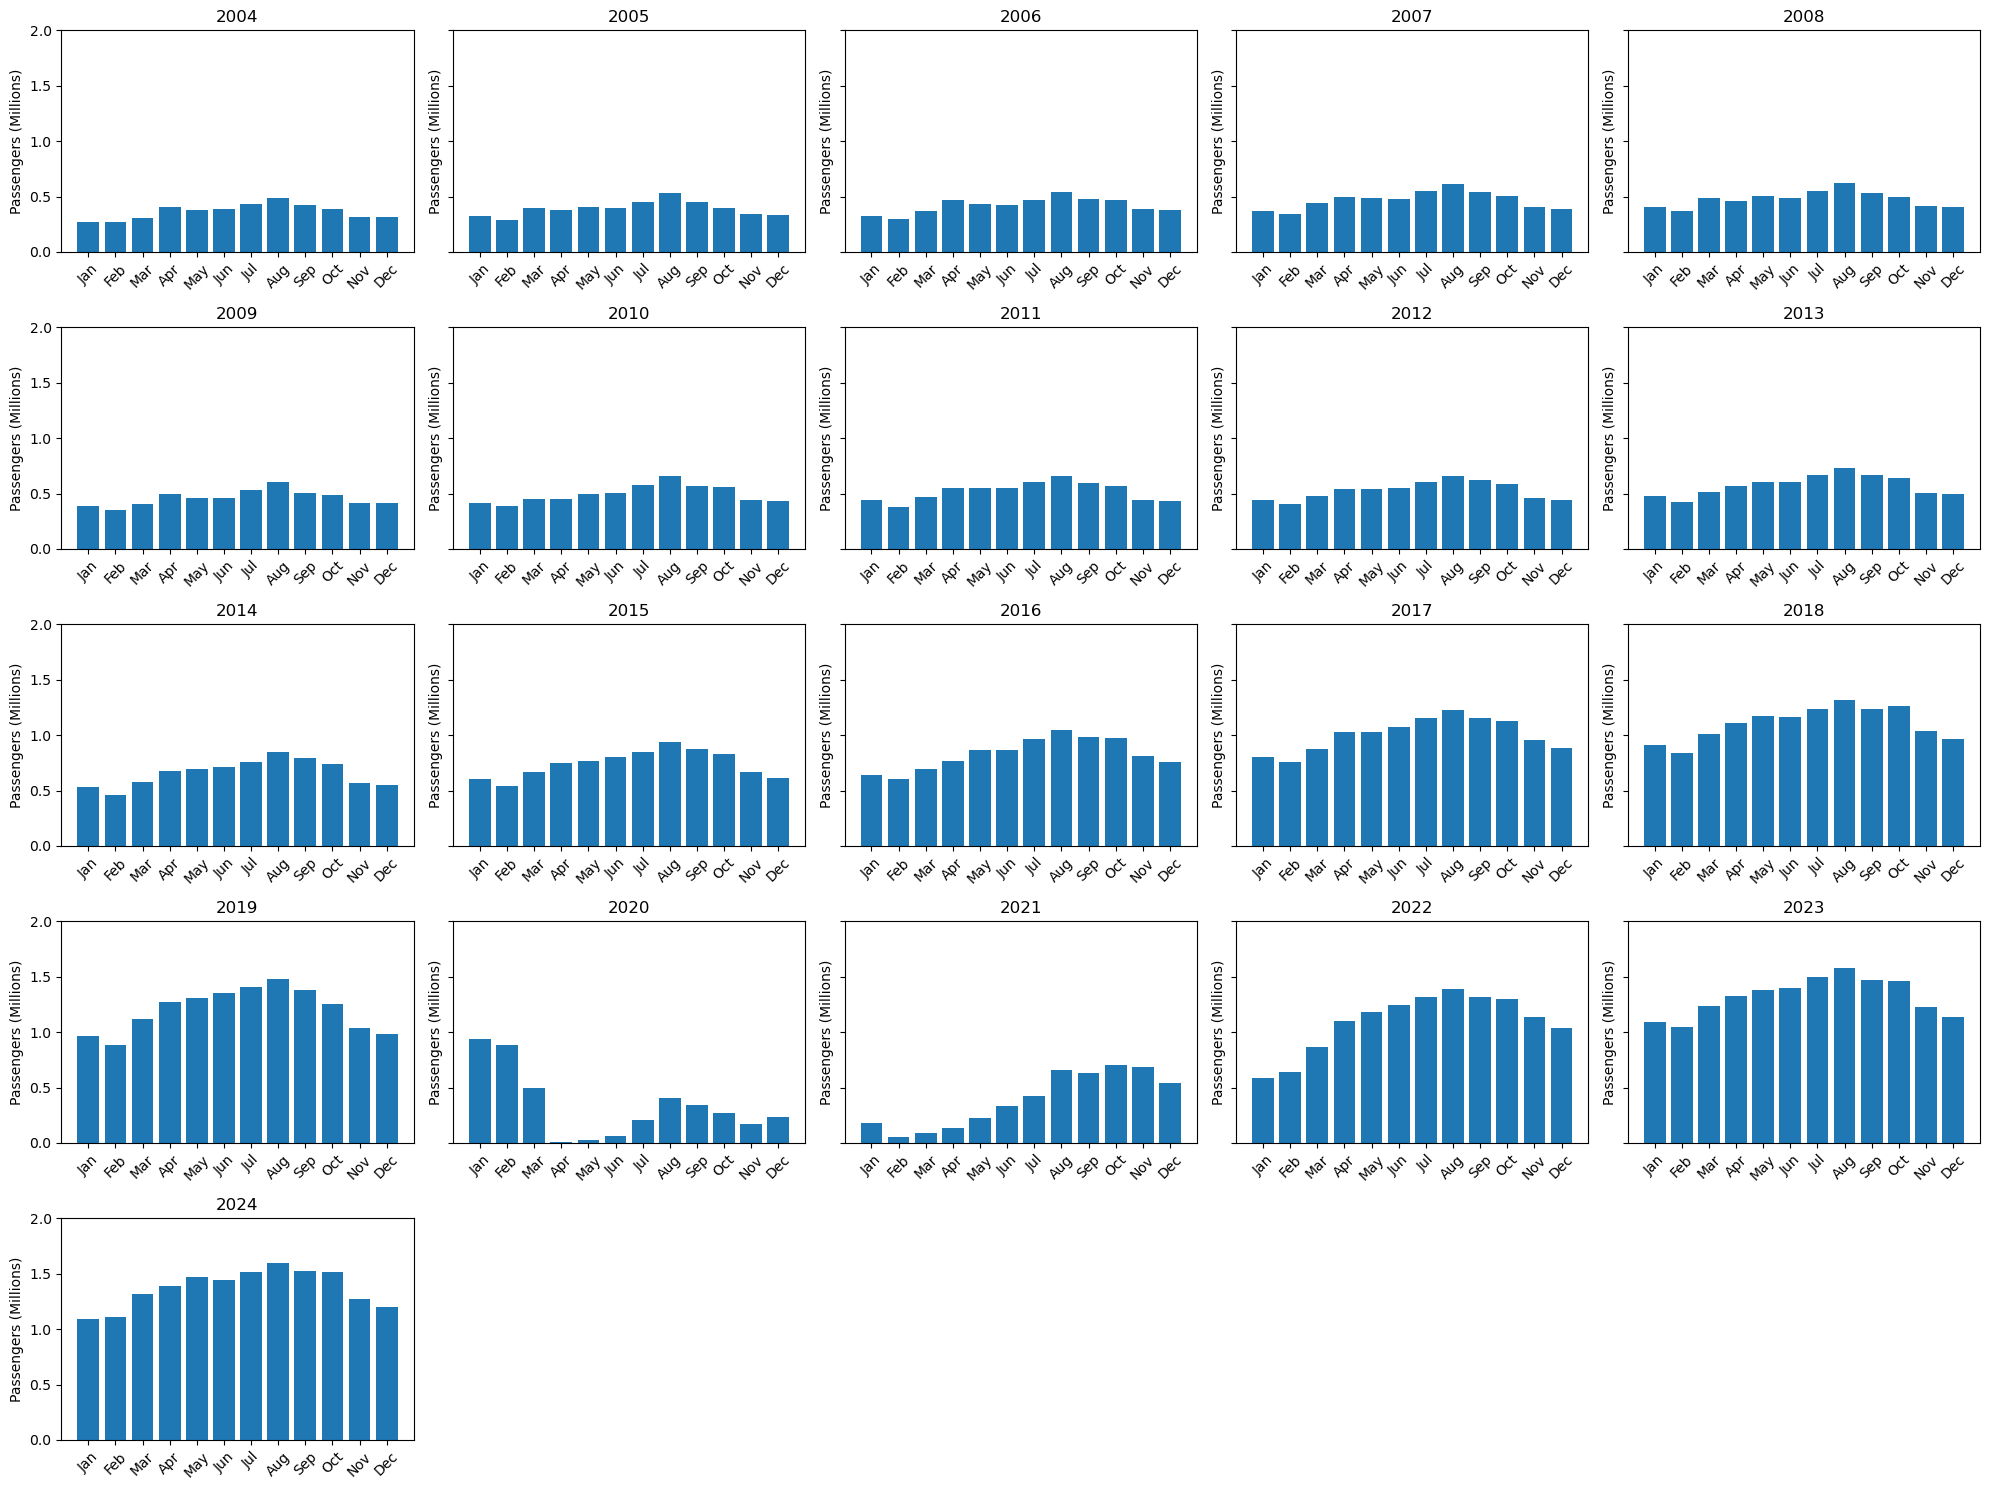

In [190]:
# Visualisation of Passengers through a Bar Subplot Grid - detailed yearly comparison

# Filter solely for passengers' data
passengersdep = departures[
    departures["Unit"].str.contains("Passengers")
]

# Aggregate Flights per Month
passdep_monthly = monthly_departures[
    monthly_departures["Traffic_Type"] == "Passengers - Departures"
].copy()

# Convert the number of passengers into millions to be more clean
passdep_monthly["Value"] = (
    passdep_monthly["Value"] / 1_000_000
)


# Get all years
years = sorted(passengers_monthly["Year"].unique())

# Fixed global max, rounded slightly above max value
y_max = passengers_monthly["Value"].max()
y_limit = np.ceil(y_max)

fig, axes = plt.subplots(
    nrows=5,
    ncols=5,
    figsize=(20, 15),
    sharey=True
)

axes = axes.flatten()


for i, year in enumerate(years):
    data = passdep_monthly[passdep_monthly["Year"] == year]

    axes[i].bar(data["Month"], data["Value"])
    axes[i].set_title(str(year))
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Passengers (Millions)")

# Force same y-axis scale on every subplot
for ax in axes:
    ax.set_ylim(0, y_limit)

# Remove empty subplots
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
The yearly evolution of passenger departures closely mirrors the pattern observed for arrivals. Across the study period, departures display the same seasonal behaviour, with passenger volumes increasing towards the summer months and declining during the winter period.

The graph also confirms the long-term growth trend previously identified, with passenger departures increasing substantially between 2004 and 2024. 

Overall, the departures data reinforces the conclusions drawn from the arrivals analysis, suggesting that seasonal demand patterns and long-term growth have affected arrivals and departures in a very similar manner.

---

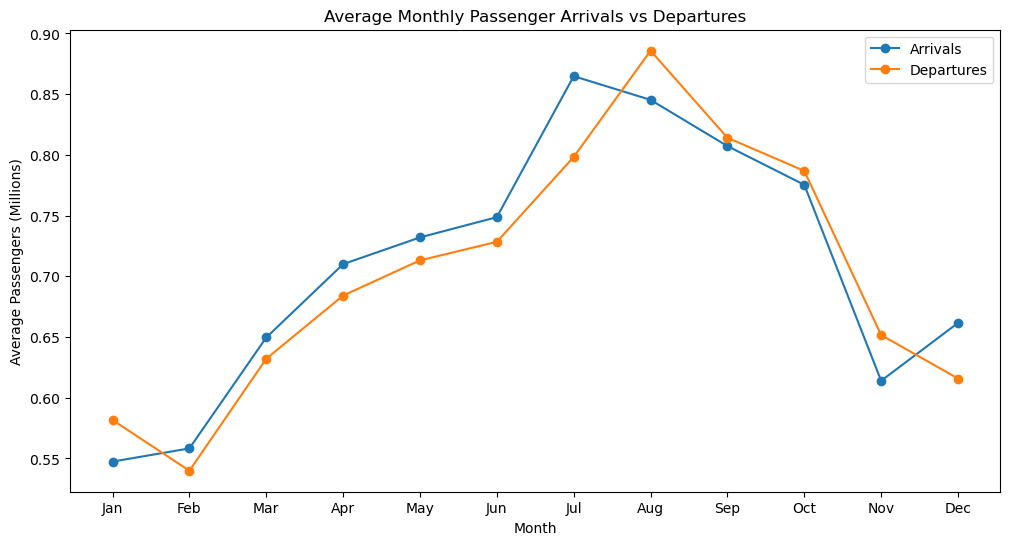

In [191]:
# Comparison of average arrivals and departures

plt.figure(figsize=(12, 6))

# Arrivals
plt.plot(
    avg_month["Month"],
    avg_month["Value"],
    marker="o",
    label="Arrivals"
)

# Departures
plt.plot(
    avgdep_month["Month"],
    avgdep_month["Value"],
    marker="o",
    label="Departures"
)

plt.title("Average Monthly Passenger Arrivals vs Departures")

plt.xlabel("Month")
plt.ylabel("Average Passengers (Millions)")
plt.legend()

plt.show()

---
The comparison between average monthly passenger arrivals and departures shows that both series follow almost identical patterns throughout the year. In both cases, passenger volumes increase steadily from spring onwards, peak during the summer months, and decline towards the end of the year.

The small differences observed between the two lines are relatively minor and do not alter the overall seasonal behaviour. Arrivals tend to be slightly higher during some months, while departures exceed arrivals in others, particularly around the summer peak. However, the gap between the two remains limited throughout the year.

Overall, the close alignment between arrivals and departures suggests a balanced flow of passenger traffic at Lisbon Airport and further confirms the consistency of the seasonal patterns identified in the previous analyses.

---

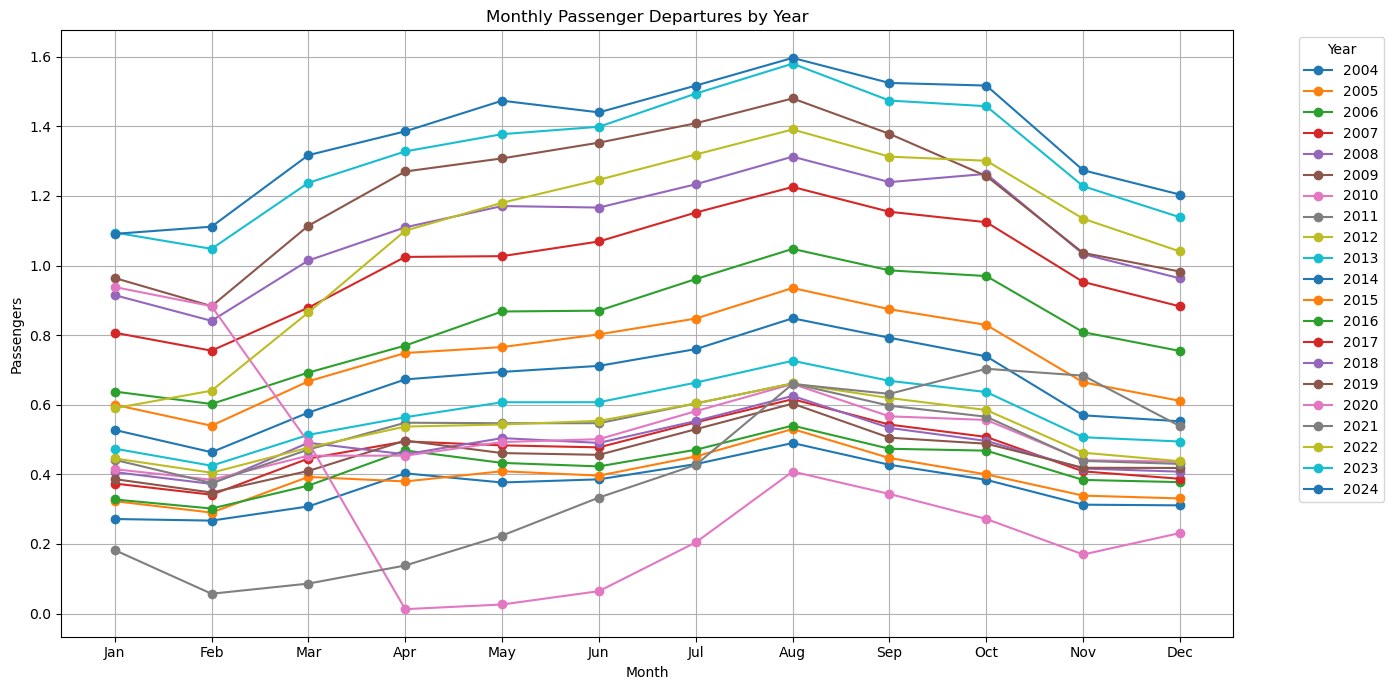

In [192]:
# Visualisation of Passengers through a Mulit-year line chart - comparison of season evolution throughout the years
pivotdep_years = passdep_monthly.pivot_table(
    observed=False,
    index="Month",
    columns="Year",
    values="Value",
    aggfunc="sum"
)

plt.figure(figsize=(14, 7))

for year in pivotdep_years.columns:
    plt.plot(
        pivotdep_years.index,
        pivotdep_years[year],
        marker="o",
        label=year
    )

plt.xticks(range(0, 12))
plt.title("Monthly Passenger Departures by Year")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(True)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

---
The yearly evolution of passenger departures closely follows the pattern previously observed for arrivals. Across almost all years, departures increase steadily during the first half of the year, reach their highest levels during the summer months, and gradually decline towards the end of the year.

Overall, the departures data provides further evidence that the seasonal and long-term trends identified in the arrivals analysis are equally present in departures traffic.

---

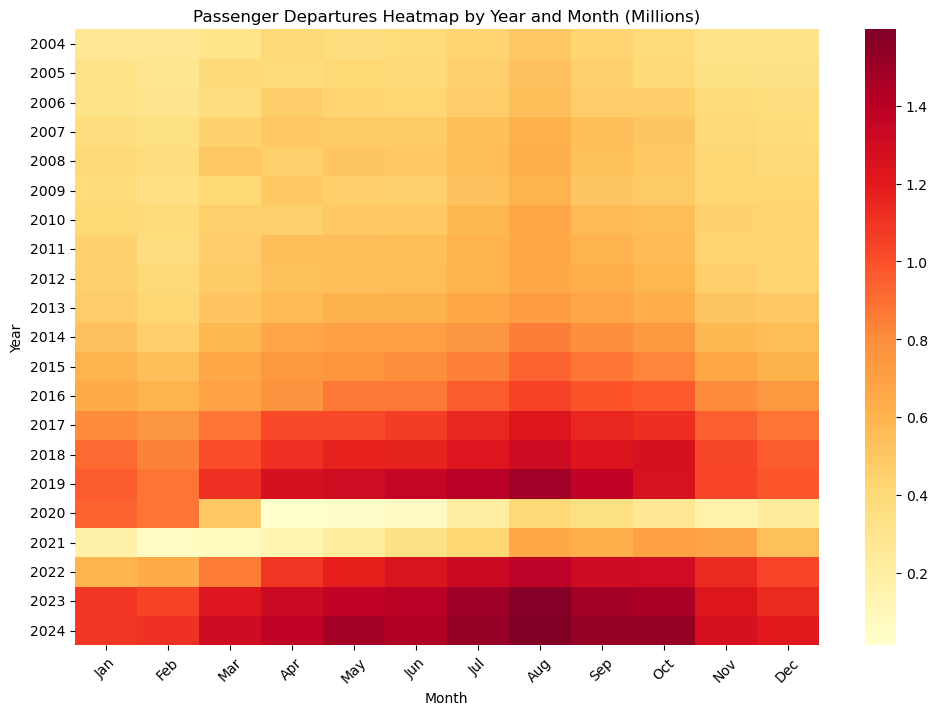

In [193]:
# Summary through a heatmap
heatmapdep_data = passdep_monthly.pivot_table(
    observed=False,
    index="Year",
    columns="Month",
    values="Value",
    aggfunc="sum"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmapdep_data,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Passenger Departures Heatmap by Year and Month (Millions)")
plt.xlabel("Month")
plt.ylabel("Year")

plt.xticks(
    ticks=[i + 0.5 for i in range(12)],
    rotation=45
)

plt.show()

---
The heatmap for passenger departures presents results that are consistent with those observed for arrivals. Higher passenger volumes remain concentrated in the summer months, particularly between July and September, while lower levels of traffic are recorded during the winter period.

The visualisation also illustrates the long-term growth in departure traffic throughout the study period, interrupted only by the significant decline associated with the COVID-19 pandemic in 2020. The subsequent recovery is evident, with passenger volumes in the most recent years exceeding pre-pandemic levels.

---

In [196]:
# Monthly average passengers in departures
pass_dep = (
    monthly_departures[
        monthly_departures["Traffic_Type"] == "Passengers - Departures"
    ]
    .groupby("Month", observed=False)["Value"]
    .mean()
)

# Monthly average seats in departures
seats_dep = (
    monthly_departures[
        monthly_departures["Traffic_Type"] == "Seats Available - Departures"
    ]
    .groupby("Month", observed=False)["Value"]
    .mean()
)

load_factor_dep = (
    pass_dep / seats_dep * 100
).reset_index()

load_factor_dep.columns = [
    "Month",
    "Load_Factor (%)"
]

print(
    load_factor_dep.round(2).to_string(index=False)
)

Month  Load_Factor (%)
  Jan            68.60
  Feb            69.59
  Mar            73.07
  Apr            76.57
  May            76.52
  Jun            76.45
  Jul            76.55
  Aug            82.91
  Sep            81.20
  Oct            79.44
  Nov            74.62
  Dec            67.07


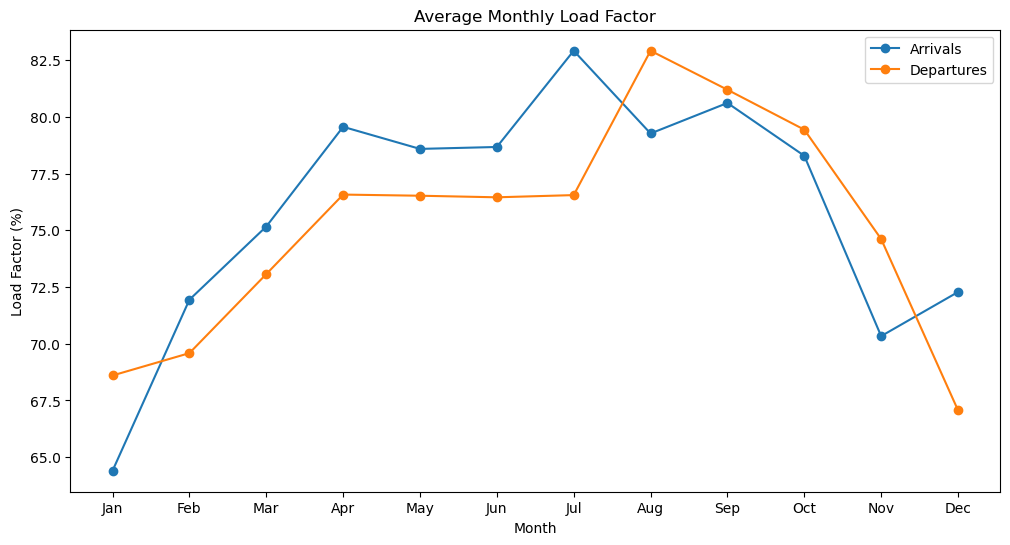

In [201]:
plt.figure(figsize=(12,6))

plt.plot(
    load_factor_arr["Month"],
    load_factor_arr["Load_Factor (%)"],
    marker="o",
    label="Arrivals"
)

plt.plot(
    load_factor_dep["Month"],
    load_factor_dep["Load_Factor (%)"],
    marker="o",
    label="Departures"
)

plt.title("Average Monthly Load Factor")
plt.xlabel("Month")
plt.ylabel("Load Factor (%)")

plt.legend()

plt.show()

---
Average monthly load factors for arrivals and departures follow very similar patterns throughout the year. In both cases, load factors increase from the beginning of the year, remain relatively high during the spring and summer months, and decline towards the end of the year.

Both series reach their highest values during the peak travel season, indicating that the increase in passenger demand is accompanied by a more intensive use of the available seat capacity.

These results are consistent with the analsyis of seasonality. The summer months are characterised not only by higher passenger volumes but also by higher occupancy rates, suggesting that demand grows at a faster pace than capacity during this period. As a result, seasonal peaks are likely to place greater pressure on airport operations and infrastructure.

---

### Seasonality

The seasonality analysis shows that passenger traffic at Lisbon Airport follows a clear and consistent annual pattern and is strongly influenced by tourism-related travel demand. For both arrivals and departures, passenger volumes generally increase throughout the first half of the year, reach their highest levels during the summer months, and gradually decline towards the end of the year.

The results also indicate that this seasonal behaviour has remained relatively stable throughout the study period. Although passenger volumes have increased substantially since 2004, the timing of peak and low-demand periods has changed very little, suggesting that the underlying drivers of demand have remained largely unchanged.

The analysis further highlights the significant impact of the COVID-19 pandemic, which temporarily disrupted normal traffic patterns in 2020 and 2021. However, the recovery observed in subsequent years demonstrates the resilience of passenger demand, with recent traffic levels exceeding those recorded before the pandemic.

Load factor results complement our analysis by showing that aircraft occupancy remains consistently high throughout the year and reaches its highest levels during the peak summer season. This indicates that the increase in passenger traffic is not explained solely by additional seat capacity, but also by a more intensive use of the available capacity during periods of high demand.

Summing up, the analysis suggest that Lisbon Airport is characterised by both strong long-term growth and seasonality. Consequently, airport capacity and operational planning must account not only for increasing passenger volumes over time but also for the recurring concentration of demand during the summer months, when both passenger traffic and load factors reach their highest levels.

# Conclusion

The analyses conducted throughout this project suggest that Lisbon Airport operates under substantial and continuously **increasing demand pressure**, particularly on its major international routes. Passenger volumes, route density, and consistently high load factors indicate that Lisbon has strengthened its role as a major international aviation hub over the last two decades.

Several visualizations — including route evolution plots, heatmaps, bar plots, and scatter plots — reveal that many strategic international routes operate with very high seat occupancy levels over long periods of time. Routes connected to major European hubs and low-cost international destinations frequently reach load factors above 80–85%, suggesting sustained and structurally strong demand. At the Lisbon airport level, the seasonality analysis also shows consistently high monthly load factors, indicating that passenger growth has generally been accompanied by a strong utilisation of available seat capacity.

The seasonality analysis further demonstrates that passenger traffic at Lisbon Airport follows a strong and highly consistent seasonal pattern. Both arrivals and departures increase steadily throughout spring, peak during the summer months, and decline during autumn and winter. This pattern has remained stable throughout 2004 and 2024, highlighting the importance of tourism and international mobility as primary drivers of airport activity. **Summer months consistently concentrate the highest passenger volumes, flights, and seat capacity**. In addition, **load factors also reach their highest values during this period**, suggesting that demand grows faster than capacity during the peak season and creating periods of intense operational pressure.

At the same time, the analyses also reveal an important **imbalance between international and domestic traffic dynamics**. International routes not only account for the overwhelming majority of passenger traffic, but also exhibit significantly higher average load factors compared to domestic routes. This suggests that the strongest operational pressure on Lisbon Airport infrastructure originates primarily from international tourism and international mobility demand rather than domestic connectivity.

In contrast, several domestic continental routes — particularly Lisbon–Porto and Lisbon–Faro — consistently appear among the routes with the lowest average load factors despite maintaining substantial seat capacity and operational frequency.

One possible explanation is the increasing competitiveness of alternative transportation systems within mainland Portugal. The relatively short distances between major Portuguese cities, combined with the expansion of rail infrastructure and low-cost coach operators such as FlixBus, may reduce the attractiveness of domestic air travel while still consuming valuable airport slots and operational resources.

The results therefore suggest that part of Lisbon Airport’s congestion problem may not derive exclusively from insufficient infrastructure capacity, but also from the current allocation and utilization of air traffic operations. Several optimization strategies could potentially reduce operational pressure before requiring full-scale airport expansion, including:

- reducing frequencies on persistently underutilized routes,
- resizing aircraft capacity on low-demand connections,
- improving seasonal scheduling efficiency,
- reallocating airport slots toward higher-demand international routes,
- and strengthening intermodal integration with rail and long-distance bus transportation.

However, the analyses also indicate that optimization alone may not fully solve Lisbon’s long-term capacity challenges. The sustained growth of international passenger demand, the rapid post-pandemic recovery, and the increasingly high saturation levels observed across major international routes suggest that **pressure on airport infrastructure is likely to intensify further in the coming years.**

Overall, the project supports a balanced conclusion: **while a new airport may eventually become necessary in the long term, significant opportunities for operational optimization and traffic reallocation still exist** and should be carefully explored before undertaking large-scale infrastructure investments. Nevertheless, the combination of sustained passenger growth, high route-level load factors, and recurring seasonal peaks in capacity utilisation suggests that pressure on Lisbon Airport is likely to remain a significant challenge in the coming decades.